In [ ]:
!pip install shap
!pip install boruta

In [ ]:
import pandas as pd
import numpy as np
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import xgboost as xgbimport
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from boruta import BorutaPy



# Load the data
df = pd.read_csv(
    'large_fires_data_v2_ndfb_kd_co.csv',
    names= [
        'point_id',
        'lat_dd',
        'long_dd',
        'ndfb_kd_co',
        'Aspect',
        'Climatic water deficit',
        'Elevation',
        'Humidity',
        'LULC',
        'NDVI',
        'Evaptranspiration',
        'Precipitation',
        'Slope',
        'Soil moisture',
        'Shortwave radiation flux',
        'Maximum Temperature',
        'Wind speed',
        'dist_fores',
        'human_foot',
        'tree_speci',
        'pdsi'
    ],
    header= 0
)

In [ ]:
df.head()

,point_id,lat_dd,long_dd,ndfb_kd_co,Aspect,Climatic water deficit,Elevation,Humidity,LULC,NDVI,...,Precipitation,Slope,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,dist_fores,human_foot,tree_speci,pdsi
0,118462,60.383883,-100.961333,0.003040,108,25.791901,343.622009,0.003105,5,0.185952,...,33.974201,0,38.638302,122.428001,-2.81874,5.04358,0.00000,0,18,3.842920
1,188536,68.383883,-97.544667,0.000000,30,-9999.000000,29.983200,0.002183,8,0.079882,...,-9999.000000,0,-9999.000000,-9999.000000,-9999.00000,-9999.00000,306.02301,0,0,-9999.000000
2,142254,63.383883,-94.961333,0.000000,113,35.641201,142.042007,0.002544,3,0.118337,...,25.044300,0,39.882900,120.940002,-5.93237,5.63601,45.00000,0,0,-0.417361
3,170110,66.383883,-123.044667,0.000598,-1,25.696800,156.000000,0.003055,11,-0.051117,...,22.537500,0,18.849199,104.688003,-1.79748,3.65383,14.14210,-9999,0,-0.851500
4,5182,46.133883,-73.544667,0.000017,25,16.150000,94.138496,0.005531,2,0.429686,...,96.328300,0,49.552502,146.054001,10.93730,2.69233,0.00000,32,0,1.050420


In [ ]:
# Replace -9999 with NaN
df.replace(-9999, np.nan, inplace=True)

# Verify if replacement was successful by checking for null values
df.isnull().sum()

,0
point_id,0
lat_dd,0
long_dd,0
ndfb_kd_co,0
Aspect,27
Climatic water deficit,78
Elevation,171
Humidity,98
LULC,103
NDVI,115


In [ ]:
# Drop rows with NaN values
df.dropna(inplace=True)

In [ ]:
replace_values_LULC = {
    1: 'Urban_areas',
    2: 'Crop_land',
    3: 'Grass_land',
    4: 'Tree_covered',
    5: 'Shrub_covered',
    6: 'Herbaceous',
    8: 'Sparse_vegetation',
    9: 'Bare_soil',
    10: 'Snow',
    11: 'Water_bodies',
}

df['LULC'] = df['LULC'].replace(replace_values_LULC)

In [ ]:
df.head(10)

,point_id,lat_dd,long_dd,ndfb_kd_co,Aspect,Climatic water deficit,Elevation,Humidity,LULC,NDVI,...,Precipitation,Slope,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,dist_fores,human_foot,tree_speci,pdsi
0,118462,60.383883,-100.961333,0.003040,108.0,25.791901,343.622009,0.003105,Shrub_covered,0.185952,...,33.974201,0.0,38.638302,122.428001,-2.81874,5.04358,0.000000,0.0,18.0,3.842920
2,142254,63.383883,-94.961333,0.000000,113.0,35.641201,142.042007,0.002544,Grass_land,0.118337,...,25.044300,0.0,39.882900,120.940002,-5.93237,5.63601,45.000000,0.0,0.0,-0.417361
4,5182,46.133883,-73.544667,0.000017,25.0,16.150000,94.138496,0.005531,Crop_land,0.429686,...,96.328300,0.0,49.552502,146.054001,10.93730,2.69233,0.000000,32.0,0.0,1.050420
5,5180,46.133883,-73.711333,0.000000,62.0,14.517400,213.761993,0.005358,Tree_covered,0.509989,...,99.220001,1.0,53.683300,145.434998,10.80500,2.62192,0.000000,15.0,6.0,1.075170
6,23536,49.883883,-110.961333,0.000000,102.0,85.902199,766.164002,0.004427,Crop_land,0.306533,...,25.574200,0.0,8.550000,159.216995,12.03230,4.51617,49.497501,17.0,0.0,-0.115882
7,171330,66.467217,-88.378000,0.000000,74.0,34.307098,298.561005,0.002100,Sparse_vegetation,0.064672,...,25.674900,0.0,11.649000,112.188003,-8.41979,4.58282,386.942993,0.0,0.0,-0.419509
8,171040,66.467217,-112.628000,0.000000,205.0,37.411499,481.976990,0.002597,Grass_land,0.126665,...,20.446300,0.0,25.186300,105.348999,-5.18341,4.58974,63.245602,0.0,0.0,0.649869
9,133520,62.300550,-101.711333,0.002948,-1.0,16.660000,266.000000,0.002877,Water_bodies,0.000924,...,27.469000,0.0,38.008800,118.398003,-4.02748,5.48379,18.027800,0.0,0.0,0.135204
11,197830,69.717217,-95.294667,0.000000,236.0,28.190901,16.423500,0.002033,Sparse_vegetation,0.037350,...,13.080000,0.0,5.873330,104.623001,-9.58655,4.75425,411.096008,0.0,0.0,-2.166500
12,165028,65.800550,-88.628000,0.000000,217.0,36.887501,180.914002,0.002130,Sparse_vegetation,0.084306,...,26.125700,1.0,14.422900,114.267998,-7.52132,5.24746,345.398010,0.0,0.0,0.046837


In [ ]:
# Convert necessary columns to categorical
df = df.astype(
    {
        'LULC': 'category'
    }
)

In [ ]:
# # Replace -9999 with NaN
# df.replace(-9999, np.nan, inplace= True)

# # Fill NaN values using forward and Backward fill
# df.fillna(method='ffill', inplace= True)
# df.fillna(method= 'bfill', inplace= True)

In [ ]:
df

,point_id,lat_dd,long_dd,ndfb_kd_co,Aspect,Climatic water deficit,Elevation,Humidity,LULC,NDVI,...,Precipitation,Slope,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,dist_fores,human_foot,tree_speci,pdsi
0,118462,60.383883,-100.961333,0.003040,108.0,25.791901,343.622009,0.003105,Shrub_covered,0.185952,...,33.974201,0.0,38.638302,122.428001,-2.818740,5.04358,0.000000,0.0,18.0,3.842920
2,142254,63.383883,-94.961333,0.000000,113.0,35.641201,142.042007,0.002544,Grass_land,0.118337,...,25.044300,0.0,39.882900,120.940002,-5.932370,5.63601,45.000000,0.0,0.0,-0.417361
4,5182,46.133883,-73.544667,0.000017,25.0,16.150000,94.138496,0.005531,Crop_land,0.429686,...,96.328300,0.0,49.552502,146.054001,10.937300,2.69233,0.000000,32.0,0.0,1.050420
5,5180,46.133883,-73.711333,0.000000,62.0,14.517400,213.761993,0.005358,Tree_covered,0.509989,...,99.220001,1.0,53.683300,145.434998,10.805000,2.62192,0.000000,15.0,6.0,1.075170
6,23536,49.883883,-110.961333,0.000000,102.0,85.902199,766.164002,0.004427,Crop_land,0.306533,...,25.574200,0.0,8.550000,159.216995,12.032300,4.51617,49.497501,17.0,0.0,-0.115882
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,42164,51.800550,-119.294667,0.066987,298.0,40.247398,1234.609985,0.004255,Tree_covered,0.364348,...,82.198196,17.0,38.228600,137.061996,10.527200,1.63274,0.000000,12.0,30.0,-0.320638
9996,83453,55.967217,-102.628000,0.094061,10.0,24.782600,390.493988,0.003904,Shrub_covered,0.360019,...,43.674999,0.0,36.657501,135.151993,4.036580,3.20392,0.000000,0.0,29.0,-0.532250
9997,142023,63.383883,-114.211333,0.066603,45.0,45.147499,304.996002,0.003006,Shrub_covered,0.226289,...,23.678700,0.0,20.494400,115.484001,-0.881827,3.87582,0.000000,0.0,10.0,-0.742617
9998,21169,49.633883,-121.544667,0.151077,21.0,36.743301,1519.750000,0.004994,Tree_covered,0.370431,...,89.547996,10.0,120.483002,135.684006,10.706200,2.26293,0.000000,0.0,0.0,-0.813372


In [ ]:
# Define features and target, X and y
X = df.drop(columns= ['ndfb_kd_co'])
y = df['ndfb_kd_co']

# Split data into training, validation and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
# Combine features and target back for each dataset
train_data = pd.concat([X_train[['lat_dd', 'long_dd']], y_train], axis=1)
val_data = pd.concat([X_val[['lat_dd', 'long_dd']], y_val], axis=1)
test_data = pd.concat([X_test[['lat_dd', 'long_dd']], y_test], axis=1)

# Save to CSV files
train_data.to_csv('training_data.csv', index=False)
val_data.to_csv('validation_data.csv', index=False)
test_data.to_csv('testing_data.csv', index=False)

In [ ]:
# Define the columns to separate out
index_columns = [

                 'point_id',
                 'lat_dd',
                 'long_dd',
                 'dist_fores',
                 'human_foot',
                 'tree_speci',
                 'pdsi'
]

# Separate index columns for train, validation, and test sets
train_indices = X_train[index_columns]
val_indices = X_val[index_columns]
test_indices = X_test[index_columns]

# Drop these columns from the features
X_train = X_train.drop(columns=index_columns)
X_val = X_val.drop(columns=index_columns)
X_test = X_test.drop(columns=index_columns)


In [ ]:
df.columns

Index(['point_id', 'lat_dd', 'long_dd', 'ndfb_kd_co', 'Aspect',
       'Climatic water deficit', 'Elevation', 'Humidity', 'LULC', 'NDVI',
       'Evaptranspiration', 'Precipitation', 'Slope', 'Soil moisture',
       'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed',
       'dist_fores', 'human_foot', 'tree_speci', 'pdsi'],
      dtype='object')

In [ ]:
# Define categorical and numerical columns
categorical_columns = ['LULC']
numerical_columns = ['Climatic water deficit', 'Elevation', 'Humidity','NDVI',
       'Evaptranspiration', 'Precipitation', 'Slope', 'Soil moisture',
       'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed',]

# Initialize the OneHotEncoder and StandardScaler
encoder = OneHotEncoder(sparse_output=False)
scaler = StandardScaler()

# Fit and transform encoders/scalers on training data
X_train_encoded = pd.DataFrame(encoder.fit_transform(X_train[categorical_columns]),
                               columns=encoder.get_feature_names_out(categorical_columns))
X_val_encoded = pd.DataFrame(encoder.transform(X_val[categorical_columns]),
                             columns=encoder.get_feature_names_out(categorical_columns))
X_test_encoded = pd.DataFrame(encoder.transform(X_test[categorical_columns]),
                              columns=encoder.get_feature_names_out(categorical_columns))

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train[numerical_columns]), columns=numerical_columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val[numerical_columns]), columns=numerical_columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test[numerical_columns]), columns=numerical_columns)

# Concatenate encoded categorical and scaled numerical features
X_train_final = pd.concat([X_train_scaled.reset_index(drop=True), X_train_encoded.reset_index(drop=True)], axis=1)
X_val_final = pd.concat([X_val_scaled.reset_index(drop=True), X_val_encoded.reset_index(drop=True)], axis=1)
X_test_final = pd.concat([X_test_scaled.reset_index(drop=True), X_test_encoded.reset_index(drop=True)], axis=1)

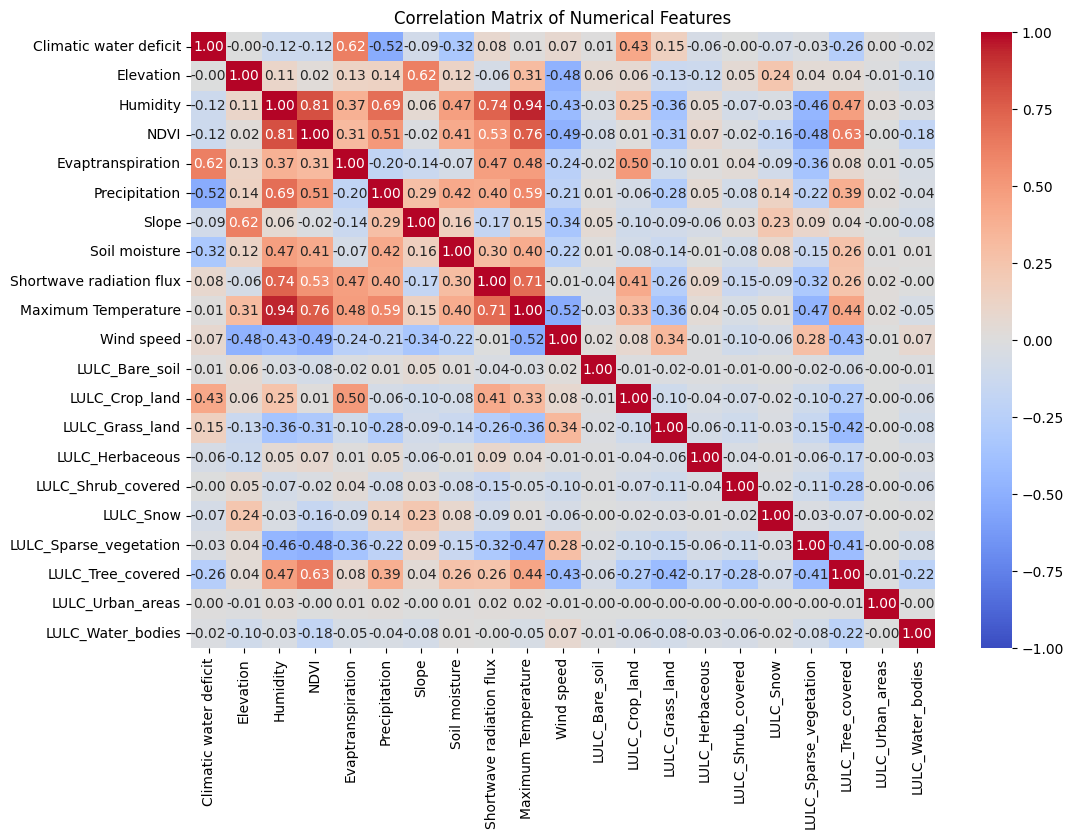

In [ ]:
# Calculate correlation matrix for numerical features
correlation_matrix = X_train_final.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numerical Features")
plt.show()


In [ ]:
# Initialize the RandomForestRegressor
rf = RandomForestRegressor(n_jobs=-1, max_depth=10, random_state=42)

# Fit the RandomForest model to get the feature importances
rf.fit(X_train_final, y_train)

# Initialize Boruta with the RandomForest model
boruta = BorutaPy(estimator=rf, n_estimators=20, max_iter=20, random_state=42, verbose=1)

# Fit Boruta on the preprocessed training data
boruta.fit(X_train_final.values, y_train.values)

# Create a DataFrame for the Boruta results
boruta_feature_stats = pd.DataFrame({
    'Variables': X_train_final.columns,
    'BorutaDecision': ['Confirmed' if decision else 'Rejected' for decision in boruta.support_]
})

# Initialize the DecisionTreeRegressor (CART)
cart_model = DecisionTreeRegressor(random_state=42)

# Fit the CART model to the training data
cart_model.fit(X_train_final, y_train)

# Extract feature importances
feature_importances = cart_model.feature_importances_

# Create a DataFrame for the CART results
cart_feature_stats = pd.DataFrame({
    'Variables': X_train_final.columns,
    'RelativeImportance': feature_importances
})

# Combine Boruta and CART results
combined_feature_stats = boruta_feature_stats.merge(cart_feature_stats, on='Variables')

# Save the combined feature stats (both confirmed and rejected) to a CSV file
combined_feature_stats.to_csv('final_feature_stats_with_rejected.csv', index=False)

# Features removed by Boruta
boruta_removed_features = combined_feature_stats[combined_feature_stats['BorutaDecision'] == 'Rejected']['Variables']

# Features with very low importance in CART (threshold < 0.0005)
cart_removed_features = combined_feature_stats[combined_feature_stats['RelativeImportance'] < 0.0005]['Variables']

# Combine the removed features from both methods
removed_features = pd.concat([boruta_removed_features, cart_removed_features]).unique()

# Print removed features
print("Features removed by Boruta or CART:", removed_features)

# Display the final feature stats for those that are kept
final_feature_stats = combined_feature_stats[~combined_feature_stats['Variables'].isin(removed_features)]
print(final_feature_stats)

# Save the final confirmed features to a CSV file for documentation
final_feature_stats.to_csv('final_confirmed_features.csv', index=False)

# Drop the removed features from the datasets automatically
X_train_selected = X_train_final.drop(columns=removed_features, errors='ignore')
X_val_selected = X_val_final.drop(columns=removed_features, errors='ignore')
X_test_selected = X_test_final.drop(columns=removed_features, errors='ignore')

# Save the selected features datasets for reference
X_train_selected.to_csv('X_train_selected.csv', index=False)
X_val_selected.to_csv('X_val_selected.csv', index=False)
X_test_selected.to_csv('X_test_selected.csv', index=False)

# Display summary
print(f"Final selected features saved to: 'X_train_selected.csv', 'X_val_selected.csv', and 'X_test_selected.csv'")
print("Full feature stats (with rejected) saved to 'final_feature_stats_with_rejected.csv'")


Iteration: 1 / 20
Iteration: 2 / 20
Iteration: 3 / 20
Iteration: 4 / 20
Iteration: 5 / 20
Iteration: 6 / 20
Iteration: 7 / 20
Iteration: 8 / 20


BorutaPy finished running.

Iteration: 	9 / 20
Confirmed: 	11
Tentative: 	0
Rejected: 	10
Features removed by Boruta or CART: ['Slope' 'LULC_Bare_soil' 'LULC_Grass_land' 'LULC_Herbaceous'
 'LULC_Shrub_covered' 'LULC_Snow' 'LULC_Sparse_vegetation'
 'LULC_Tree_covered' 'LULC_Urban_areas' 'LULC_Water_bodies']
                   Variables BorutaDecision  RelativeImportance
0     Climatic water deficit      Confirmed            0.125209
1                  Elevation      Confirmed            0.100461
2                   Humidity      Confirmed            0.050542
3                       NDVI      Confirmed            0.022444
4          Evaptranspiration      Confirmed            0.075391
5              Precipitation      Confirmed            0.071349
7              Soil moisture      Confirmed            0.043403
8   Shortwave radiation flux      

In [ ]:
# # Load the CSV file
# file_path = "/content/final_feature_stats_with_rejected.csv"  # Update with your actual file path
# df1 = pd.read_csv(file_path)

# # Sort by 'RelativeImportance' in descending order
# df_sorted = df1.sort_values(by="RelativeImportance", ascending=False)  # Corrected 'ascending'

# # Save the sorted file
# df_sorted.to_csv("final_feature_stats_sorted.csv", index=False)

# # Display sorted DataFrame
# print(df_sorted)

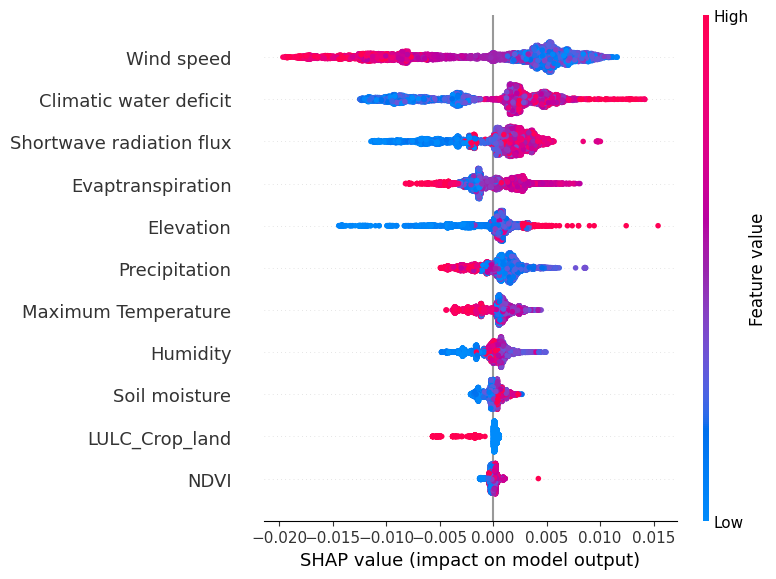

In [ ]:
import shap
import xgboost as xgb
import matplotlib.pyplot as plt

# Convert datasets to XGBoost DMatrix for better performance (optional)
dtrain = xgb.DMatrix(X_train_selected, label=y_train)
dval = xgb.DMatrix(X_val_final, label=y_val)

# Train the XGBoost model
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.01, random_state=42)
xgb_model.fit(X_train_selected, y_train)

# Compute SHAP values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train_selected)

# SHAP summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train_selected, feature_names=X_train_selected.columns)


In [ ]:
X_train_selected

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,-0.830688,-0.218214,1.324667,1.233257,0.604156,0.525807,1.011842,1.087708,0.968376,-0.510223,0.0
1,0.799524,-0.608056,-0.370016,-0.294047,1.017434,-0.709690,-1.102476,-0.675711,-0.280618,-0.916858,0.0
2,0.381872,0.110216,-1.291088,-1.113203,-0.357949,-0.914405,0.421268,-0.950878,-1.403284,1.456970,0.0
3,0.146703,-0.910844,0.775335,0.455542,0.283155,0.643507,0.171739,0.804901,0.605509,-0.733315,0.0
4,0.217869,-0.477207,-1.851333,-1.947729,-1.700576,-0.821806,-1.404596,-0.860161,-2.167361,0.929469,0.0
...,...,...,...,...,...,...,...,...,...,...,...
6752,-1.059826,2.613653,0.129962,-0.777020,-1.159355,2.265296,2.062632,-0.976687,0.556034,-0.915788,0.0
6753,-1.073705,0.206899,0.010595,-0.112351,-0.765094,0.719909,-0.368427,0.147929,-0.118446,0.267178,0.0
6754,0.772862,-0.631607,-0.328959,-0.189129,1.096721,-0.668200,-1.059448,-0.703959,-0.274567,-0.925872,0.0
6755,-0.718586,-0.904886,2.480092,2.108879,-0.616236,2.267797,2.644844,1.327307,1.711243,0.174134,0.0


In [ ]:
X_test_selected

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,0.370637,-0.121730,-1.176259,-1.962385,-0.648101,-0.958061,0.392042,-1.023297,-1.360257,1.350602,0.0
1,3.781663,0.601709,0.849827,-0.330816,2.898495,-0.843171,-1.336715,2.155184,1.679785,0.727194,0.0
2,0.161464,0.090333,0.556241,0.759572,1.203045,-0.246458,0.730078,1.315495,0.815951,-0.203486,0.0
3,1.193754,-0.567825,-0.773498,0.070655,0.542157,-0.976770,-1.172152,-2.103163,-0.934863,-1.075020,0.0
4,0.290762,-0.214656,-0.157417,0.002949,0.458952,-0.252929,-0.443595,0.296875,-0.459257,0.113335,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1444,0.660906,0.549615,0.496612,-0.204269,1.537486,-0.323004,0.411520,1.452371,0.851480,0.235403,1.0
1445,-0.384778,-0.259187,0.143624,0.614816,0.388984,-0.183081,0.296269,0.581223,0.044320,-0.324427,0.0
1446,0.106856,-0.819538,-1.330237,-0.646587,-1.301638,-1.076092,-0.265338,-1.195806,-1.560841,1.549243,0.0
1447,-0.107265,-0.357590,0.291792,0.334854,0.693211,-0.150542,0.037170,0.629824,0.184958,-0.367892,0.0


In [ ]:
X_val_selected

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,-0.126140,1.110494,-0.304912,0.582934,0.159703,-0.636256,-1.185961,-1.438936,0.079180,-1.353503,0.0
1,-0.339928,-0.165704,0.268766,0.636158,0.708478,-0.086076,0.055748,0.684524,0.196598,-0.497706,0.0
2,-0.290365,2.496674,-1.120891,-0.899553,0.503083,-0.510606,-0.958539,-1.620331,-0.427356,-0.776555,0.0
3,-0.228464,-0.724010,-0.852744,-1.057689,-0.141586,-0.431916,0.028194,0.116277,-0.939732,1.281662,0.0
4,-0.747607,-0.415219,-0.472096,-0.439870,-0.373321,-0.269574,-0.068611,0.364672,-0.595013,0.853177,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1443,1.369458,-0.421318,-0.887655,-0.572499,0.478163,-0.904590,-1.077298,-0.912935,-0.809977,-0.140969,0.0
1444,0.502190,0.050326,-1.150496,-0.499219,0.283525,-0.906981,0.090928,-0.997231,-1.206735,0.415546,0.0
1445,0.839211,-0.211422,-1.258890,-1.123027,0.041634,-0.984818,-1.087965,-1.498772,-1.266287,0.716809,0.0
1446,1.936956,-0.866141,-0.539925,-0.012756,1.189711,-0.801626,-0.925062,-1.436754,-0.486344,-1.413691,0.0


In [ ]:
# Concatenate the index columns back with the selected features
X_train_final_with_indices = pd.concat([train_indices.reset_index(drop=True), X_train_selected.reset_index(drop=True)], axis=1)
X_val_final_with_indices = pd.concat([val_indices.reset_index(drop=True), X_val_selected.reset_index(drop=True)], axis=1)
X_test_final_with_indices = pd.concat([test_indices.reset_index(drop=True), X_test_selected.reset_index(drop=True)], axis=1)

# Save the updated datasets
X_train_final_with_indices.to_csv('X_train_final_with_indices.csv', index=False)
X_val_final_with_indices.to_csv('X_val_final_with_indices.csv', index=False)
X_test_final_with_indices.to_csv('X_test_final_with_indices.csv', index=False)


In [ ]:
X_train_final_with_indices

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,20015,49.467217,-92.961333,0.000000,0.0,18.0,1.682080,-0.830688,-0.218214,1.324667,1.233257,0.604156,0.525807,1.011842,1.087708,0.968376,-0.510223,0.0
1,139903,63.133883,-119.294667,0.000000,0.0,0.0,-0.715007,0.799524,-0.608056,-0.370016,-0.294047,1.017434,-0.709690,-1.102476,-0.675711,-0.280618,-0.916858,0.0
2,161762,65.467217,-109.628000,72.111000,0.0,0.0,0.584173,0.381872,0.110216,-1.291088,-1.113203,-0.357949,-0.914405,0.421268,-0.950878,-1.403284,1.456970,0.0
3,35887,51.133883,-82.878000,0.000000,0.0,18.0,1.565920,0.146703,-0.910844,0.775335,0.455542,0.283155,0.643507,0.171739,0.804901,0.605509,-0.733315,0.0
4,174632,66.800550,-89.128000,436.834992,0.0,0.0,-0.672101,0.217869,-0.477207,-1.851333,-1.947729,-1.700576,-0.821806,-1.404596,-0.860161,-2.167361,0.929469,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6752,75708,55.133883,-128.378000,5.000000,0.0,0.0,-0.586667,-1.059826,2.613653,0.129962,-0.777020,-1.159355,2.265296,2.062632,-0.976687,0.556034,-0.915788,0.0
6753,58853,53.383883,-66.128000,0.000000,0.0,0.0,-1.131360,-1.073705,0.206899,0.010595,-0.112351,-0.765094,0.719909,-0.368427,0.147929,-0.118446,0.267178,0.0
6754,139231,63.050550,-119.628000,0.000000,0.0,0.0,-0.549935,0.772862,-0.631607,-0.328959,-0.189129,1.096721,-0.668200,-1.059448,-0.703959,-0.274567,-0.925872,0.0
6755,3663,45.550550,-64.294667,0.000000,8.0,0.0,0.371167,-0.718586,-0.904886,2.480092,2.108879,-0.616236,2.267797,2.644844,1.327307,1.711243,0.174134,0.0


In [ ]:
X_val_final_with_indices

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,136443,62.717217,-133.211333,0.000000,0.0,18.0,1.957200,-0.126140,1.110494,-0.304912,0.582934,0.159703,-0.636256,-1.185961,-1.438936,0.079180,-1.353503,0.0
1,86252,56.300550,-104.044667,0.000000,0.0,18.0,-1.410000,-0.339928,-0.165704,0.268766,0.636158,0.708478,-0.086076,0.055748,0.684524,0.196598,-0.497706,0.0
2,154169,64.717217,-132.378000,5.000000,0.0,0.0,0.745807,-0.290365,2.496674,-1.120891,-0.899553,0.503083,-0.510606,-0.958539,-1.620331,-0.427356,-0.776555,0.0
3,113403,59.717217,-96.294667,0.000000,0.0,0.0,1.685580,-0.228464,-0.724010,-0.852744,-1.057689,-0.141586,-0.431916,0.028194,0.116277,-0.939732,1.281662,0.0
4,101251,58.133883,-97.711333,5.000000,0.0,0.0,0.666379,-0.747607,-0.415219,-0.472096,-0.439870,-0.373321,-0.269574,-0.068611,0.364672,-0.595013,0.853177,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1443,156859,64.967217,-115.961333,0.000000,0.0,0.0,-0.009367,1.369458,-0.421318,-0.887655,-0.572499,0.478163,-0.904590,-1.077298,-0.912935,-0.809977,-0.140969,0.0
1444,163194,65.633883,-114.878000,0.000000,0.0,17.0,-0.108571,0.502190,0.050326,-1.150496,-0.499219,0.283525,-0.906981,0.090928,-0.997231,-1.206735,0.415546,0.0
1445,182438,67.633883,-119.128000,60.827599,0.0,0.0,-0.645085,0.839211,-0.211422,-1.258890,-1.123027,0.041634,-0.984818,-1.087965,-1.498772,-1.266287,0.716809,0.0
1446,170006,66.383883,-131.711333,0.000000,0.0,0.0,0.518746,1.936956,-0.866141,-0.539925,-0.012756,1.189711,-0.801626,-0.925062,-1.436754,-0.486344,-1.413691,0.0


In [ ]:
X_test_final_with_indices

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,164000,65.717217,-110.794667,80.622597,0.0,0.0,0.623167,0.370637,-0.121730,-1.176259,-1.962385,-0.648101,-0.958061,0.392042,-1.023297,-1.360257,1.350602,0.0
1,28077,50.383883,-111.628000,125.000000,13.0,0.0,-0.478534,3.781663,0.601709,0.849827,-0.330816,2.898495,-0.843171,-1.336715,2.155184,1.679785,0.727194,0.0
2,61804,53.717217,-106.628000,0.000000,0.0,18.0,1.254830,0.161464,0.090333,0.556241,0.759572,1.203045,-0.246458,0.730078,1.315495,0.815951,-0.203486,0.0
3,183745,67.800550,-139.961333,0.000000,1.0,0.0,-3.638680,1.193754,-0.567825,-0.773498,0.070655,0.542157,-0.976770,-1.172152,-2.103163,-0.934863,-1.075020,0.0
4,103834,58.467217,-102.628000,0.000000,4.0,18.0,-0.660333,0.290762,-0.214656,-0.157417,0.002949,0.458952,-0.252929,-0.443595,0.296875,-0.459257,0.113335,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1444,57531,53.300550,-107.878000,5.000000,15.0,0.0,1.257830,0.660906,0.549615,0.496612,-0.204269,1.537486,-0.323004,0.411520,1.452371,0.851480,0.235403,1.0
1445,89094,56.633883,-102.128000,0.000000,0.0,18.0,-0.693437,-0.384778,-0.259187,0.143624,0.614816,0.388984,-0.183081,0.296269,0.581223,0.044320,-0.324427,0.0
1446,173585,66.717217,-106.961333,18.027800,0.0,0.0,0.102763,0.106856,-0.819538,-1.330237,-0.646587,-1.301638,-1.076092,-0.265338,-1.195806,-1.560841,1.549243,0.0
1447,84162,56.050550,-102.211333,0.000000,0.0,0.0,-0.584083,-0.107265,-0.357590,0.291792,0.334854,0.693211,-0.150542,0.037170,0.629824,0.184958,-0.367892,0.0


In [ ]:
X_train_final_with_indices

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,20015,49.467217,-92.961333,0.000000,0.0,18.0,1.682080,-0.830688,-0.218214,1.324667,1.233257,0.604156,0.525807,1.011842,1.087708,0.968376,-0.510223,0.0
1,139903,63.133883,-119.294667,0.000000,0.0,0.0,-0.715007,0.799524,-0.608056,-0.370016,-0.294047,1.017434,-0.709690,-1.102476,-0.675711,-0.280618,-0.916858,0.0
2,161762,65.467217,-109.628000,72.111000,0.0,0.0,0.584173,0.381872,0.110216,-1.291088,-1.113203,-0.357949,-0.914405,0.421268,-0.950878,-1.403284,1.456970,0.0
3,35887,51.133883,-82.878000,0.000000,0.0,18.0,1.565920,0.146703,-0.910844,0.775335,0.455542,0.283155,0.643507,0.171739,0.804901,0.605509,-0.733315,0.0
4,174632,66.800550,-89.128000,436.834992,0.0,0.0,-0.672101,0.217869,-0.477207,-1.851333,-1.947729,-1.700576,-0.821806,-1.404596,-0.860161,-2.167361,0.929469,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6752,75708,55.133883,-128.378000,5.000000,0.0,0.0,-0.586667,-1.059826,2.613653,0.129962,-0.777020,-1.159355,2.265296,2.062632,-0.976687,0.556034,-0.915788,0.0
6753,58853,53.383883,-66.128000,0.000000,0.0,0.0,-1.131360,-1.073705,0.206899,0.010595,-0.112351,-0.765094,0.719909,-0.368427,0.147929,-0.118446,0.267178,0.0
6754,139231,63.050550,-119.628000,0.000000,0.0,0.0,-0.549935,0.772862,-0.631607,-0.328959,-0.189129,1.096721,-0.668200,-1.059448,-0.703959,-0.274567,-0.925872,0.0
6755,3663,45.550550,-64.294667,0.000000,8.0,0.0,0.371167,-0.718586,-0.904886,2.480092,2.108879,-0.616236,2.267797,2.644844,1.327307,1.711243,0.174134,0.0


In [ ]:
# Define the features to drop
features_to_drop = ['dist_fores', 'human_foot', 'pdsi', 'tree_speci']

# Load the datasets
train_file = "X_train_final_with_indices.csv"
val_file = "X_val_final_with_indices.csv"
test_file = "X_test_final_with_indices.csv"

X_train_final_with_indices = pd.read_csv(train_file)
X_val_final_with_indices = pd.read_csv(val_file)
X_test_final_with_indices = pd.read_csv(test_file)

# Drop the specified features
X_train_final_with_indices.drop(columns=features_to_drop, errors='ignore', inplace=True)
X_val_final_with_indices.drop(columns=features_to_drop, errors='ignore', inplace=True)
X_test_final_with_indices.drop(columns=features_to_drop, errors='ignore', inplace=True)

# Save the updated datasets
train_updated_file = "X_train_final_with_indices_updated.csv"
val_updated_file = "X_val_final_with_indices_updated.csv"
test_updated_file = "X_test_final_with_indices_updated.csv"

X_train_final_with_indices.to_csv(train_updated_file, index=False)
X_val_final_with_indices.to_csv(val_updated_file, index=False)
X_test_final_with_indices.to_csv(test_updated_file, index=False)



In [ ]:
X_train_final_with_indices

,point_id,lat_dd,long_dd,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,20015,49.467217,-92.961333,-0.830688,-0.218214,1.324667,1.233257,0.604156,0.525807,1.011842,1.087708,0.968376,-0.510223,0.0
1,139903,63.133883,-119.294667,0.799524,-0.608056,-0.370016,-0.294047,1.017434,-0.709690,-1.102476,-0.675711,-0.280618,-0.916858,0.0
2,161762,65.467217,-109.628000,0.381872,0.110216,-1.291088,-1.113203,-0.357949,-0.914405,0.421268,-0.950878,-1.403284,1.456970,0.0
3,35887,51.133883,-82.878000,0.146703,-0.910844,0.775335,0.455542,0.283155,0.643507,0.171739,0.804901,0.605509,-0.733315,0.0
4,174632,66.800550,-89.128000,0.217869,-0.477207,-1.851333,-1.947729,-1.700576,-0.821806,-1.404596,-0.860161,-2.167361,0.929469,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6752,75708,55.133883,-128.378000,-1.059826,2.613653,0.129962,-0.777020,-1.159355,2.265296,2.062632,-0.976687,0.556034,-0.915788,0.0
6753,58853,53.383883,-66.128000,-1.073705,0.206899,0.010595,-0.112351,-0.765094,0.719909,-0.368427,0.147929,-0.118446,0.267178,0.0
6754,139231,63.050550,-119.628000,0.772862,-0.631607,-0.328959,-0.189129,1.096721,-0.668200,-1.059448,-0.703959,-0.274567,-0.925872,0.0
6755,3663,45.550550,-64.294667,-0.718586,-0.904886,2.480092,2.108879,-0.616236,2.267797,2.644844,1.327307,1.711243,0.174134,0.0


In [ ]:
X_val_final_with_indices

,point_id,lat_dd,long_dd,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,136443,62.717217,-133.211333,-0.126140,1.110494,-0.304912,0.582934,0.159703,-0.636256,-1.185961,-1.438936,0.079180,-1.353503,0.0
1,86252,56.300550,-104.044667,-0.339928,-0.165704,0.268766,0.636158,0.708478,-0.086076,0.055748,0.684524,0.196598,-0.497706,0.0
2,154169,64.717217,-132.378000,-0.290365,2.496674,-1.120891,-0.899553,0.503083,-0.510606,-0.958539,-1.620331,-0.427356,-0.776555,0.0
3,113403,59.717217,-96.294667,-0.228464,-0.724010,-0.852744,-1.057689,-0.141586,-0.431916,0.028194,0.116277,-0.939732,1.281662,0.0
4,101251,58.133883,-97.711333,-0.747607,-0.415219,-0.472096,-0.439870,-0.373321,-0.269574,-0.068611,0.364672,-0.595013,0.853177,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1443,156859,64.967217,-115.961333,1.369458,-0.421318,-0.887655,-0.572499,0.478163,-0.904590,-1.077298,-0.912935,-0.809977,-0.140969,0.0
1444,163194,65.633883,-114.878000,0.502190,0.050326,-1.150496,-0.499219,0.283525,-0.906981,0.090928,-0.997231,-1.206735,0.415546,0.0
1445,182438,67.633883,-119.128000,0.839211,-0.211422,-1.258890,-1.123027,0.041634,-0.984818,-1.087965,-1.498772,-1.266287,0.716809,0.0
1446,170006,66.383883,-131.711333,1.936956,-0.866141,-0.539925,-0.012756,1.189711,-0.801626,-0.925062,-1.436754,-0.486344,-1.413691,0.0


In [ ]:
X_test_final_with_indices

,point_id,lat_dd,long_dd,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,164000,65.717217,-110.794667,0.370637,-0.121730,-1.176259,-1.962385,-0.648101,-0.958061,0.392042,-1.023297,-1.360257,1.350602,0.0
1,28077,50.383883,-111.628000,3.781663,0.601709,0.849827,-0.330816,2.898495,-0.843171,-1.336715,2.155184,1.679785,0.727194,0.0
2,61804,53.717217,-106.628000,0.161464,0.090333,0.556241,0.759572,1.203045,-0.246458,0.730078,1.315495,0.815951,-0.203486,0.0
3,183745,67.800550,-139.961333,1.193754,-0.567825,-0.773498,0.070655,0.542157,-0.976770,-1.172152,-2.103163,-0.934863,-1.075020,0.0
4,103834,58.467217,-102.628000,0.290762,-0.214656,-0.157417,0.002949,0.458952,-0.252929,-0.443595,0.296875,-0.459257,0.113335,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1444,57531,53.300550,-107.878000,0.660906,0.549615,0.496612,-0.204269,1.537486,-0.323004,0.411520,1.452371,0.851480,0.235403,1.0
1445,89094,56.633883,-102.128000,-0.384778,-0.259187,0.143624,0.614816,0.388984,-0.183081,0.296269,0.581223,0.044320,-0.324427,0.0
1446,173585,66.717217,-106.961333,0.106856,-0.819538,-1.330237,-0.646587,-1.301638,-1.076092,-0.265338,-1.195806,-1.560841,1.549243,0.0
1447,84162,56.050550,-102.211333,-0.107265,-0.357590,0.291792,0.334854,0.693211,-0.150542,0.037170,0.629824,0.184958,-0.367892,0.0


## K-fold spatial cross validation

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# Load dataset
train_file_path = "X_train_final_with_indices.csv"  # Update with your file path
X_train_final_with_indices = pd.read_csv(train_file_path)

# Extract latitude and longitude
coordinates = X_train_final_with_indices[['lat_dd', 'long_dd']]

# Apply K-Means clustering to assign 10 spatial regions
n_splits = 10
kmeans = KMeans(n_clusters=n_splits, random_state=42, n_init=10)
X_train_final_with_indices['spatial_fold'] = kmeans.fit_predict(coordinates)

# Save the corrected spatial folds dataset
X_train_final_with_indices.to_csv("X_train_final_with_corrected_spatial_folds.csv", index=False)

# Display unique fold values
print("Unique spatial folds assigned:", X_train_final_with_indices['spatial_fold'].unique())
print("Spatial folds have been reassigned and saved to 'X_train_final_with_corrected_spatial_folds.csv'.")


Unique spatial folds assigned: [1 8 2 7 6 3 9 5 4 0]
Spatial folds have been reassigned and saved to 'X_train_final_with_corrected_spatial_folds.csv'.


In [ ]:
tmp = pd.read_csv('X_train_final_with_corrected_spatial_folds.csv')
tmp

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land,spatial_fold
0,20015,49.467217,-92.961333,0.000000,0.0,18.0,1.682080,-0.830688,-0.218214,1.324667,1.233257,0.604156,0.525807,1.011842,1.087708,0.968376,-0.510223,0.0,1
1,139903,63.133883,-119.294667,0.000000,0.0,0.0,-0.715007,0.799524,-0.608056,-0.370016,-0.294047,1.017434,-0.709690,-1.102476,-0.675711,-0.280618,-0.916858,0.0,8
2,161762,65.467217,-109.628000,72.111000,0.0,0.0,0.584173,0.381872,0.110216,-1.291088,-1.113203,-0.357949,-0.914405,0.421268,-0.950878,-1.403284,1.456970,0.0,2
3,35887,51.133883,-82.878000,0.000000,0.0,18.0,1.565920,0.146703,-0.910844,0.775335,0.455542,0.283155,0.643507,0.171739,0.804901,0.605509,-0.733315,0.0,1
4,174632,66.800550,-89.128000,436.834992,0.0,0.0,-0.672101,0.217869,-0.477207,-1.851333,-1.947729,-1.700576,-0.821806,-1.404596,-0.860161,-2.167361,0.929469,0.0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6752,75708,55.133883,-128.378000,5.000000,0.0,0.0,-0.586667,-1.059826,2.613653,0.129962,-0.777020,-1.159355,2.265296,2.062632,-0.976687,0.556034,-0.915788,0.0,4
6753,58853,53.383883,-66.128000,0.000000,0.0,0.0,-1.131360,-1.073705,0.206899,0.010595,-0.112351,-0.765094,0.719909,-0.368427,0.147929,-0.118446,0.267178,0.0,3
6754,139231,63.050550,-119.628000,0.000000,0.0,0.0,-0.549935,0.772862,-0.631607,-0.328959,-0.189129,1.096721,-0.668200,-1.059448,-0.703959,-0.274567,-0.925872,0.0,8
6755,3663,45.550550,-64.294667,0.000000,8.0,0.0,0.371167,-0.718586,-0.904886,2.480092,2.108879,-0.616236,2.267797,2.644844,1.327307,1.711243,0.174134,0.0,3


In [ ]:
tmp['spatial_fold'].value_counts(normalize=True)

,proportion
spatial_fold,
6,0.125943
9,0.114992
0,0.111588
5,0.107000
8,0.099600
2,0.098712
1,0.092201
3,0.090573
4,0.088353


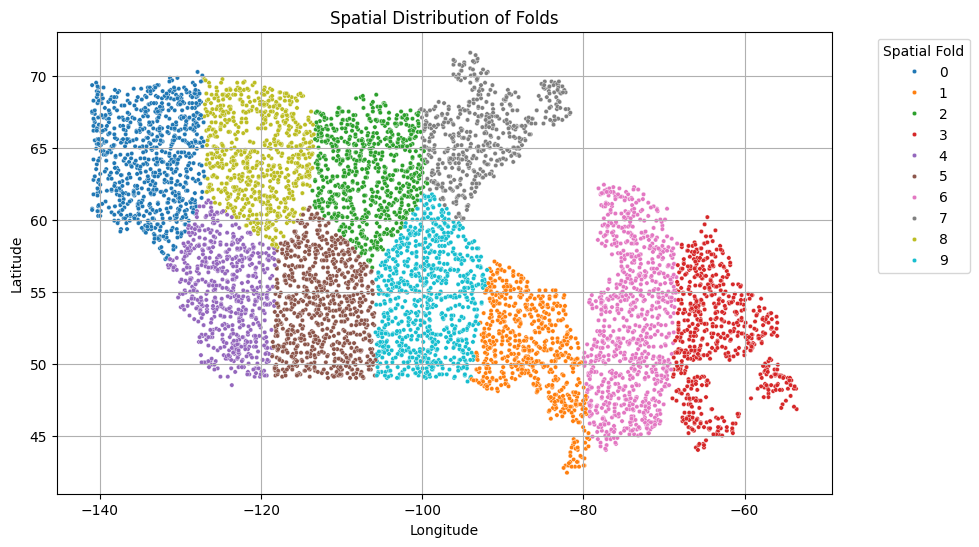

In [ ]:
# Scatter plot of spatial folds
plt.figure(figsize=(10, 6))
sns.scatterplot(x=tmp["long_dd"], y=tmp["lat_dd"], hue=tmp["spatial_fold"], palette="tab10", s=10)
plt.title("Spatial Distribution of Folds")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Spatial Fold", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

In [ ]:
X_train_final_with_indices.columns

Index(['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot',
       'tree_speci', 'pdsi', 'Climatic water deficit', 'Elevation', 'Humidity',
       'NDVI', 'Evaptranspiration', 'Precipitation', 'Soil moisture',
       'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed',
       'LULC_Crop_land', 'spatial_fold'],
      dtype='object')

In [ ]:
X_test_final_with_indices.columns

Index(['point_id', 'lat_dd', 'long_dd', 'Climatic water deficit', 'Elevation',
       'Humidity', 'NDVI', 'Evaptranspiration', 'Precipitation',
       'Soil moisture', 'Shortwave radiation flux', 'Maximum Temperature',
       'Wind speed', 'LULC_Crop_land'],
      dtype='object')

In [ ]:
X_val_final_with_indices.columns

Index(['point_id', 'lat_dd', 'long_dd', 'Climatic water deficit', 'Elevation',
       'Humidity', 'NDVI', 'Evaptranspiration', 'Precipitation',
       'Soil moisture', 'Shortwave radiation flux', 'Maximum Temperature',
       'Wind speed', 'LULC_Crop_land'],
      dtype='object')

In [ ]:
# Define features to drop
drop_features = ["point_id", "lat_dd", "long_dd", "dist_fores", "human_foot", "tree_speci", "pdsi"]

# Load the datasets
train_file = "X_train_final_with_corrected_spatial_folds.csv"
val_file = "X_val_final_with_indices.csv"
test_file = "X_test_final_with_indices.csv"

X_train_final_with_indices = pd.read_csv(train_file)
X_val_final_with_indices = pd.read_csv(val_file)
X_test_final_with_indices = pd.read_csv(test_file)

# Drop the specified features from training, validation, and test datasets
X_train_final_with_indices.drop(columns=drop_features, errors='ignore', inplace=True)
X_val_final_with_indices.drop(columns=drop_features, errors='ignore', inplace=True)
X_test_final_with_indices.drop(columns=drop_features, errors='ignore', inplace=True)

# Save the cleaned datasets
X_train_final_with_indices.to_csv("X_train_final_cleaned.csv", index=False)
X_val_final_with_indices.to_csv("X_val_final_cleaned.csv", index=False)
X_test_final_with_indices.to_csv("X_test_final_cleaned.csv", index=False)



In [ ]:
X_train_final_with_indices

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land,spatial_fold
0,-0.830688,-0.218214,1.324667,1.233257,0.604156,0.525807,1.011842,1.087708,0.968376,-0.510223,0.0,1
1,0.799524,-0.608056,-0.370016,-0.294047,1.017434,-0.709690,-1.102476,-0.675711,-0.280618,-0.916858,0.0,8
2,0.381872,0.110216,-1.291088,-1.113203,-0.357949,-0.914405,0.421268,-0.950878,-1.403284,1.456970,0.0,2
3,0.146703,-0.910844,0.775335,0.455542,0.283155,0.643507,0.171739,0.804901,0.605509,-0.733315,0.0,1
4,0.217869,-0.477207,-1.851333,-1.947729,-1.700576,-0.821806,-1.404596,-0.860161,-2.167361,0.929469,0.0,7
...,...,...,...,...,...,...,...,...,...,...,...,...
6752,-1.059826,2.613653,0.129962,-0.777020,-1.159355,2.265296,2.062632,-0.976687,0.556034,-0.915788,0.0,4
6753,-1.073705,0.206899,0.010595,-0.112351,-0.765094,0.719909,-0.368427,0.147929,-0.118446,0.267178,0.0,3
6754,0.772862,-0.631607,-0.328959,-0.189129,1.096721,-0.668200,-1.059448,-0.703959,-0.274567,-0.925872,0.0,8
6755,-0.718586,-0.904886,2.480092,2.108879,-0.616236,2.267797,2.644844,1.327307,1.711243,0.174134,0.0,3


In [ ]:
X_val_final_with_indices

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,-0.126140,1.110494,-0.304912,0.582934,0.159703,-0.636256,-1.185961,-1.438936,0.079180,-1.353503,0.0
1,-0.339928,-0.165704,0.268766,0.636158,0.708478,-0.086076,0.055748,0.684524,0.196598,-0.497706,0.0
2,-0.290365,2.496674,-1.120891,-0.899553,0.503083,-0.510606,-0.958539,-1.620331,-0.427356,-0.776555,0.0
3,-0.228464,-0.724010,-0.852744,-1.057689,-0.141586,-0.431916,0.028194,0.116277,-0.939732,1.281662,0.0
4,-0.747607,-0.415219,-0.472096,-0.439870,-0.373321,-0.269574,-0.068611,0.364672,-0.595013,0.853177,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1443,1.369458,-0.421318,-0.887655,-0.572499,0.478163,-0.904590,-1.077298,-0.912935,-0.809977,-0.140969,0.0
1444,0.502190,0.050326,-1.150496,-0.499219,0.283525,-0.906981,0.090928,-0.997231,-1.206735,0.415546,0.0
1445,0.839211,-0.211422,-1.258890,-1.123027,0.041634,-0.984818,-1.087965,-1.498772,-1.266287,0.716809,0.0
1446,1.936956,-0.866141,-0.539925,-0.012756,1.189711,-0.801626,-0.925062,-1.436754,-0.486344,-1.413691,0.0


In [ ]:
X_test_final_with_indices

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,0.370637,-0.121730,-1.176259,-1.962385,-0.648101,-0.958061,0.392042,-1.023297,-1.360257,1.350602,0.0
1,3.781663,0.601709,0.849827,-0.330816,2.898495,-0.843171,-1.336715,2.155184,1.679785,0.727194,0.0
2,0.161464,0.090333,0.556241,0.759572,1.203045,-0.246458,0.730078,1.315495,0.815951,-0.203486,0.0
3,1.193754,-0.567825,-0.773498,0.070655,0.542157,-0.976770,-1.172152,-2.103163,-0.934863,-1.075020,0.0
4,0.290762,-0.214656,-0.157417,0.002949,0.458952,-0.252929,-0.443595,0.296875,-0.459257,0.113335,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1444,0.660906,0.549615,0.496612,-0.204269,1.537486,-0.323004,0.411520,1.452371,0.851480,0.235403,1.0
1445,-0.384778,-0.259187,0.143624,0.614816,0.388984,-0.183081,0.296269,0.581223,0.044320,-0.324427,0.0
1446,0.106856,-0.819538,-1.330237,-0.646587,-1.301638,-1.076092,-0.265338,-1.195806,-1.560841,1.549243,0.0
1447,-0.107265,-0.357590,0.291792,0.334854,0.693211,-0.150542,0.037170,0.629824,0.184958,-0.367892,0.0


In [ ]:
X_train_final_with_indices.shape

(6757, 12)

In [ ]:
y_train.shape

(6757,)

## 10-fold spatial cross-validation splitting

In [ ]:
# Ensure indices are aligned
X_train_final_with_indices = X_train_final_with_indices.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

# Extract unique spatial folds
unique_folds = sorted(X_train_final_with_indices["spatial_fold"].unique())

# Prepare to store spatial fold splits
spatial_cv_splits = []

# Perform 10-Fold Spatial Cross-Validation Splitting
for fold in unique_folds:
    print(f"🔹 Preparing Fold {fold}...")

    # Define train and validation sets based on spatial fold
    train_data = X_train_final_with_indices[X_train_final_with_indices["spatial_fold"] != fold]
    val_data = X_train_final_with_indices[X_train_final_with_indices["spatial_fold"] == fold]

    # Extract train and validation indices
    train_indices = train_data.index
    val_indices = val_data.index

    # Drop "spatial_fold" from feature sets
    X_train_fold = train_data.drop(columns=["spatial_fold"])
    X_val_fold = val_data.drop(columns=["spatial_fold"])

    # Extract corresponding target values
    y_train_fold = y_train.iloc[train_indices]
    y_val_fold = y_train.iloc[val_indices]

    # Store the train-validation split for this fold
    spatial_cv_splits.append({
        "fold": fold,
        "X_train": X_train_fold,
        "y_train": y_train_fold,
        "X_val": X_val_fold,
        "y_val": y_val_fold
    })

print(f"\n✅ 10-Fold Spatial Cross-Validation Splits Prepared ({len(spatial_cv_splits)} Folds)")


🔹 Preparing Fold 0...
🔹 Preparing Fold 1...
🔹 Preparing Fold 2...
🔹 Preparing Fold 3...
🔹 Preparing Fold 4...
🔹 Preparing Fold 5...
🔹 Preparing Fold 6...
🔹 Preparing Fold 7...
🔹 Preparing Fold 8...
🔹 Preparing Fold 9...

✅ 10-Fold Spatial Cross-Validation Splits Prepared (10 Folds)


In [ ]:
X_train.shape

(6757, 13)

In [ ]:
y_train.shape

(6757,)

In [ ]:
X_train_fold.shape

(6757, 11)

In [ ]:
y_train_fold.shape

(6757,)

In [ ]:
 X_val_fold.shape

(754, 11)

### Approach

1. Spatial K-fold cross-validation is for model selection, NOT Final training

* In spatial K-fold CV, we train on 9 folds and validate on 1 fold.
* each model in spatial CV is trained on only 90% of the trainig data, which means it does not fully utilize all available training data.
2. Final Model should be trained on FULL training data.
* Once we determine the best model, we should train it on 100% of the training data
* This ensures the model learns all available patterns.

# Deep Neural Network

### Train DNN model using 10-fold CV

This code ensures that each fold is used for validation once, while the remaining 9 folds are used for training.

1. 10-Fold Spatial Cross-Validation

* Train on 9 folds, validate on 1 fold.
* Repeat for each fold.
* Store validation metrics.
2. Train the Final Model

* Use full training dataset (X_train_final_with_indices).
* Validate using separate validation data (X_val_final_with_indices).
3. Evaluate on the Test Set

* Measure performance on unseen test data (X_test_final_with_indices).


🔹 Training Fold 0 (Train on 9 folds, Validate on 1 fold)...
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0047 - mae: 0.0466 - val_loss: 7.1455e-04 - val_mae: 0.0215
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8.8825e-04 - mae: 0.0211 - val_loss: 5.8857e-04 - val_mae: 0.0196
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.0086e-04 - mae: 0.0183 - val_loss: 4.5788e-04 - val_mae: 0.0166
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.3043e-04 - mae: 0.0173 - val_loss: 4.7533e-04 - val_mae: 0.0171
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.5568e-04 - mae: 0.0160 - val_loss: 4.6168e-04 - val_mae: 0.0162
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0364e-04 - mae: 0.0161 - val_loss: 4.5945e-04 - val_mae: 0.0159
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.9379e-04 - mae: 0.0148 - val_loss: 4.8241e-04 - val_mae: 0.0165
Epoch 8/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.0119e-04 - mae: 0.0149 - val_loss: 4.5721e-04 - val_mae: 0.0167


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0090 - mae: 0.0622 - val_loss: 4.6585e-04 - val_mae: 0.0161
Epoch 2/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0011 - mae: 0.0236 - val_loss: 6.7083e-04 - val_mae: 0.0220
Epoch 3/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.9681e-04 - mae: 0.0198 - val_loss: 6.1573e-04 - val_mae: 0.0209
Epoch 4/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.3391e-04 - mae: 0.0175 - val_loss: 4.7914e-04 - val_mae: 0.0181
Epoch 5/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0181e-04 - mae: 0.0169 - val_loss: 3.7896e-04 - val_mae: 0.0159
Epoch 6/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.4358e-04 - mae: 0.0160 - val_loss: 5.5273e-04 - val_mae: 0.0198
Epoch 7/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.2476e-04 - mae: 0.0156 - val_loss: 4.1710e-04 - val_mae: 0.0165
Epoch 8/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.7814e-04 - mae: 0.0146 - val_loss: 4.1225e-04 - val_mae: 0.0167
Epoc

...

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0233 - mae: 0.0906 - val_loss: 0.0017 - val_mae: 0.0295
Epoch 2/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0012 - mae: 0.0257 - val_loss: 0.0017 - val_mae: 0.0285
Epoch 3/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8.1963e-04 - mae: 0.0208 - val_loss: 0.0015 - val_mae: 0.0264
Epoch 4/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.8740e-04 - mae: 0.0187 - val_loss: 0.0016 - val_mae: 0.0259
Epoch 5/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.2314e-04 - mae: 0.0177 - val_loss: 0.0014 - val_mae: 0.0242
Epoch 6/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.8698e-04 - mae: 0.0172 - val_loss: 0.0014 - val_mae: 0.0247
Epoch 7/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.1080e-04 - mae: 0.0158 - val_loss: 0.0014 - val_mae: 0.0233
Epoch 8/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 4.8740e-04 - mae: 0.0153 - val_loss: 0.0012 - val_mae: 0.0229
Epoch 9/100
187/187 ━━━━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0096 - mae: 0.0636 - val_loss: 7.6121e-04 - val_mae: 0.0186
Epoch 2/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0011 - mae: 0.0245 - val_loss: 7.2965e-04 - val_mae: 0.0182
Epoch 3/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.9436e-04 - mae: 0.0215 - val_loss: 5.7916e-04 - val_mae: 0.0155
Epoch 4/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.1724e-04 - mae: 0.0190 - val_loss: 5.0341e-04 - val_mae: 0.0160
Epoch 5/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 6.6044e-04 - mae: 0.0179 - val_loss: 4.6576e-04 - val_mae: 0.0138
Epoch 6/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5.8246e-04 - mae: 0.0165 - val_loss: 4.0784e-04 - val_mae: 0.0133
Epoch 7/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5.0840e-04 - mae: 0.0155 - val_loss: 3.9269e-04 - val_mae: 0.0127
Epoch 8/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.2864e-04 - mae: 0.0154 - val_loss: 3.9021e-04 - val_mae:


🎯 Final Model Performance on Test Data:
Test MSE: 0.0002
Test MAE: 0.0091
Test R² Score: 0.7914


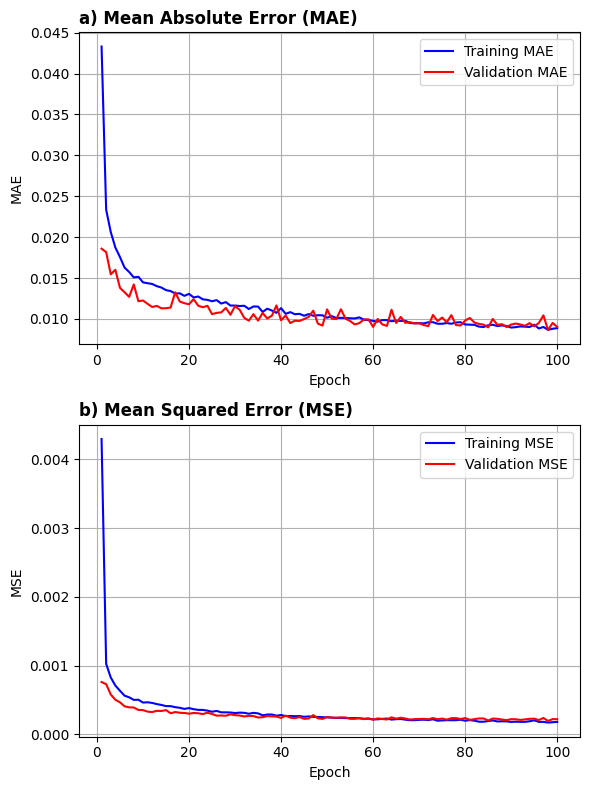

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define a function to create the DNN model
def create_dnn(input_shape, dropout_rate=0.1):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_shape,)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the model
def compile_dnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Store cross-validation results
cv_results = []

# Perform 10-Fold Spatial Cross-Validation
for fold_split in spatial_cv_splits:
    fold = fold_split["fold"]
    X_train_fold = fold_split["X_train"]
    y_train_fold = fold_split["y_train"]
    X_val_fold = fold_split["X_val"]
    y_val_fold = fold_split["y_val"]

    print(f"\n🔹 Training Fold {fold} (Train on 9 folds, Validate on 1 fold)...")

    # Define input shape
    input_shape = X_train_fold.shape[1]

    # Create and compile the model
    dnn_model = create_dnn(input_shape)
    dnn_model = compile_dnn(dnn_model)

    # Train the model
    history = dnn_model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100,
        batch_size=32,
        verbose=1
    )

    # Evaluate the model on the validation set
    val_loss, val_mae = dnn_model.evaluate(X_val_fold, y_val_fold, verbose=0)

    # Make predictions on the validation set
    y_pred_val = dnn_model.predict(X_val_fold)

    # Calculate regression metrics
    mse = mean_squared_error(y_val_fold, y_pred_val)
    mae = mean_absolute_error(y_val_fold, y_pred_val)
    r2 = r2_score(y_val_fold, y_pred_val)

    # Store results
    cv_results.append({
        "Fold": fold,
        "Validation MSE": mse,
        "Validation MAE": mae,
        "Validation R²": r2
    })

    print(f"✅ Fold {fold} Results: MSE={mse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")

# Convert results to DataFrame and display
cv_results_df = pd.DataFrame(cv_results)
print("\n📊 Cross-Validation Results:\n", cv_results_df)

# Train Final Model on Full Training Data
print("\n🚀 Training Final Model on Full Training Data...")
X_train_full = X_train_final_with_indices.drop(columns=["spatial_fold"])
y_train_full = y_train

input_shape = X_train_full.shape[1]
final_model = create_dnn(input_shape)
final_model = compile_dnn(final_model)

history_final = final_model.fit(
    X_train_full, y_train_full,
    validation_data=(X_val_final_with_indices, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

# Evaluate the final model on the test set
print("\n📊 Evaluating Final Model on Test Data...")
test_loss, test_mae = final_model.evaluate(X_test_final_with_indices, y_test, verbose=0)

# Make predictions on the test set
y_pred_test = final_model.predict(X_test_final_with_indices)

# Calculate final test metrics
mse_test = mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Display test metrics
print("\n🎯 Final Model Performance on Test Data:")
print(f"Test MSE: {mse_test:.4f}")
print(f"Test MAE: {mae_test:.4f}")
print(f"Test R² Score: {r2_test:.4f}")

# Save the final model
final_model.save('final_dnn_regression_model.h5')

# Plot training history
import matplotlib.pyplot as plt

def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)

    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']
    val_mse = history.history['val_loss']

    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MAE')
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MSE')
    axes[1].legend()
    axes[1].grid()

    plt.tight_layout()
    plt.show()

# Plot final model training history
plot_training_validation_metrics(history_final)


* the MAE and MSE curves indicate stable learning after arount 40-50 epochs.
* the validation loss does not spike, meaning no severe overfitting is observed.
* the learning rate seems appropriate, as the model gradually converges without sudden fluctuations.

### Hyperparameter Optimization using Grid Search

Grid Search Process:
* Train multiple models using different HP.
* Peroform 10-fold spatila cross validation to evalulate each model.
* Select the best-performing model based on lowest MSE.
* Train the final model using Best HP.
* Evaluate the final model on the test dataset.

In [ ]:
from sklearn.model_selection import ParameterGrid
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import numpy as np

# Define a function to create the DNN model with variable hyperparameters
def create_dnn(input_shape, neurons=64, dropout_rate=0.1):
    model = Sequential([
        Dense(neurons, activation='relu', input_shape=(input_shape,)),
        Dropout(dropout_rate),
        Dense(neurons // 2, activation='relu'),
        Dropout(dropout_rate),
        Dense(neurons // 4, activation='relu'),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Define a function to compile the model
def compile_dnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])
    return model

# Define hyperparameter grid for tuning
param_grid = {
    "neurons": [32, 64, 128, 256],
    "dropout_rate": [0.2, 0.3],
    "learning_rate": [0.001],
    "batch_size": [16],
    "epochs": [40, 50]
}

# Generate all possible hyperparameter combinations
hyperparameter_combinations = list(ParameterGrid(param_grid))

# Track results
grid_search_results = []

# Perform Grid Search
print("\n🔍 Starting Grid Search for Hyperparameter Optimization...\n")

for i, params in enumerate(hyperparameter_combinations):
    print(f"🔹 Training Model {i+1}/{len(hyperparameter_combinations)}: {params}")

    # Extract hyperparameters
    neurons = params["neurons"]
    dropout_rate = params["dropout_rate"]
    learning_rate = params["learning_rate"]
    batch_size = params["batch_size"]
    epochs = params["epochs"]

    # Perform 10-Fold Spatial Cross-Validation
    fold_mse_scores = []
    fold_mae_scores = []

    for fold_split in spatial_cv_splits:
        X_train_fold = fold_split["X_train"]
        y_train_fold = fold_split["y_train"]
        X_val_fold = fold_split["X_val"]
        y_val_fold = fold_split["y_val"]

        # Define input shape
        input_shape = X_train_fold.shape[1]

        # Create and compile the model
        dnn_model = create_dnn(input_shape, neurons, dropout_rate)
        dnn_model = compile_dnn(dnn_model, learning_rate)

        # Train the model
        history = dnn_model.fit(
            X_train_fold, y_train_fold,
            validation_data=(X_val_fold, y_val_fold),
            epochs=epochs,
            batch_size=batch_size,
            verbose=0  # Suppress training logs
        )

        # Evaluate the model
        val_loss, val_mae = dnn_model.evaluate(X_val_fold, y_val_fold, verbose=0)

        # Store fold results
        fold_mse_scores.append(val_loss)
        fold_mae_scores.append(val_mae)

    # Compute average validation scores across folds
    avg_mse = np.mean(fold_mse_scores)
    avg_mae = np.mean(fold_mae_scores)

    # Store results
    grid_search_results.append({
        "neurons": neurons,
        "dropout_rate": dropout_rate,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "epochs": epochs,
        "avg_mse": avg_mse,
        "avg_mae": avg_mae
    })

    print(f"✅ Model {i+1} - Avg MSE: {avg_mse:.4f}, Avg MAE: {avg_mae:.4f}\n")

# Convert results to DataFrame and sort by MSE (lower is better)
import pandas as pd
grid_search_df = pd.DataFrame(grid_search_results)
grid_search_df = grid_search_df.sort_values(by="avg_mse")

# Save results
grid_search_df.to_csv("grid_search_results.csv", index=False)

# Display top 5 best models
print("\n🏆 Best Hyperparameter Combinations:\n")
print(grid_search_df.head())

# Extract best hyperparameters
best_params = grid_search_df.iloc[0].to_dict()
print("\n🌟 Best Hyperparameters Found:", best_params)

# Train Final Model with Best Hyperparameters
print("\n🚀 Training Final Model with Best Hyperparameters...")

X_train_full = X_train_final_with_indices.drop(columns=["spatial_fold"])
y_train_full = y_train

input_shape = X_train_full.shape[1]
final_model = create_dnn(input_shape, best_params["neurons"], best_params["dropout_rate"])
final_model = compile_dnn(final_model, best_params["learning_rate"])

history_final = final_model.fit(
    X_train_full, y_train_full,
    validation_data=(X_val_final_with_indices, y_val),
    epochs=int(best_params["epochs"]),
    batch_size=int(best_params["batch_size"]),
    verbose=1
)

# Evaluate the final model on the test set
print("\n📊 Evaluating Final Model on Test Data...")
test_loss, test_mae = final_model.evaluate(X_test_final_with_indices, y_test, verbose=0)

# Make predictions on the test set
y_pred_test = final_model.predict(X_test_final_with_indices)

# Calculate final test metrics
mse_test = mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Display test metrics
print("\n🎯 Final Model Performance on Test Data:")
print(f"Test MSE: {mse_test:.4f}")
print(f"Test MAE: {mae_test:.4f}")
print(f"Test R² Score: {r2_test:.4f}")

# Save the best final model
final_model.save('final_dnn_best_model.h5')

# Plot training history
import matplotlib.pyplot as plt

def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)

    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']
    val_mse = history.history['val_loss']

    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MAE')
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MSE')
    axes[1].legend()
    axes[1].grid()

    plt.tight_layout()
    plt.show()

# Plot final model training history
plot_training_validation_metrics(history_final)



🔍 Starting Grid Search for Hyperparameter Optimization...

🔹 Training Model 1/16: {'batch_size': 16, 'dropout_rate': 0.2, 'epochs': 40, 'learning_rate': 0.001, 'neurons': 32}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

✅ Model 1 - Avg MSE: 0.0006, Avg MAE: 0.0173

🔹 Training Model 2/16: {'batch_size': 16, 'dropout_rate': 0.2, 'epochs': 40, 'learning_rate': 0.001, 'neurons': 64}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

✅ Model 2 - Avg MSE: 0.0006, Avg MAE: 0.0152

🔹 Training Model 3/16: {'batch_size': 16, 'dropout_rate': 0.2, 'epochs': 40, 'learning_rate': 0.001, 'neurons': 128}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

✅ Model 3 - Avg MSE: 0.0006, Avg MAE: 0.0146

🔹 Training Model 4/16: {'batch_size': 16, 'dropout_rate': 0.2, 'epochs': 40, 'learning_rate': 0.001, 'neurons': 256}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

KeyboardInterrupt: 

add R^2

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from itertools import product

# Define hyperparameter grid
param_grid = {
    "neurons": [32, 64, 128, 256],
    "dropout_rate": [0.1, 0.2, 0.3],
    "learning_rate": [0.001],
    "batch_size": [16, 32],
    "epochs": [20, 30, 50, 80]
}

# Generate all combinations of hyperparameters
param_combinations = list(product(
    param_grid["neurons"],
    param_grid["dropout_rate"],
    param_grid["learning_rate"],
    param_grid["batch_size"],
    param_grid["epochs"]
))

# Initialize variables to store best model and results
best_params = None
best_mae = float("inf")
results = []

# Loop through each hyperparameter combination
for i, (neurons, dropout_rate, learning_rate, batch_size, epochs) in enumerate(param_combinations, start=1):
    print(f"\n🔹 Training Model {i}/{len(param_combinations)}: "
          f"{{'batch_size': {batch_size}, 'dropout_rate': {dropout_rate}, 'epochs': {epochs}, "
          f"'neurons': {neurons}, 'learning_rate': {learning_rate}}}")

    fold_mse, fold_mae, fold_r2 = [], [], []

    # **Perform 10-Fold Spatial Cross-Validation**
    for fold in range(10):
        print(f"➡️ Fold {fold}: Training on 9 folds, validating on 1 fold...")

        # Train on 9 folds, validate on 1 fold
        train_data = X_train_final_with_indices[X_train_final_with_indices["spatial_fold"] != fold]
        val_data = X_train_final_with_indices[X_train_final_with_indices["spatial_fold"] == fold]

        # Extract X and y, drop the spatial fold column
        X_train_fold = train_data.drop(columns=["spatial_fold"])
        y_train_fold = y_train.loc[X_train_fold.index]

        X_val_fold = val_data.drop(columns=["spatial_fold"])
        y_val_fold = y_train.loc[X_val_fold.index]

        # Build the model
        model = Sequential([
            Dense(neurons, activation='relu', input_shape=(X_train_fold.shape[1],)),
            Dropout(dropout_rate),
            Dense(neurons // 2, activation='relu'),
            Dropout(dropout_rate),
            Dense(neurons // 4, activation='relu'),
            Dense(1, activation='linear')  # Regression output
        ])

        # Compile the model
        model.compile(optimizer=Adam(learning_rate=learning_rate),
                      loss='mse', metrics=['mae'])

        # Train the model
        history = model.fit(
            X_train_fold, y_train_fold,
            validation_data=(X_val_fold, y_val_fold),
            epochs=epochs,
            batch_size=batch_size,
            verbose=0  # Set to 1 to see logs
        )

        # Make predictions on validation fold
        y_val_pred = model.predict(X_val_fold)

        # Compute metrics for this fold
        mse = mean_squared_error(y_val_fold, y_val_pred)
        mae = mean_absolute_error(y_val_fold, y_val_pred)
        r2 = r2_score(y_val_fold, y_val_pred)

        fold_mse.append(mse)
        fold_mae.append(mae)
        fold_r2.append(r2)

    # **Compute Average Metrics Across 10 Folds**
    avg_mse = np.mean(fold_mse)
    avg_mae = np.mean(fold_mae)
    avg_r2 = np.mean(fold_r2)

    # Store results
    results.append({
        "batch_size": batch_size,
        "dropout_rate": dropout_rate,
        "epochs": epochs,
        "neurons": neurons,
        "learning_rate": learning_rate,
        "Avg MSE": avg_mse,
        "Avg MAE": avg_mae,
        "Avg R2": avg_r2
    })

    print(f"✔ Model {i} - Avg MSE: {avg_mse:.6f}, Avg MAE: {avg_mae:.6f}, Avg R²: {avg_r2:.4f}")

    # Update best parameters if the current model is better
    if avg_mae < best_mae:
        best_mae = avg_mae
        best_params = {
            "batch_size": batch_size,
            "dropout_rate": dropout_rate,
            "epochs": epochs,
            "neurons": neurons,
            "learning_rate": learning_rate
        }

# Convert results to a DataFrame and sort by best MAE
df_results = pd.DataFrame(results).sort_values(by="Avg MAE", ascending=True)

# Save results
df_results.to_csv("hyperparameter_tuning_results.csv", index=False)

print("\n✅ Best Hyperparameters (Lowest MAE):")
print(best_params)

# Display the best hyperparameters
import ace_tools as tools
tools.display_dataframe_to_user(name="Hyperparameter Tuning Results", dataframe=df_results)



🔹 Training Model 1/96: {'batch_size': 16, 'dropout_rate': 0.1, 'epochs': 20, 'neurons': 32, 'learning_rate': 0.001}
➡️ Fold 0: Training on 9 folds, validating on 1 fold...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
➡️ Fold 1: Training on 9 folds, validating on 1 fold...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
➡️ Fold 2: Training on 9 folds, validating on 1 fold...


...

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
➡️ Fold 1: Training on 9 folds, validating on 1 fold...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
➡️ Fold 2: Training on 9 folds, validating on 1 fold...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Train Deep Learning model DNN

## DNN

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define a function to create the DNN model
def create_dnn(input_shape, dropout_rate=0.2):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_shape,)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the model
def compile_dnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Define input shape
input_shape = X_train_selected.shape[1]

# Create and compile the model
dnn_model = create_dnn(input_shape)
dnn_model = compile_dnn(dnn_model)

# Train the model
history = dnn_model.fit(
    X_train_selected, y_train,
    validation_data=(X_val_selected, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_mae = dnn_model.evaluate(X_test_selected, y_test, verbose=0)

# Make predictions on the test set
y_pred = dnn_model.predict(X_test_selected)

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display metrics
print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2 Score:", r2)

# Save the model
dnn_model.save('dnn_regression_model.h5')



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.0018 - mae: 0.0247 - val_loss: 4.0048e-04 - val_mae: 0.0132
Epoch 2/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 4.2877e-04 - mae: 0.0132 - val_loss: 2.9914e-04 - val_mae: 0.0110
Epoch 3/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 3.3959e-04 - mae: 0.0116 - val_loss: 2.6733e-04 - val_mae: 0.0101
Epoch 4/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 3.0839e-04 - mae: 0.0111 - val_loss: 2.4254e-04 - val_mae: 0.0096
Epoch 5/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 2.8734e-04 - mae: 0.0107 - val_loss: 2.2786e-04 - val_mae: 0.0097
Epoch 6/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 2.7551e-04 - mae: 0.0105 - val_loss: 2.2217e-04 - val_mae: 0.0095
Epoch 7/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 2.6187e-04 - mae: 0.0102 - val_loss: 2.2797e-04 - val_mae: 0.0100
Epoch 8/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 2.5643e-04 - mae: 0.0101 - val_

Test Loss (MSE): 0.00015078454453032464
Test MAE: 0.007655235938727856
Mean Squared Error: 0.00015078448648393557
Mean Absolute Error: 0.0076552340452077875
R^2 Score: 0.8547411187140799


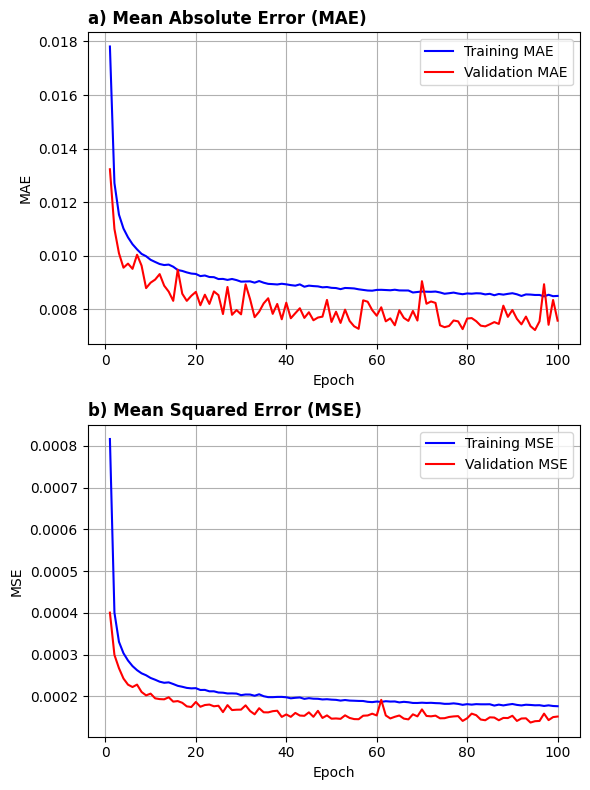

In [ ]:
import matplotlib.pyplot as plt

# Function to plot training and validation metrics
def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)  # Number of epochs

    # Extract metrics from the training history
    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']  # Loss is typically MSE for regression
    val_mse = history.history['val_loss']

    # Create subplots
    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    # Plot MAE
    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=10)
    axes[0].set_ylabel('MAE', fontsize=10)
    axes[0].legend(loc='upper right')
    axes[0].grid()

    # Plot MSE
    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=10)
    axes[1].set_ylabel('MSE', fontsize=10)
    axes[1].legend(loc='upper right')
    axes[1].grid()

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

# Assuming you have the training history from model.fit
# Example for DNN:
# history = dnn_model.fit(X_train_selected, y_train, validation_data=(X_val_selected, y_val), epochs=100, batch_size=32, verbose=1)

# Call the function with your model's training history
plot_training_validation_metrics(history)


## DNN 2

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define a function to create the DNN model
def create_dnn(input_shape, dropout_rate=0.2):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_shape,)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the model
def compile_dnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Define input shape
input_shape = X_train_selected.shape[1]

# Create and compile the model
dnn_model = create_dnn(input_shape)
dnn_model = compile_dnn(dnn_model)

# Train the model
history = dnn_model.fit(
    X_train_selected, y_train,
    validation_data=(X_val_selected, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_mae = dnn_model.evaluate(X_test_selected, y_test, verbose=0)

# Make predictions on the test set
y_pred = dnn_model.predict(X_test_selected)

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display metrics
print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2 Score:", r2)

# Save the model
dnn_model.save('dnn_regression_model.h5')



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 0.0031 - mae: 0.0320 - val_loss: 4.3830e-04 - val_mae: 0.0139
Epoch 2/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 4.8378e-04 - mae: 0.0142 - val_loss: 3.3956e-04 - val_mae: 0.0111
Epoch 3/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 3.8185e-04 - mae: 0.0125 - val_loss: 3.0929e-04 - val_mae: 0.0121
Epoch 4/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 3.4198e-04 - mae: 0.0118 - val_loss: 2.7482e-04 - val_mae: 0.0100
Epoch 5/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 3.1690e-04 - mae: 0.0113 - val_loss: 2.5809e-04 - val_mae: 0.0107
Epoch 6/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 3.0288e-04 - mae: 0.0110 - val_loss: 2.5251e-04 - val_mae: 0.0104
Epoch 7/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 2.8792e-04 - mae: 0.0108 - val_loss: 2.2738e-04 - val_mae: 0.0094
Epoch 8/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 2.7783e-04 - mae: 0.0106 - val_loss: 2.3

Test Loss (MSE): 0.00017472515173722059
Test MAE: 0.008463012985885143
Mean Squared Error: 0.00017472526971877954
Mean Absolute Error: 0.008463015632191834
R^2 Score: 0.8316776625794686


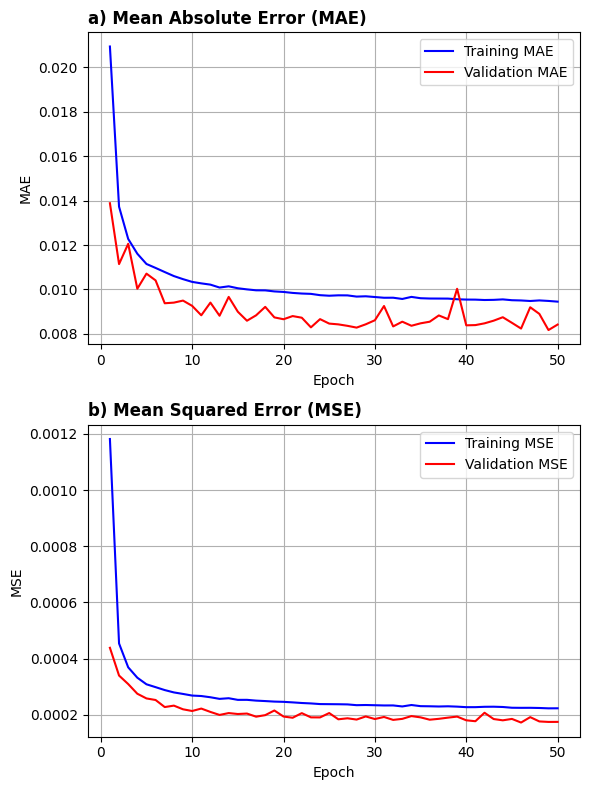

In [ ]:
import matplotlib.pyplot as plt

# Function to plot training and validation metrics
def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)  # Number of epochs

    # Extract metrics from the training history
    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']  # Loss is typically MSE for regression
    val_mse = history.history['val_loss']

    # Create subplots
    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    # Plot MAE
    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=10)
    axes[0].set_ylabel('MAE', fontsize=10)
    axes[0].legend(loc='upper right')
    axes[0].grid()

    # Plot MSE
    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=10)
    axes[1].set_ylabel('MSE', fontsize=10)
    axes[1].legend(loc='upper right')
    axes[1].grid()

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

# Assuming you have the training history from model.fit
# Example for DNN:
# history = dnn_model.fit(X_train_selected, y_train, validation_data=(X_val_selected, y_val), epochs=100, batch_size=32, verbose=1)

# Call the function with your model's training history
plot_training_validation_metrics(history)


## DNN3

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4046/4046 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.0014 - mae: 0.0227 - val_loss: 3.3643e-04 - val_mae: 0.0117
Epoch 2/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 3.6466e-04 - mae: 0.0121 - val_loss: 2.7413e-04 - val_mae: 0.0109
Epoch 3/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - loss: 3.0388e-04 - mae: 0.0109 - val_loss: 2.4404e-04 - val_mae: 0.0103
Epoch 4/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 2.6758e-04 - mae: 0.0103 - val_loss: 2.3336e-04 - val_mae: 0.0093
Epoch 5/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 2.5397e-04 - mae: 0.0100 - val_loss: 2.0765e-04 - val_mae: 0.0095
Epoch 6/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 2.3199e-04 - mae: 0.0096 - val_loss: 1.9716e-04 - val_mae: 0.0090
Epoch 7/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 2.2609e-04 - mae: 0.0094 - val_loss: 1.9045e-04 - val_mae: 0.0086
Epoch 8/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 2.2381e-04 - mae: 0.0094 - val_loss: 1.763

Test Loss (MSE): 0.00011331694986438379
Test MAE: 0.006865341681987047
Mean Squared Error: 0.00011331688505365239
Mean Absolute Error: 0.006865341389741641
R^2 Score: 0.8908356931304574


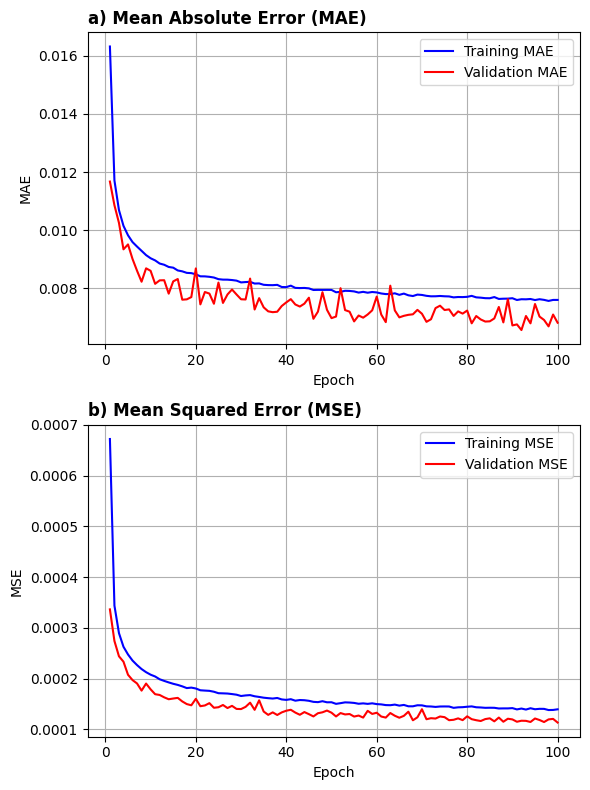

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define a function to create the DNN model
def create_dnn(input_shape, dropout_rate=0.1):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_shape,)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the model
def compile_dnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Define input shape
input_shape = X_train_selected.shape[1]

# Create and compile the model
dnn_model = create_dnn(input_shape)
dnn_model = compile_dnn(dnn_model)

# Train the model
history = dnn_model.fit(
    X_train_selected, y_train,
    validation_data=(X_val_selected, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_mae = dnn_model.evaluate(X_test_selected, y_test, verbose=0)

# Make predictions on the test set
y_pred = dnn_model.predict(X_test_selected)

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display metrics
print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2 Score:", r2)

# Save the model
dnn_model.save('dnn_regression_model.h5')

import matplotlib.pyplot as plt

# Function to plot training and validation metrics
def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)  # Number of epochs

    # Extract metrics from the training history
    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']  # Loss is typically MSE for regression
    val_mse = history.history['val_loss']

    # Create subplots
    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    # Plot MAE
    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=10)
    axes[0].set_ylabel('MAE', fontsize=10)
    axes[0].legend(loc='upper right')
    axes[0].grid()

    # Plot MSE
    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=10)
    axes[1].set_ylabel('MSE', fontsize=10)
    axes[1].legend(loc='upper right')
    axes[1].grid()

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

# Assuming you have the training history from model.fit
# Example for DNN:
# history = dnn_model.fit(X_train_selected, y_train, validation_data=(X_val_selected, y_val), epochs=100, batch_size=32, verbose=1)

# Call the function with your model's training history
plot_training_validation_metrics(history)


## RNN

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 74s 17ms/step - loss: 0.0012 - mae: 0.0207 - val_loss: 3.4664e-04 - val_mae: 0.0119
Epoch 2/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 79s 16ms/step - loss: 3.5685e-04 - mae: 0.0122 - val_loss: 2.8725e-04 - val_mae: 0.0110
Epoch 3/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 83s 17ms/step - loss: 3.0436e-04 - mae: 0.0110 - val_loss: 2.5144e-04 - val_mae: 0.0096
Epoch 4/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 68s 17ms/step - loss: 2.6909e-04 - mae: 0.0103 - val_loss: 2.2286e-04 - val_mae: 0.0092
Epoch 5/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 87s 18ms/step - loss: 2.4545e-04 - mae: 0.0098 - val_loss: 2.2029e-04 - val_mae: 0.0090
Epoch 6/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 76s 17ms/step - loss: 2.3559e-04 - mae: 0.0096 - val_loss: 2.0659e-04 - val_mae: 0.0086
Epoch 7/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 83s 17ms/step - loss: 2.2468e-04 - mae: 0.0093 - val_loss: 2.1092e-04 - val_mae: 0.0088
Epoch 8/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 68s 17ms/step - loss: 2.1134e-04 - mae: 0.00

Test Loss (MSE): 0.0001333827240159735
Test MAE: 0.006864922121167183
Mean Squared Error: 0.00013338266145758072
Mean Absolute Error: 0.0068649218815973094
R^2 Score: 0.8715052414338993


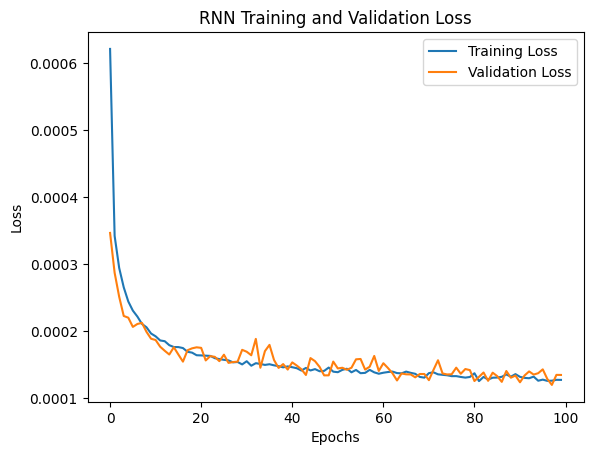

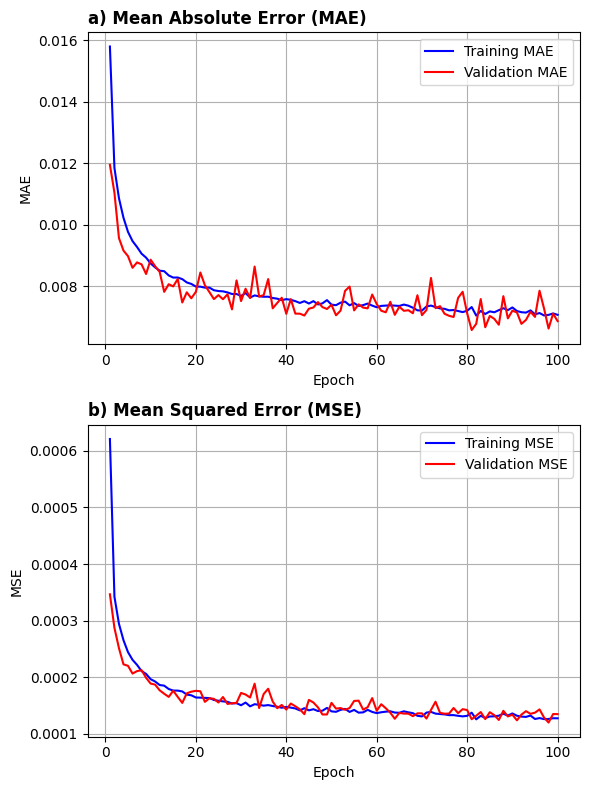

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Define a function to create the RNN model
def create_rnn(input_shape, dropout_rate=0.2):
    model = Sequential([
        SimpleRNN(128, activation='relu', input_shape=(input_shape, 1), return_sequences=True),
        Dropout(dropout_rate),
        SimpleRNN(64, activation='relu', return_sequences=True),
        Dropout(dropout_rate),
        SimpleRNN(32, activation='relu'),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the model
def compile_rnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Reshape input data for RNN
X_train_reshaped = np.expand_dims(X_train_selected, axis=-1)
X_val_reshaped = np.expand_dims(X_val_selected, axis=-1)
X_test_reshaped = np.expand_dims(X_test_selected, axis=-1)

# Define input shape
input_shape = X_train_reshaped.shape[1]

# Create and compile the model
rnn_model = create_rnn(input_shape)
rnn_model = compile_rnn(rnn_model)

# Train the model
history = rnn_model.fit(
    X_train_reshaped, y_train,
    validation_data=(X_val_reshaped, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_mae = rnn_model.evaluate(X_test_reshaped, y_test, verbose=0)

# Make predictions on the test set
y_pred = rnn_model.predict(X_test_reshaped)

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display metrics
print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2 Score:", r2)

# Save the model
rnn_model.save('rnn_regression_model.h5')

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('RNN Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Function to plot training and validation metrics
def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)  # Number of epochs

    # Extract metrics from the training history
    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']  # Loss is typically MSE for regression
    val_mse = history.history['val_loss']

    # Create subplots
    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    # Plot MAE
    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=10)
    axes[0].set_ylabel('MAE', fontsize=10)
    axes[0].legend(loc='upper right')
    axes[0].grid()

    # Plot MSE
    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=10)
    axes[1].set_ylabel('MSE', fontsize=10)
    axes[1].legend(loc='upper right')
    axes[1].grid()

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

# Call the function with your model's training history
plot_training_validation_metrics(history)


## RNN2

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4046/4046 ━━━━━━━━━━━━━━━━━━━━ 63s 14ms/step - loss: 9.5993e-04 - mae: 0.0193 - val_loss: 3.2821e-04 - val_mae: 0.0111
Epoch 2/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 57s 14ms/step - loss: 3.5403e-04 - mae: 0.0119 - val_loss: 2.9152e-04 - val_mae: 0.0119
Epoch 3/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 58s 14ms/step - loss: 3.1049e-04 - mae: 0.0111 - val_loss: 2.8165e-04 - val_mae: 0.0101
Epoch 4/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 79s 14ms/step - loss: 2.7284e-04 - mae: 0.0104 - val_loss: 2.3462e-04 - val_mae: 0.0093
Epoch 5/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 81s 14ms/step - loss: 2.5640e-04 - mae: 0.0101 - val_loss: 2.1713e-04 - val_mae: 0.0092
Epoch 6/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 83s 14ms/step - loss: 2.4140e-04 - mae: 0.0098 - val_loss: 2.3368e-04 - val_mae: 0.0091
Epoch 7/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 2.3276e-04 - mae: 0.0096 - val_loss: 2.0379e-04 - val_mae: 0.0090
Epoch 8/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 82s 14ms/step - loss: 2.2931e-04 - mae: 0.0095 - val_loss: 

Test Loss (MSE): 0.00016390549717471004
Test MAE: 0.008429013192653656
Mean Squared Error: 0.0001639055302319602
Mean Absolute Error: 0.008429016082949433
R^2 Score: 0.8421009049852974


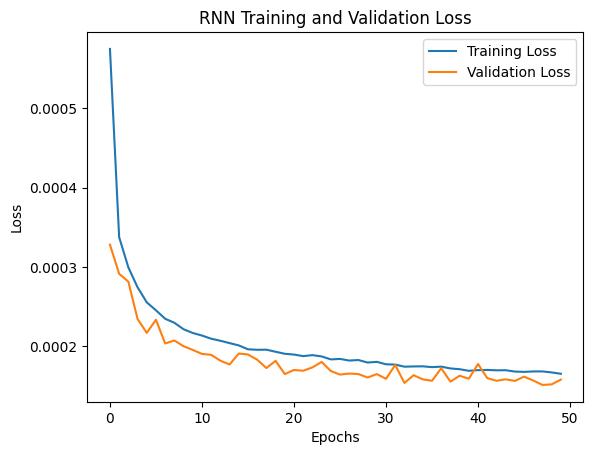

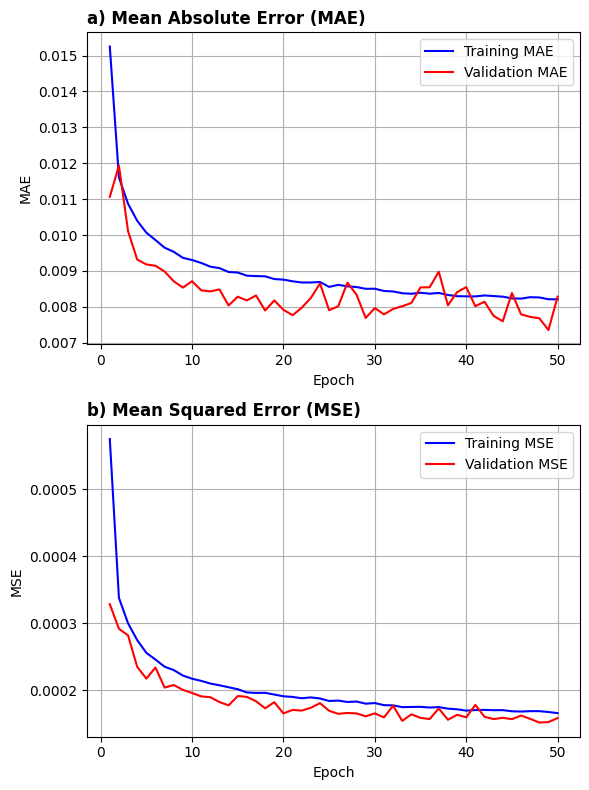

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Define a function to create the RNN model
def create_rnn(input_shape, dropout_rate=0.2):
    model = Sequential([
        SimpleRNN(64, activation='relu', input_shape=(input_shape, 1), return_sequences=True),
        Dropout(dropout_rate),
        SimpleRNN(64, activation='relu', return_sequences=True),
        Dropout(dropout_rate),
        SimpleRNN(32, activation='relu'),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the model
def compile_rnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Reshape input data for RNN
X_train_reshaped = np.expand_dims(X_train_selected, axis=-1)
X_val_reshaped = np.expand_dims(X_val_selected, axis=-1)
X_test_reshaped = np.expand_dims(X_test_selected, axis=-1)

# Define input shape
input_shape = X_train_reshaped.shape[1]

# Create and compile the model
rnn_model = create_rnn(input_shape)
rnn_model = compile_rnn(rnn_model)

# Train the model
history = rnn_model.fit(
    X_train_reshaped, y_train,
    validation_data=(X_val_reshaped, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_mae = rnn_model.evaluate(X_test_reshaped, y_test, verbose=0)

# Make predictions on the test set
y_pred = rnn_model.predict(X_test_reshaped)

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display metrics
print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2 Score:", r2)

# Save the model
rnn_model.save('rnn_regression_model.h5')

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('RNN Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Function to plot training and validation metrics
def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)  # Number of epochs

    # Extract metrics from the training history
    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']  # Loss is typically MSE for regression
    val_mse = history.history['val_loss']

    # Create subplots
    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    # Plot MAE
    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=10)
    axes[0].set_ylabel('MAE', fontsize=10)
    axes[0].legend(loc='upper right')
    axes[0].grid()

    # Plot MSE
    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=10)
    axes[1].set_ylabel('MSE', fontsize=10)
    axes[1].legend(loc='upper right')
    axes[1].grid()

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

# Call the function with your model's training history
plot_training_validation_metrics(history)


## RNN3

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 72s 17ms/step - loss: 9.4934e-04 - mae: 0.0187 - val_loss: 3.2908e-04 - val_mae: 0.0109
Epoch 2/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 84s 17ms/step - loss: 3.4412e-04 - mae: 0.0118 - val_loss: 2.7327e-04 - val_mae: 0.0109
Epoch 3/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 56s 14ms/step - loss: 2.9793e-04 - mae: 0.0109 - val_loss: 2.7186e-04 - val_mae: 0.0105
Epoch 4/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 57s 14ms/step - loss: 2.7125e-04 - mae: 0.0104 - val_loss: 2.3773e-04 - val_mae: 0.0094
Epoch 5/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 81s 14ms/step - loss: 2.5499e-04 - mae: 0.0100 - val_loss: 2.1758e-04 - val_mae: 0.0091
Epoch 6/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 56s 14ms/step - loss: 2.3572e-04 - mae: 0.0097 - val_loss: 2.0675e-04 - val_mae: 0.0090
Epoch 7/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 80s 14ms/step - loss: 2.3000e-04 - mae: 0.0096 - val_loss: 2.1293e-04 - val_mae: 0.0098
Epoch 8/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 82s 13ms/step - loss: 2.2494e-04 - mae: 0.0094 -

Test Loss (MSE): 0.00015783242997713387
Test MAE: 0.00801057182252407
Mean Squared Error: 0.00015783232397555757
Mean Absolute Error: 0.00801057181464564
R^2 Score: 0.8479515542609288


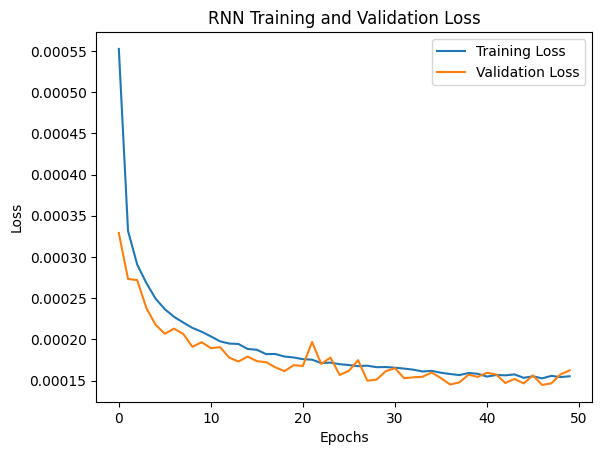

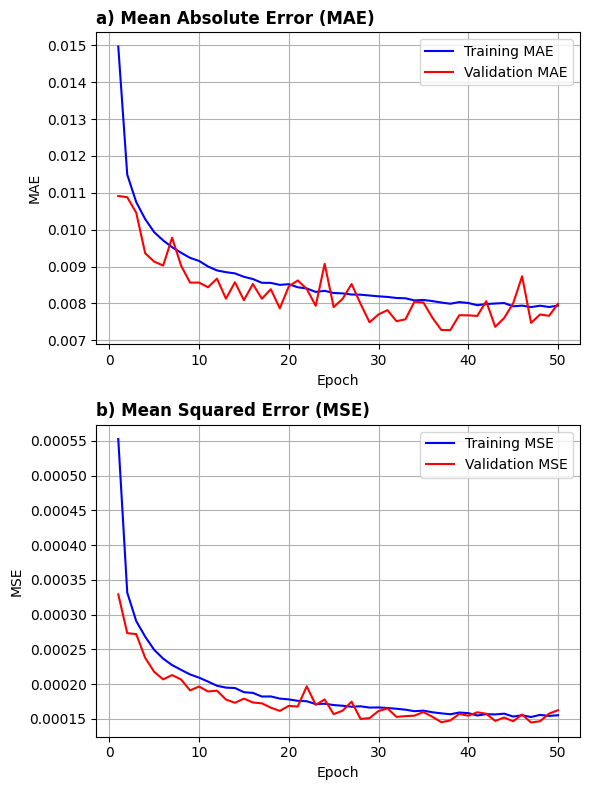

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Define a function to create the RNN model
def create_rnn(input_shape, dropout_rate=0.1):
    model = Sequential([
        SimpleRNN(64, activation='relu', input_shape=(input_shape, 1), return_sequences=True),
        Dropout(dropout_rate),
        SimpleRNN(64, activation='relu', return_sequences=True),
        Dropout(dropout_rate),
        SimpleRNN(32, activation='relu'),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the model
def compile_rnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Reshape input data for RNN
X_train_reshaped = np.expand_dims(X_train_selected, axis=-1)
X_val_reshaped = np.expand_dims(X_val_selected, axis=-1)
X_test_reshaped = np.expand_dims(X_test_selected, axis=-1)

# Define input shape
input_shape = X_train_reshaped.shape[1]

# Create and compile the model
rnn_model = create_rnn(input_shape)
rnn_model = compile_rnn(rnn_model)

# Train the model
history = rnn_model.fit(
    X_train_reshaped, y_train,
    validation_data=(X_val_reshaped, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_mae = rnn_model.evaluate(X_test_reshaped, y_test, verbose=0)

# Make predictions on the test set
y_pred = rnn_model.predict(X_test_reshaped)

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display metrics
print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2 Score:", r2)

# Save the model
rnn_model.save('rnn_regression_model.h5')

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('RNN Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Function to plot training and validation metrics
def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)  # Number of epochs

    # Extract metrics from the training history
    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']  # Loss is typically MSE for regression
    val_mse = history.history['val_loss']

    # Create subplots
    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    # Plot MAE
    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=10)
    axes[0].set_ylabel('MAE', fontsize=10)
    axes[0].legend(loc='upper right')
    axes[0].grid()

    # Plot MSE
    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=10)
    axes[1].set_ylabel('MSE', fontsize=10)
    axes[1].legend(loc='upper right')
    axes[1].grid()

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

# Call the function with your model's training history
plot_training_validation_metrics(history)


## BiRNN

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 155s 36ms/step - loss: 0.0014 - mae: 0.0212 - val_loss: 3.4088e-04 - val_mae: 0.0113
Epoch 2/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 199s 36ms/step - loss: 3.4160e-04 - mae: 0.0118 - val_loss: 3.1509e-04 - val_mae: 0.0108
Epoch 3/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 145s 36ms/step - loss: 2.8301e-04 - mae: 0.0107 - val_loss: 2.5879e-04 - val_mae: 0.0101
Epoch 4/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 201s 36ms/step - loss: 2.5098e-04 - mae: 0.0100 - val_loss: 2.1768e-04 - val_mae: 0.0090
Epoch 5/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 202s 36ms/step - loss: 2.2963e-04 - mae: 0.0095 - val_loss: 2.1434e-04 - val_mae: 0.0094
Epoch 6/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 204s 36ms/step - loss: 2.1164e-04 - mae: 0.0091 - val_loss: 1.9676e-04 - val_mae: 0.0086
Epoch 7/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 201s 36ms/step - loss: 2.0080e-04 - mae: 0.0089 - val_loss: 1.9695e-04 - val_mae: 0.0086
Epoch 8/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 201s 35ms/step - loss: 1.9247e-04 - m

Test Loss (MSE): 0.00011321288911858574
Test MAE: 0.006423044018447399
Mean Squared Error: 0.00011321291325487335
Mean Absolute Error: 0.006423043822952098
R^2 Score: 0.8909358548084132


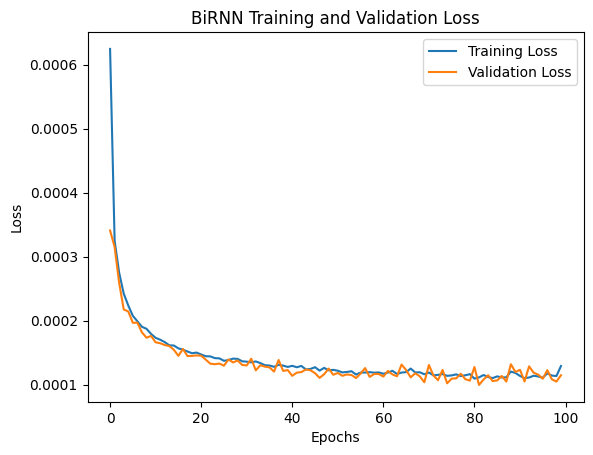

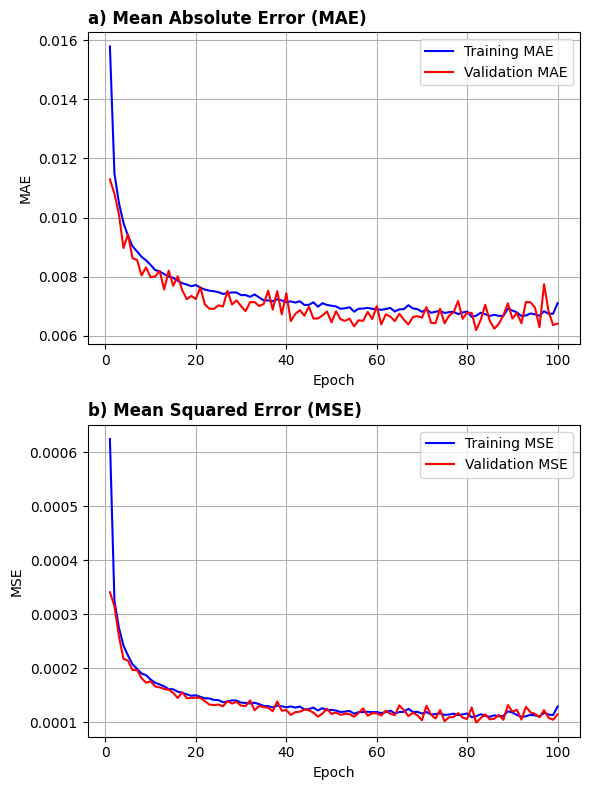

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Define a function to create the BiRNN model
def create_birnn(input_shape, dropout_rate=0.2):
    model = Sequential([
        Bidirectional(SimpleRNN(128, activation='relu', return_sequences=True), input_shape=(input_shape, 1)),
        Dropout(dropout_rate),
        Bidirectional(SimpleRNN(64, activation='relu', return_sequences=True)),
        Dropout(dropout_rate),
        Bidirectional(SimpleRNN(32, activation='relu')),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the model
def compile_birnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Reshape input data for BiRNN
X_train_reshaped = np.expand_dims(X_train_selected, axis=-1)
X_val_reshaped = np.expand_dims(X_val_selected, axis=-1)
X_test_reshaped = np.expand_dims(X_test_selected, axis=-1)

# Define input shape
input_shape = X_train_reshaped.shape[1]

# Create and compile the model
birnn_model = create_birnn(input_shape)
birnn_model = compile_birnn(birnn_model)

# Train the model
history = birnn_model.fit(
    X_train_reshaped, y_train,
    validation_data=(X_val_reshaped, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_mae = birnn_model.evaluate(X_test_reshaped, y_test, verbose=0)

# Make predictions on the test set
y_pred = birnn_model.predict(X_test_reshaped)

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display metrics
print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2 Score:", r2)

# Save the model
birnn_model.save('birnn_regression_model.h5')

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('BiRNN Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Function to plot training and validation metrics
def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)  # Number of epochs

    # Extract metrics from the training history
    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']  # Loss is typically MSE for regression
    val_mse = history.history['val_loss']

    # Create subplots
    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    # Plot MAE
    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=10)
    axes[0].set_ylabel('MAE', fontsize=10)
    axes[0].legend(loc='upper right')
    axes[0].grid()

    # Plot MSE
    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=10)
    axes[1].set_ylabel('MSE', fontsize=10)
    axes[1].legend(loc='upper right')
    axes[1].grid()

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

# Call the function with your model's training history
plot_training_validation_metrics(history)


## BiRNN2

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4046/4046 ━━━━━━━━━━━━━━━━━━━━ 137s 32ms/step - loss: 0.0012 - mae: 0.0216 - val_loss: 3.7029e-04 - val_mae: 0.0112
Epoch 2/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 127s 28ms/step - loss: 3.4389e-04 - mae: 0.0117 - val_loss: 2.5521e-04 - val_mae: 0.0096
Epoch 3/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 138s 27ms/step - loss: 2.8219e-04 - mae: 0.0105 - val_loss: 2.3339e-04 - val_mae: 0.0095
Epoch 4/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 150s 29ms/step - loss: 2.5624e-04 - mae: 0.0101 - val_loss: 2.4598e-04 - val_mae: 0.0096
Epoch 5/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 137s 28ms/step - loss: 2.3573e-04 - mae: 0.0096 - val_loss: 2.3029e-04 - val_mae: 0.0097
Epoch 6/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 114s 28ms/step - loss: 2.2470e-04 - mae: 0.0094 - val_loss: 1.9570e-04 - val_mae: 0.0092
Epoch 7/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 138s 27ms/step - loss: 2.0914e-04 - mae: 0.0091 - val_loss: 1.9372e-04 - val_mae: 0.0087
Epoch 8/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 147s 28ms/step - loss: 2.1070e-04 - mae: 0.0091 - val_lo

Test Loss (MSE): 0.0001352476392639801
Test MAE: 0.007439228240400553
Mean Squared Error: 0.0001352476325731937
Mean Absolute Error: 0.00743922623584093
R^2 Score: 0.8697086135167869


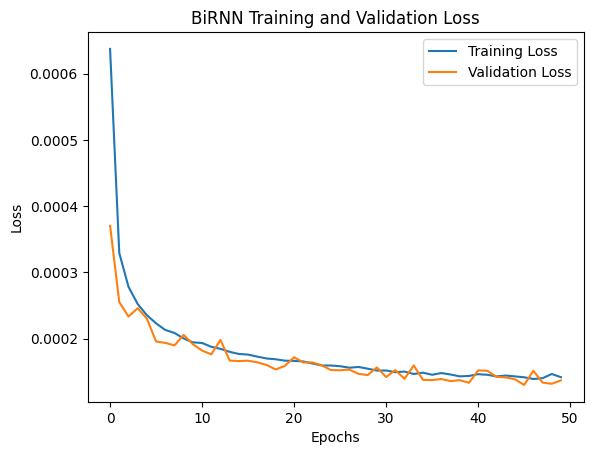

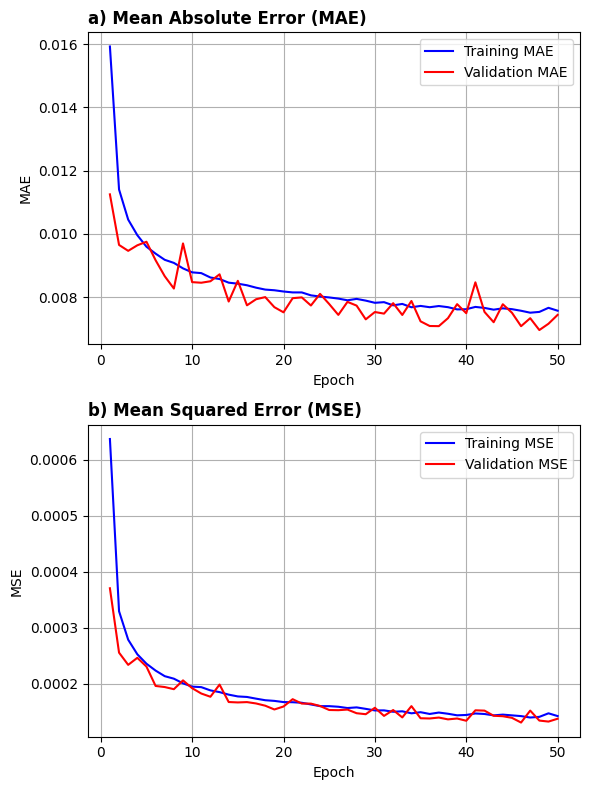

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Define a function to create the BiRNN model
def create_birnn(input_shape, dropout_rate=0.2):
    model = Sequential([
        Bidirectional(SimpleRNN(64, activation='relu', return_sequences=True), input_shape=(input_shape, 1)),
        Dropout(dropout_rate),
        Bidirectional(SimpleRNN(64, activation='relu', return_sequences=True)),
        Dropout(dropout_rate),
        Bidirectional(SimpleRNN(32, activation='relu')),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the model
def compile_birnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Reshape input data for BiRNN
X_train_reshaped = np.expand_dims(X_train_selected, axis=-1)
X_val_reshaped = np.expand_dims(X_val_selected, axis=-1)
X_test_reshaped = np.expand_dims(X_test_selected, axis=-1)

# Define input shape
input_shape = X_train_reshaped.shape[1]

# Create and compile the model
birnn_model = create_birnn(input_shape)
birnn_model = compile_birnn(birnn_model)

# Train the model
history = birnn_model.fit(
    X_train_reshaped, y_train,
    validation_data=(X_val_reshaped, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_mae = birnn_model.evaluate(X_test_reshaped, y_test, verbose=0)

# Make predictions on the test set
y_pred = birnn_model.predict(X_test_reshaped)

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display metrics
print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2 Score:", r2)

# Save the model
birnn_model.save('birnn_regression_model.h5')

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('BiRNN Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Function to plot training and validation metrics
def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)  # Number of epochs

    # Extract metrics from the training history
    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']  # Loss is typically MSE for regression
    val_mse = history.history['val_loss']

    # Create subplots
    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    # Plot MAE
    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=10)
    axes[0].set_ylabel('MAE', fontsize=10)
    axes[0].legend(loc='upper right')
    axes[0].grid()

    # Plot MSE
    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=10)
    axes[1].set_ylabel('MSE', fontsize=10)
    axes[1].legend(loc='upper right')
    axes[1].grid()

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

# Call the function with your model's training history
plot_training_validation_metrics(history)


## Encoder-Decoder BiRNN

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, Dropout, RepeatVector, Concatenate
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Define a function to create the Encoder-Decoder BiRNN model
def create_encoder_decoder_birnn(input_shape, dropout_rate=0.2):
    # Encoder
    encoder_inputs = Input(shape=(input_shape, 1))
    encoder = Bidirectional(LSTM(256, return_state=True, return_sequences=True, dropout=dropout_rate))
    encoder_outputs, forward_h, forward_c, backward_h, backward_c = encoder(encoder_inputs)
    state_h = Concatenate()([forward_h, backward_h])  # Combine forward and backward hidden states
    state_c = Concatenate()([forward_c, backward_c])  # Combine forward and backward cell states
    encoder_states = [state_h, state_c]

    # Decoder
    decoder_inputs = RepeatVector(1)(state_h)  # Repeat the context vector for the decoder
    decoder_lstm = LSTM(512, return_sequences=False, dropout=dropout_rate)  # Match the state size (128 + 128 = 256)
    decoder_outputs = decoder_lstm(decoder_inputs, initial_state=encoder_states)
    decoder_dense = Dense(1, activation='linear')  # Output layer for regression
    outputs = decoder_dense(decoder_outputs)

    # Define the model
    model = Model(inputs=encoder_inputs, outputs=outputs)
    return model

# Compile the model
def compile_encoder_decoder_birnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Reshape input data for Encoder-Decoder BiRNN
X_train_reshaped = np.expand_dims(X_train_selected, axis=-1)
X_val_reshaped = np.expand_dims(X_val_selected, axis=-1)
X_test_reshaped = np.expand_dims(X_test_selected, axis=-1)

# Define input shape
input_shape = X_train_reshaped.shape[1]

# Create and compile the model
encoder_decoder_birnn_model = create_encoder_decoder_birnn(input_shape)
encoder_decoder_birnn_model = compile_encoder_decoder_birnn(encoder_decoder_birnn_model)

# Train the model
history = encoder_decoder_birnn_model.fit(
    X_train_reshaped, y_train,
    validation_data=(X_val_reshaped, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_mae = encoder_decoder_birnn_model.evaluate(X_test_reshaped, y_test, verbose=0)

# Make predictions on the test set
y_pred = encoder_decoder_birnn_model.predict(X_test_reshaped)

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display metrics
print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2 Score:", r2)

# Save the model
encoder_decoder_birnn_model.save('encoder_decoder_birnn_regression_model.h5')

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Encoder-Decoder BiRNN Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Function to plot training and validation metrics
def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)  # Number of epochs

    # Extract metrics from the training history
    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']  # Loss is typically MSE for regression
    val_mse = history.history['val_loss']

    # Create subplots
    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    # Plot MAE
    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=10)
    axes[0].set_ylabel('MAE', fontsize=10)
    axes[0].legend(loc='upper right')
    axes[0].grid()

    # Plot MSE
    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=10)
    axes[1].set_ylabel('MSE', fontsize=10)
    axes[1].legend(loc='upper right')
    axes[1].grid()

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

# Call the function with your model's training history
plot_training_validation_metrics(history)


Epoch 1/100
 356/4046 ━━━━━━━━━━━━━━━━━━━━ 8:31 139ms/step - loss: 0.0012 - mae: 0.0240

KeyboardInterrupt: 

## Encoder-Decoder BiRNN2

Epoch 1/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 475s 116ms/step - loss: 8.2922e-04 - mae: 0.0196 - val_loss: 4.8594e-04 - val_mae: 0.0143
Epoch 2/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 499s 116ms/step - loss: 4.9648e-04 - mae: 0.0141 - val_loss: 4.1152e-04 - val_mae: 0.0135
Epoch 3/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 502s 116ms/step - loss: 4.0245e-04 - mae: 0.0126 - val_loss: 3.2011e-04 - val_mae: 0.0117
Epoch 4/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 502s 116ms/step - loss: 3.4101e-04 - mae: 0.0116 - val_loss: 2.7449e-04 - val_mae: 0.0103
Epoch 5/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 473s 117ms/step - loss: 2.9221e-04 - mae: 0.0107 - val_loss: 2.6178e-04 - val_mae: 0.0104
Epoch 6/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 500s 116ms/step - loss: 2.6258e-04 - mae: 0.0101 - val_loss: 2.4914e-04 - val_mae: 0.0100
Epoch 7/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 517s 128ms/step - loss: 2.3814e-04 - mae: 0.0096 - val_loss: 2.1810e-04 - val_mae: 0.0093
Epoch 8/50
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 523s 118ms/step - loss: 2.1841e-04

Test Loss (MSE): 0.00014436514175031334
Test MAE: 0.006888100877404213
Mean Squared Error: 0.0001443652455659056
Mean Absolute Error: 0.00688810101528726
R^2 Score: 0.8609251219640242


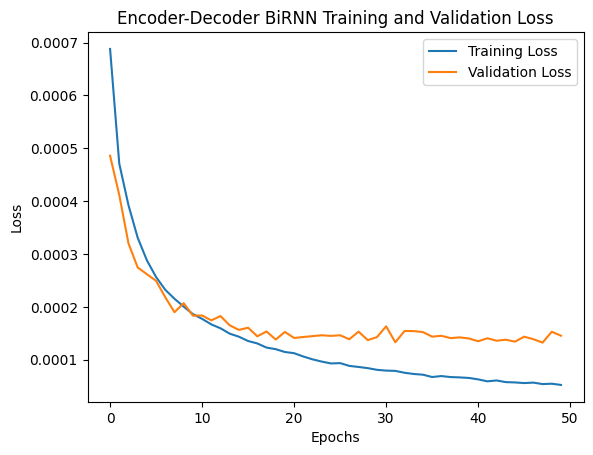

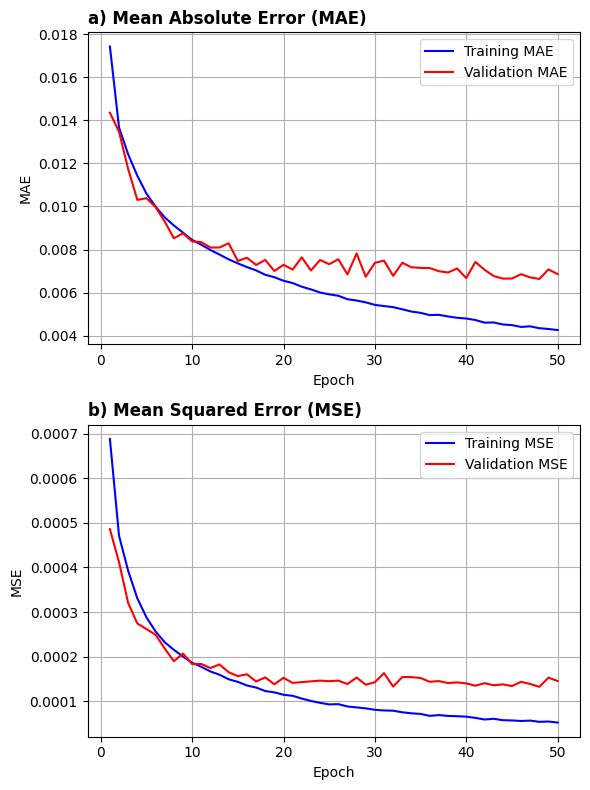

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, Dropout, RepeatVector, Concatenate
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Define a function to create the Encoder-Decoder BiRNN model
def create_encoder_decoder_birnn(input_shape, dropout_rate=0.1):
    # Encoder
    encoder_inputs = Input(shape=(input_shape, 1))
    encoder = Bidirectional(LSTM(256, return_state=True, return_sequences=True, dropout=dropout_rate))
    encoder_outputs, forward_h, forward_c, backward_h, backward_c = encoder(encoder_inputs)
    state_h = Concatenate()([forward_h, backward_h])  # Combine forward and backward hidden states
    state_c = Concatenate()([forward_c, backward_c])  # Combine forward and backward cell states
    encoder_states = [state_h, state_c]

    # Decoder
    decoder_inputs = RepeatVector(1)(state_h)  # Repeat the context vector for the decoder
    decoder_lstm = LSTM(512, return_sequences=False, dropout=dropout_rate)  # Match the state size (128 + 128 = 256)
    decoder_outputs = decoder_lstm(decoder_inputs, initial_state=encoder_states)
    decoder_dense = Dense(1, activation='linear')  # Output layer for regression
    outputs = decoder_dense(decoder_outputs)

    # Define the model
    model = Model(inputs=encoder_inputs, outputs=outputs)
    return model

# Compile the model
def compile_encoder_decoder_birnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Reshape input data for Encoder-Decoder BiRNN
X_train_reshaped = np.expand_dims(X_train_selected, axis=-1)
X_val_reshaped = np.expand_dims(X_val_selected, axis=-1)
X_test_reshaped = np.expand_dims(X_test_selected, axis=-1)

# Define input shape
input_shape = X_train_reshaped.shape[1]

# Create and compile the model
encoder_decoder_birnn_model = create_encoder_decoder_birnn(input_shape)
encoder_decoder_birnn_model = compile_encoder_decoder_birnn(encoder_decoder_birnn_model)

# Train the model
history = encoder_decoder_birnn_model.fit(
    X_train_reshaped, y_train,
    validation_data=(X_val_reshaped, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_mae = encoder_decoder_birnn_model.evaluate(X_test_reshaped, y_test, verbose=0)

# Make predictions on the test set
y_pred = encoder_decoder_birnn_model.predict(X_test_reshaped)

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display metrics
print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2 Score:", r2)

# Save the model
encoder_decoder_birnn_model.save('encoder_decoder_birnn_regression_model.h5')

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Encoder-Decoder BiRNN Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Function to plot training and validation metrics
def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)  # Number of epochs

    # Extract metrics from the training history
    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']  # Loss is typically MSE for regression
    val_mse = history.history['val_loss']

    # Create subplots
    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    # Plot MAE
    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=10)
    axes[0].set_ylabel('MAE', fontsize=10)
    axes[0].legend(loc='upper right')
    axes[0].grid()

    # Plot MSE
    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=10)
    axes[1].set_ylabel('MSE', fontsize=10)
    axes[1].legend(loc='upper right')
    axes[1].grid()

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

# Call the function with your model's training history
plot_training_validation_metrics(history)


# Integrating GWO for Hyperparameters tuning

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import random

# Step 1: Define the DNN model creation function
def create_dnn(input_shape, params):
    model = Sequential([
        Dense(params['units1'], activation='relu', input_shape=(input_shape,)),
        Dropout(params['dropout']),
        Dense(params['units2'], activation='relu'),
        Dropout(params['dropout']),
        Dense(params['units3'], activation='relu'),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Step 2: Compile the DNN model
def compile_dnn(model, learning_rate):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse', metrics=['mae'])
    return model

# Step 3: Define the evaluation function for GWO
def evaluate_model(params, input_shape, X_train, y_train, X_val, y_val):
    model = create_dnn(input_shape, params)
    model = compile_dnn(model, params['learning_rate'])
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,  # Reduced for optimization speed
        batch_size=int(params['batch_size']),
        verbose=0
    )
    val_loss = history.history['val_loss'][-1]  # Validation loss at the last epoch
    return val_loss

# Step 4: Initialize GWO Population
def initialize_population(pop_size, param_bounds):
    population = []
    for _ in range(pop_size):
        wolf = {
            'units1': random.randint(*param_bounds['units1']),
            'units2': random.randint(*param_bounds['units2']),
            'units3': random.randint(*param_bounds['units3']),
            'dropout': random.uniform(*param_bounds['dropout']),
            'learning_rate': random.uniform(*param_bounds['learning_rate']),
            'batch_size': random.randint(*param_bounds['batch_size']),
            'fitness': None
        }
        population.append(wolf)
    return population

# Step 5: Grey Wolf Optimizer
def grey_wolf_optimizer(X_train, y_train, X_val, y_val, input_shape, param_bounds, pop_size=5, max_iter=10):
    population = initialize_population(pop_size, param_bounds)
    alpha, beta, delta = None, None, None  # Best three wolves

    for iteration in range(max_iter):
        # Evaluate fitness
        for wolf in population:
            if wolf['fitness'] is None:
                wolf['fitness'] = evaluate_model(wolf, input_shape, X_train, y_train, X_val, y_val)

        # Update alpha, beta, delta wolves
        population = sorted(population, key=lambda x: x['fitness'])
        alpha, beta, delta = population[0], population[1], population[2]

        # Update positions of wolves
        a = 2 - iteration * (2 / max_iter)  # Linearly decreasing from 2 to 0
        for wolf in population:
            for key in wolf.keys():
                if key == 'fitness':
                    continue
                r1, r2 = random.random(), random.random()
                A1, C1 = 2 * a * r1 - a, 2 * r2
                D_alpha = abs(C1 * alpha[key] - wolf[key])
                X1 = alpha[key] - A1 * D_alpha

                r1, r2 = random.random(), random.random()
                A2, C2 = 2 * a * r1 - a, 2 * r2
                D_beta = abs(C2 * beta[key] - wolf[key])
                X2 = beta[key] - A2 * D_beta

                r1, r2 = random.random(), random.random()
                A3, C3 = 2 * a * r1 - a, 2 * r2
                D_delta = abs(C3 * delta[key] - wolf[key])
                X3 = delta[key] - A3 * D_delta

                # Update position
                wolf[key] = (X1 + X2 + X3) / 3

                # Ensure bounds
                if key.startswith('units'):
                    wolf[key] = int(np.clip(round(wolf[key]), param_bounds[key][0], param_bounds[key][1]))
                elif key == 'batch_size':
                    wolf[key] = int(np.clip(round(wolf[key]), param_bounds[key][0], param_bounds[key][1]))
                else:
                    wolf[key] = np.clip(wolf[key], param_bounds[key][0], param_bounds[key][1])

        print(f"Iteration {iteration + 1}/{max_iter}, Best Fitness: {alpha['fitness']}")

    return alpha

# Step 6: Define Hyperparameter Bounds
param_bounds = {
    'units1': (128, 256),
    'units2': (32, 64),
    'units3': (16, 32),
    'dropout': (0.1, 0.3),
    'learning_rate': (0.001, 0.01),
    'batch_size': (32, 64)
}

# Step 7: Run GWO Optimization
input_shape = X_train_selected.shape[1]  # Define input shape
best_params = grey_wolf_optimizer(
    X_train=X_train_selected, y_train=y_train,
    X_val=X_val_selected, y_val=y_val,
    input_shape=input_shape,
    param_bounds=param_bounds,
    pop_size=5, max_iter=20
)

# Step 8: Print Best Hyperparameters
print("Best Hyperparameters Found:", best_params)

# Step 9: Train and Evaluate Best Model
best_model = create_dnn(input_shape, best_params)
best_model = compile_dnn(best_model, best_params['learning_rate'])
history = best_model.fit(
    X_train_selected, y_train,
    validation_data=(X_val_selected, y_val),
    epochs=100,
    batch_size=best_params['batch_size'],
    verbose=1
)

# Evaluate on test set
test_loss, test_mae = best_model.evaluate(X_test_selected, y_test, verbose=0)
y_pred = best_model.predict(X_test_selected)

# Calculate test metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

Iteration 1/20, Best Fitness: 0.00015380445984192193
Iteration 2/20, Best Fitness: 0.00015380445984192193
Iteration 3/20, Best Fitness: 0.00015380445984192193
Iteration 4/20, Best Fitness: 0.00015380445984192193
Iteration 5/20, Best Fitness: 0.00015380445984192193
Iteration 6/20, Best Fitness: 0.00015380445984192193
Iteration 7/20, Best Fitness: 0.00015380445984192193
Iteration 8/20, Best Fitness: 0.00015380445984192193
Iteration 9/20, Best Fitness: 0.00015380445984192193
Iteration 10/20, Best Fitness: 0.00015380445984192193
Iteration 11/20, Best Fitness: 0.00015380445984192193
Iteration 12/20, Best Fitness: 0.00015380445984192193
Iteration 13/20, Best Fitness: 0.00015380445984192193
Iteration 14/20, Best Fitness: 0.00015380445984192193
Iteration 15/20, Best Fitness: 0.00015380445984192193
Iteration 16/20, Best Fitness: 0.00015380445984192193
Iteration 17/20, Best Fitness: 0.00015380445984192193
Iteration 18/20, Best Fitness: 0.00015380445984192193
Iteration 19/20, Best Fitness: 0.0001

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3808/3808 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 0.0017 - mae: 0.0246 - val_loss: 3.8371e-04 - val_mae: 0.0125
Epoch 2/100
3808/3808 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 4.0915e-04 - mae: 0.0131 - val_loss: 3.1557e-04 - val_mae: 0.0112
Epoch 3/100
3808/3808 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 3.4188e-04 - mae: 0.0118 - val_loss: 2.6722e-04 - val_mae: 0.0102
Epoch 4/100
3808/3808 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 3.0702e-04 - mae: 0.0111 - val_loss: 2.4335e-04 - val_mae: 0.0097
Epoch 5/100
3808/3808 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 2.8859e-04 - mae: 0.0108 - val_loss: 2.3666e-04 - val_mae: 0.0098
Epoch 6/100
3808/3808 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 2.8034e-04 - mae: 0.0107 - val_loss: 2.2754e-04 - val_mae: 0.0096
Epoch 7/100
3808/3808 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 2.6248e-04 - mae: 0.0103 - val_loss: 2.1855e-04 - val_mae: 0.0091
Epoch 8/100
3808/3808 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 2.5924e-04 - mae: 0.0102 - val_loss: 2.0587e

## Implement GWO

## Optimize RNN with GWO

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import random
import matplotlib.pyplot as plt

# Define the RNN model
def create_rnn(input_shape, params):
    model = Sequential([
        SimpleRNN(params['units1'], activation='relu', input_shape=(input_shape, 1), return_sequences=True),
        Dropout(params['dropout']),
        SimpleRNN(params['units2'], activation='relu', return_sequences=True),
        Dropout(params['dropout']),
        SimpleRNN(params['units3'], activation='relu'),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the RNN model
def compile_rnn(model, learning_rate):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse', metrics=['mae'])
    return model

# Initialize the GWO population
def initialize_population(pop_size, param_bounds):
    population = []
    for _ in range(pop_size):
        wolf = {
            'units1': random.randint(*param_bounds['units1']),
            'units2': random.randint(*param_bounds['units2']),
            'units3': random.randint(*param_bounds['units3']),
            'dropout': random.uniform(*param_bounds['dropout']),
            'learning_rate': random.uniform(*param_bounds['learning_rate']),
            'batch_size': random.randint(*param_bounds['batch_size']),
            'fitness': None
        }
        population.append(wolf)
    return population

# Evaluate the fitness of a wolf
def evaluate_model(params, input_shape, X_train, y_train, X_val, y_val):
    model = create_rnn(input_shape, params)
    model = compile_rnn(model, params['learning_rate'])
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,  # Reduced for optimization speed
        batch_size=int(params['batch_size']),
        verbose=0
    )
    val_loss = history.history['val_loss'][-1]
    return val_loss

# Grey Wolf Optimizer
def grey_wolf_optimizer(X_train, y_train, X_val, y_val, input_shape, param_bounds, pop_size=5, max_iter=10):
    population = initialize_population(pop_size, param_bounds)
    alpha, beta, delta = None, None, None  # Best three wolves

    for iteration in range(max_iter):
        # Evaluate fitness
        for wolf in population:
            if wolf['fitness'] is None:
                wolf['fitness'] = evaluate_model(wolf, input_shape, X_train, y_train, X_val, y_val)

        # Update alpha, beta, delta wolves
        population = sorted(population, key=lambda x: x['fitness'])
        alpha, beta, delta = population[0], population[1], population[2]

        # Update positions of wolves
        a = 2 - iteration * (2 / max_iter)  # Linearly decreasing from 2 to 0
        for wolf in population:
            for key in wolf.keys():
                if key == 'fitness':
                    continue
                r1, r2 = random.random(), random.random()
                A1, C1 = 2 * a * r1 - a, 2 * r2
                D_alpha = abs(C1 * alpha[key] - wolf[key])
                X1 = alpha[key] - A1 * D_alpha

                r1, r2 = random.random(), random.random()
                A2, C2 = 2 * a * r1 - a, 2 * r2
                D_beta = abs(C2 * beta[key] - wolf[key])
                X2 = beta[key] - A2 * D_beta

                r1, r2 = random.random(), random.random()
                A3, C3 = 2 * a * r1 - a, 2 * r2
                D_delta = abs(C3 * delta[key] - wolf[key])
                X3 = delta[key] - A3 * D_delta

                # Update position
                wolf[key] = (X1 + X2 + X3) / 3

                # Ensure bounds
                if key.startswith('units'):
                    wolf[key] = int(np.clip(round(wolf[key]), param_bounds[key][0], param_bounds[key][1]))
                elif key == 'batch_size':
                    wolf[key] = int(np.clip(round(wolf[key]), param_bounds[key][0], param_bounds[key][1]))
                else:
                    wolf[key] = np.clip(wolf[key], param_bounds[key][0], param_bounds[key][1])

        print(f"Iteration {iteration + 1}/{max_iter}, Best Fitness: {alpha['fitness']}")

    return alpha

# Define hyperparameter bounds
param_bounds = {
    'units1': (64, 128),
    'units2': (32, 64),
    'units3': (16, 32),
    'dropout': (0.1, 0.5),
    'learning_rate': (0.001, 0.01),
    'batch_size': (16, 32)
}

# Reshape input data for RNN
X_train_reshaped = np.expand_dims(X_train_selected, axis=-1)
X_val_reshaped = np.expand_dims(X_val_selected, axis=-1)
X_test_reshaped = np.expand_dims(X_test_selected, axis=-1)

# Run GWO for RNN
input_shape = X_train_reshaped.shape[1]
best_params = grey_wolf_optimizer(
    X_train=X_train_reshaped, y_train=y_train,
    X_val=X_val_reshaped, y_val=y_val,
    input_shape=input_shape,
    param_bounds=param_bounds,
    pop_size=3, max_iter=10
)

# Display the best hyperparameters
print("Best Parameters for RNN:", best_params)

# Train the best RNN model
best_model = create_rnn(input_shape, best_params)
best_model = compile_rnn(best_model, best_params['learning_rate'])
history = best_model.fit(
    X_train_reshaped, y_train,
    validation_data=(X_val_reshaped, y_val),
    epochs=100,
    batch_size=best_params['batch_size'],
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_mae = best_model.evaluate(X_test_reshaped, y_test, verbose=0)
y_pred = best_model.predict(X_test_reshaped)

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display metrics
print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Iteration 1/10, Best Fitness: 0.00037591438740491867
Iteration 2/10, Best Fitness: 0.00037591438740491867
Iteration 3/10, Best Fitness: 0.00037591438740491867
Iteration 4/10, Best Fitness: 0.00037591438740491867
Iteration 5/10, Best Fitness: 0.00037591438740491867
Iteration 6/10, Best Fitness: 0.00037591438740491867
Iteration 7/10, Best Fitness: 0.00037591438740491867
Iteration 8/10, Best Fitness: 0.00037591438740491867
Iteration 9/10, Best Fitness: 0.00037591438740491867
Iteration 10/10, Best Fitness: 0.00037591438740491867
Best Parameters for RNN: {'units1': 117, 'units2': 43, 'units3': 17, 'dropout': 0.2937795267183072, 'learning_rate': 0.003179042857618747, 'batch_size': 20, 'fitness': 0.00037591438740491867}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
6473/6473 ━━━━━━━━━━━━━━━━━━━━ 91s 13ms/step - loss: 0.0010 - mae: 0.0186 - val_loss: 3.9921e-04 - val_mae: 0.0133
Epoch 2/100
6473/6473 ━━━━━━━━━━━━━━━━━━━━ 150s 15ms/step - loss: 4.6046e-04 - mae: 0.0139 - val_loss: 4.2143e-04 - val_mae: 0.0132
Epoch 3/100
6473/6473 ━━━━━━━━━━━━━━━━━━━━ 136s 14ms/step - loss: 4.4894e-04 - mae: 0.0137 - val_loss: 3.5876e-04 - val_mae: 0.0123
Epoch 4/100
6473/6473 ━━━━━━━━━━━━━━━━━━━━ 139s 13ms/step - loss: 4.2594e-04 - mae: 0.0133 - val_loss: 3.9970e-04 - val_mae: 0.0121
Epoch 5/100
6473/6473 ━━━━━━━━━━━━━━━━━━━━ 146s 14ms/step - loss: 4.5968e-04 - mae: 0.0137 - val_loss: 4.4334e-04 - val_mae: 0.0141
Epoch 6/100
6473/6473 ━━━━━━━━━━━━━━━━━━━━ 90s 14ms/step - loss: 4.4568e-04 - mae: 0.0136 - val_loss: 5.6968e-04 - val_mae: 0.0148
Epoch 7/100
6473/6473 ━━━━━━━━━━━━━━━━━━━━ 90s 14ms/step - loss: 4.6900e-04 - mae: 0.0139 - val_loss: 3.8358e-04 - val_mae: 0.0116
Epoch 8/100
6473/6473 ━━━━━━━━━━━━━━━━━━━━ 142s 14ms/step - loss: 4.4754e-04 - mae:

## Optimize BiRNN with GWO

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import random
import matplotlib.pyplot as plt

# Define the BiRNN model
def create_birnn(input_shape, params):
    model = Sequential([
        Bidirectional(SimpleRNN(params['units1'], activation='relu', return_sequences=True), input_shape=(input_shape, 1)),
        Dropout(params['dropout']),
        Bidirectional(SimpleRNN(params['units2'], activation='relu', return_sequences=True)),
        Dropout(params['dropout']),
        Bidirectional(SimpleRNN(params['units3'], activation='relu')),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the BiRNN model
def compile_birnn(model, learning_rate):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse', metrics=['mae'])
    return model

# Initialize the GWO population
def initialize_population(pop_size, param_bounds):
    population = []
    for _ in range(pop_size):
        wolf = {
            'units1': random.randint(*param_bounds['units1']),
            'units2': random.randint(*param_bounds['units2']),
            'units3': random.randint(*param_bounds['units3']),
            'dropout': random.uniform(*param_bounds['dropout']),
            'learning_rate': random.uniform(*param_bounds['learning_rate']),
            'batch_size': random.randint(*param_bounds['batch_size']),
            'fitness': None
        }
        population.append(wolf)
    return population

# Evaluate the fitness of a wolf
def evaluate_model(params, input_shape, X_train, y_train, X_val, y_val):
    model = create_birnn(input_shape, params)
    model = compile_birnn(model, params['learning_rate'])
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,  # Reduced for optimization speed
        batch_size=int(params['batch_size']),
        verbose=0
    )
    val_loss = history.history['val_loss'][-1]
    return val_loss

# Grey Wolf Optimizer
def grey_wolf_optimizer(X_train, y_train, X_val, y_val, input_shape, param_bounds, pop_size=5, max_iter=10):
    population = initialize_population(pop_size, param_bounds)
    alpha, beta, delta = None, None, None  # Best three wolves

    for iteration in range(max_iter):
        # Evaluate fitness
        for wolf in population:
            if wolf['fitness'] is None:
                wolf['fitness'] = evaluate_model(wolf, input_shape, X_train, y_train, X_val, y_val)

        # Update alpha, beta, delta wolves
        population = sorted(population, key=lambda x: x['fitness'])
        alpha, beta, delta = population[0], population[1], population[2]

        # Update positions of wolves
        a = 2 - iteration * (2 / max_iter)  # Linearly decreasing from 2 to 0
        for wolf in population:
            for key in wolf.keys():
                if key == 'fitness':
                    continue
                r1, r2 = random.random(), random.random()
                A1, C1 = 2 * a * r1 - a, 2 * r2
                D_alpha = abs(C1 * alpha[key] - wolf[key])
                X1 = alpha[key] - A1 * D_alpha

                r1, r2 = random.random(), random.random()
                A2, C2 = 2 * a * r1 - a, 2 * r2
                D_beta = abs(C2 * beta[key] - wolf[key])
                X2 = beta[key] - A2 * D_beta

                r1, r2 = random.random(), random.random()
                A3, C3 = 2 * a * r1 - a, 2 * r2
                D_delta = abs(C3 * delta[key] - wolf[key])
                X3 = delta[key] - A3 * D_delta

                # Update position
                wolf[key] = (X1 + X2 + X3) / 3

                # Ensure bounds
                if key.startswith('units'):
                    wolf[key] = int(np.clip(round(wolf[key]), param_bounds[key][0], param_bounds[key][1]))
                elif key == 'batch_size':
                    wolf[key] = int(np.clip(round(wolf[key]), param_bounds[key][0], param_bounds[key][1]))
                else:
                    wolf[key] = np.clip(wolf[key], param_bounds[key][0], param_bounds[key][1])

        print(f"Iteration {iteration + 1}/{max_iter}, Best Fitness: {alpha['fitness']}")

    return alpha

# Define hyperparameter bounds
param_bounds = {
    'units1': (64, 128),
    'units2': (32, 64),
    'units3': (16, 32),
    'dropout': (0.1, 0.5),
    'learning_rate': (0.001, 0.01),
    'batch_size': (16, 32)
}

# Reshape input data for BiRNN
X_train_reshaped = np.expand_dims(X_train_selected, axis=-1)
X_val_reshaped = np.expand_dims(X_val_selected, axis=-1)
X_test_reshaped = np.expand_dims(X_test_selected, axis=-1)

# Run GWO for BiRNN
input_shape = X_train_reshaped.shape[1]
best_params = grey_wolf_optimizer(
    X_train=X_train_reshaped, y_train=y_train,
    X_val=X_val_reshaped, y_val=y_val,
    input_shape=input_shape,
    param_bounds=param_bounds,
    pop_size=3, max_iter=10
)

# Display the best hyperparameters
print("Best Parameters for BiRNN:", best_params)

# Train the best BiRNN model
best_model = create_birnn(input_shape, best_params)
best_model = compile_birnn(best_model, best_params['learning_rate'])
history = best_model.fit(
    X_train_reshaped, y_train,
    validation_data=(X_val_reshaped, y_val),
    epochs=100,
    batch_size=best_params['batch_size'],
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_mae = best_model.evaluate(X_test_reshaped, y_test, verbose=0)
y_pred = best_model.predict(X_test_reshaped)

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display metrics
print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Optimize Encoder-Decoder BiRNN with GWO

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, Dropout, RepeatVector, Concatenate
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import random
import matplotlib.pyplot as plt

# Define Encoder-Decoder BiRNN model
def create_encoder_decoder_birnn(input_shape, params):
    # Encoder
    encoder_inputs = Input(shape=(input_shape, 1))
    encoder = Bidirectional(LSTM(params['units1'], return_state=True, return_sequences=True, dropout=params['dropout']))
    encoder_outputs, forward_h, forward_c, backward_h, backward_c = encoder(encoder_inputs)
    state_h = Concatenate()([forward_h, backward_h])  # Combine forward and backward hidden states
    state_c = Concatenate()([forward_c, backward_c])  # Combine forward and backward cell states
    encoder_states = [state_h, state_c]

    # Decoder
    decoder_inputs = RepeatVector(1)(state_h)  # Repeat the context vector for the decoder
    decoder_lstm = LSTM(params['units2'], return_sequences=False, dropout=params['dropout'])  # Match state size
    decoder_outputs = decoder_lstm(decoder_inputs, initial_state=encoder_states)
    decoder_dense = Dense(1, activation='linear')  # Output layer for regression
    outputs = decoder_dense(decoder_outputs)

    # Define the model
    model = Model(inputs=encoder_inputs, outputs=outputs)
    return model

# Compile Encoder-Decoder BiRNN model
def compile_encoder_decoder_birnn(model, learning_rate):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse', metrics=['mae'])
    return model

# Initialize the GWO population
def initialize_population(pop_size, param_bounds):
    population = []
    for _ in range(pop_size):
        wolf = {
            'units1': random.randint(*param_bounds['units1']),
            'units2': random.randint(*param_bounds['units2']),
            'dropout': random.uniform(*param_bounds['dropout']),
            'learning_rate': random.uniform(*param_bounds['learning_rate']),
            'batch_size': random.randint(*param_bounds['batch_size']),
            'fitness': None
        }
        population.append(wolf)
    return population

# Evaluate the fitness of a wolf
def evaluate_model(params, input_shape, X_train, y_train, X_val, y_val):
    model = create_encoder_decoder_birnn(input_shape, params)
    model = compile_encoder_decoder_birnn(model, params['learning_rate'])
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,  # Reduced for optimization speed
        batch_size=int(params['batch_size']),
        verbose=0
    )
    val_loss = history.history['val_loss'][-1]
    return val_loss

# Grey Wolf Optimizer
def grey_wolf_optimizer(X_train, y_train, X_val, y_val, input_shape, param_bounds, pop_size=5, max_iter=10):
    population = initialize_population(pop_size, param_bounds)
    alpha, beta, delta = None, None, None  # Best three wolves

    for iteration in range(max_iter):
        # Evaluate fitness
        for wolf in population:
            if wolf['fitness'] is None:
                wolf['fitness'] = evaluate_model(wolf, input_shape, X_train, y_train, X_val, y_val)

        # Update alpha, beta, delta wolves
        population = sorted(population, key=lambda x: x['fitness'])
        alpha, beta, delta = population[0], population[1], population[2]

        # Update positions of wolves
        a = 2 - iteration * (2 / max_iter)  # Linearly decreasing from 2 to 0
        for wolf in population:
            for key in wolf.keys():
                if key == 'fitness':
                    continue
                r1, r2 = random.random(), random.random()
                A1, C1 = 2 * a * r1 - a, 2 * r2
                D_alpha = abs(C1 * alpha[key] - wolf[key])
                X1 = alpha[key] - A1 * D_alpha

                r1, r2 = random.random(), random.random()
                A2, C2 = 2 * a * r1 - a, 2 * r2
                D_beta = abs(C2 * beta[key] - wolf[key])
                X2 = beta[key] - A2 * D_beta

                r1, r2 = random.random(), random.random()
                A3, C3 = 2 * a * r1 - a, 2 * r2
                D_delta = abs(C3 * delta[key] - wolf[key])
                X3 = delta[key] - A3 * D_delta

                # Update position
                wolf[key] = (X1 + X2 + X3) / 3

                # Ensure bounds
                if key.startswith('units'):
                    wolf[key] = int(np.clip(round(wolf[key]), param_bounds[key][0], param_bounds[key][1]))
                elif key == 'batch_size':
                    wolf[key] = int(np.clip(round(wolf[key]), param_bounds[key][0], param_bounds[key][1]))
                else:
                    wolf[key] = np.clip(wolf[key], param_bounds[key][0], param_bounds[key][1])

        print(f"Iteration {iteration + 1}/{max_iter}, Best Fitness: {alpha['fitness']}")

    return alpha

# Define hyperparameter bounds
param_bounds = {
    'units1': (128, 256),   # Neurons in the encoder
    'units2': (64, 128),   # Neurons in the decoder
    'dropout': (0.1, 0.5), # Dropout rate
    'learning_rate': (0.001, 0.01), # Learning rate
    'batch_size': (16, 32) # Batch size
}

# Reshape input data for Encoder-Decoder BiRNN
X_train_reshaped = np.expand_dims(X_train_selected, axis=-1)
X_val_reshaped = np.expand_dims(X_val_selected, axis=-1)
X_test_reshaped = np.expand_dims(X_test_selected, axis=-1)

# Run GWO for Encoder-Decoder BiRNN
input_shape = X_train_reshaped.shape[1]
best_params = grey_wolf_optimizer(
    X_train=X_train_reshaped, y_train=y_train,
    X_val=X_val_reshaped, y_val=y_val,
    input_shape=input_shape,
    param_bounds=param_bounds,
    pop_size=3, max_iter=10
)

# Display the best hyperparameters
print("Best Parameters for Encoder-Decoder BiRNN:", best_params)

# Train the best Encoder-Decoder BiRNN model
best_model = create_encoder_decoder_birnn(input_shape, best_params)
best_model = compile_encoder_decoder_birnn(best_model, best_params['learning_rate'])
history = best_model.fit(
    X_train_reshaped, y_train,
    validation_data=(X_val_reshaped, y_val),
    epochs=100,
    batch_size=best_params['batch_size'],
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_mae = best_model.evaluate(X_test_reshaped, y_test, verbose=0)
y_pred = best_model.predict(X_test_reshaped)

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display metrics
print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)


## Test

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.0032 - mae: 0.0312 - val_loss: 4.1027e-04 - val_mae: 0.0130
Epoch 2/3
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 4.5216e-04 - mae: 0.0137 - val_loss: 3.2019e-04 - val_mae: 0.0122
Epoch 3/3
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 3.6751e-04 - mae: 0.0123 - val_loss: 2.7794e-04 - val_mae: 0.0107
867/867 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


Test Loss (MSE): 0.0002865019196178764
Test MAE: 0.010858780704438686
Mean Squared Error: 0.0002865019313887277
Mean Absolute Error: 0.01085878244732668
R^2 Score: 0.7239971365077014


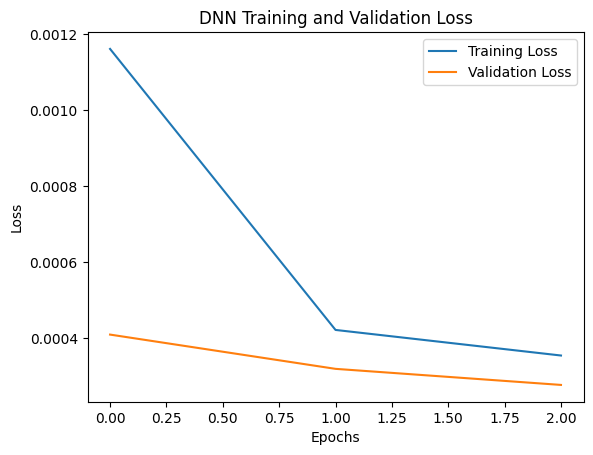

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define a function to create the DNN model
def create_dnn(input_shape, dropout_rate=0.2):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_shape,)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the model
def compile_dnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Define input shape
input_shape = X_train_selected.shape[1]

# Create and compile the model
dnn_model = create_dnn(input_shape)
dnn_model = compile_dnn(dnn_model)

# Train the model
history = dnn_model.fit(
    X_train_selected, y_train,
    validation_data=(X_val_selected, y_val),
    epochs=3,
    batch_size=32,
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_mae = dnn_model.evaluate(X_test_selected, y_test, verbose=0)

# Make predictions on the test set
y_pred = dnn_model.predict(X_test_selected)

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display metrics
print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2 Score:", r2)

# Save the model
dnn_model.save('dnn_regression_model.h5')

# Plot training history
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('DNN Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


## Optimize DNN with Grid Search

Training with parameters: {'batch_size': 32, 'dropout_rate': 0.1, 'epochs': 100, 'learning_rate': 0.001, 'units1': 64, 'units2': 32, 'units3': 16}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training with parameters: {'batch_size': 32, 'dropout_rate': 0.1, 'epochs': 100, 'learning_rate': 0.001, 'units1': 64, 'units2': 32, 'units3': 32}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training with parameters: {'batch_size': 32, 'dropout_rate': 0.1, 'epochs': 100, 'learning_rate': 0.001, 'units1': 64, 'units2': 64, 'units3': 16}


...

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training with parameters: {'batch_size': 32, 'dropout_rate': 0.3, 'epochs': 100, 'learning_rate': 0.001, 'units1': 128, 'units2': 64, 'units3': 32}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Best Hyperparameters:
{'batch_size': 32, 'dropout_rate': 0.1, 'epochs': 100, 'learning_rate': 0.001, 'units1': 128, 'units2': 64, 'units3': 16}
867/867 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step



Test Performance:
Test Loss (MSE): 0.00011120580165879801
Test MAE: 0.006783487740904093
Mean Squared Error: 0.00011120581014928874
Mean Absolute Error: 0.006783484572321392
R^2 Score: 0.8928694061872136


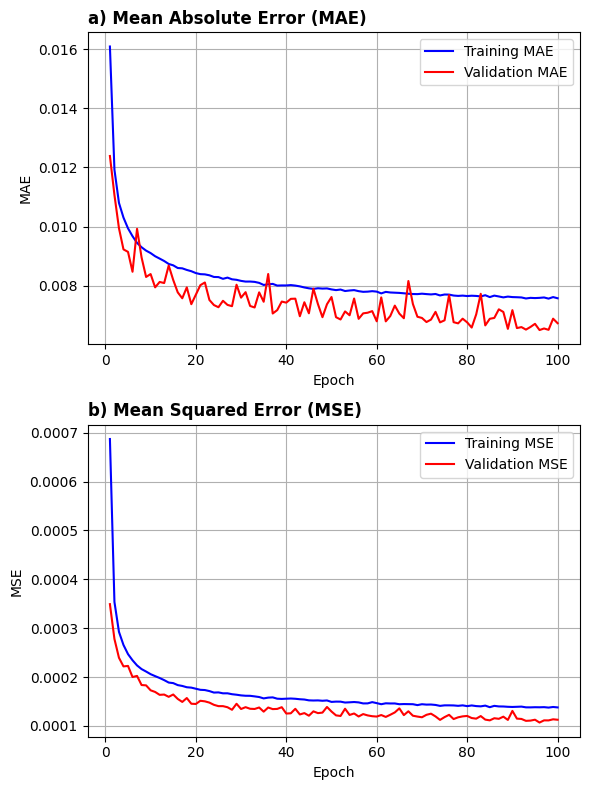

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import ParameterGrid
import numpy as np
import matplotlib.pyplot as plt

# Define the DNN model
def create_dnn(input_shape, units1, units2, units3, dropout_rate):
    model = Sequential([
        Dense(units1, activation='relu', input_shape=(input_shape,)),
        Dropout(dropout_rate),
        Dense(units2, activation='relu'),
        Dropout(dropout_rate),
        Dense(units3, activation='relu'),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the model
def compile_dnn(model, learning_rate):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse', metrics=['mae'])
    return model

# Function to train and evaluate the model
def train_and_evaluate_dnn(params, X_train, y_train, X_val, y_val, input_shape):
    # Create the model with the current hyperparameters
    model = create_dnn(
        input_shape=input_shape,
        units1=params['units1'],
        units2=params['units2'],
        units3=params['units3'],
        dropout_rate=params['dropout_rate']
    )
    model = compile_dnn(model, learning_rate=params['learning_rate'])

    # Train the model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=params['epochs'],
        batch_size=params['batch_size'],
        verbose=0
    )

    # Evaluate the model
    val_loss = history.history['val_loss'][-1]  # Final validation loss
    return model, val_loss, history

# Define the hyperparameter grid
param_grid = {
    'units1': [64, 128],
    'units2': [32, 64],
    'units3': [16, 32],
    'dropout_rate': [0.1, 0.3],
    'learning_rate': [0.001],
    'batch_size': [32],
    'epochs': [100]
}

# Reshape input data if needed
X_train = X_train_selected
X_val = X_val_selected
y_train = y_train
y_val = y_val
input_shape = X_train.shape[1]

# Grid Search implementation
best_model = None
best_params = None
best_val_loss = float('inf')
best_history = None

# Iterate through all parameter combinations
for params in ParameterGrid(param_grid):
    print(f"Training with parameters: {params}")
    model, val_loss, history = train_and_evaluate_dnn(params, X_train, y_train, X_val, y_val, input_shape)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model
        best_params = params
        best_history = history

print("\nBest Hyperparameters:")
print(best_params)

# Evaluate the best model on the test set
test_loss, test_mae = best_model.evaluate(X_test_selected, y_test, verbose=0)
y_pred = best_model.predict(X_test_selected)

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display metrics
print("\nTest Performance:")
print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2 Score:", r2)

# Save the model
best_model.save('dnn_best_model_with_grid_search.h5')

# Save the best hyperparameters to a CSV file
import pandas as pd
pd.DataFrame([best_params]).to_csv('best_hyperparameters_dnn.csv', index=False)

# Plot training and validation metrics
def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)  # Number of epochs

    # Extract metrics from the training history
    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']  # Loss is typically MSE for regression
    val_mse = history.history['val_loss']

    # Create subplots
    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    # Plot MAE
    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=10)
    axes[0].set_ylabel('MAE', fontsize=10)
    axes[0].legend(loc='upper right')
    axes[0].grid()

    # Plot MSE
    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=10)
    axes[1].set_ylabel('MSE', fontsize=10)
    axes[1].legend(loc='upper right')
    axes[1].grid()

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

# Plot metrics for the best model
plot_training_validation_metrics(best_history)


## Optimize RNN with Grid Search

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import ParameterGrid
import numpy as np
import matplotlib.pyplot as plt

# Define the RNN model
def create_rnn(input_shape, units1, units2, units3, dropout_rate):
    model = Sequential([
        SimpleRNN(units1, activation='relu', input_shape=(input_shape, 1), return_sequences=True),
        Dropout(dropout_rate),
        SimpleRNN(units2, activation='relu', return_sequences=True),
        Dropout(dropout_rate),
        SimpleRNN(units3, activation='relu'),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the RNN model
def compile_rnn(model, learning_rate):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse', metrics=['mae'])
    return model

# Function to train and evaluate the RNN model
def train_and_evaluate_rnn(params, X_train, y_train, X_val, y_val, input_shape):
    model = create_rnn(
        input_shape=input_shape,
        units1=params['units1'],
        units2=params['units2'],
        units3=params['units3'],
        dropout_rate=params['dropout_rate']
    )
    model = compile_rnn(model, learning_rate=params['learning_rate'])

    # Train the model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=params['epochs'],
        batch_size=params['batch_size'],
        verbose=0
    )

    # Evaluate the model
    val_loss = history.history['val_loss'][-1]  # Final validation loss
    return model, val_loss, history

# Define the hyperparameter grid
param_grid = {
    'units1': [64, 128],
    'units2': [32, 64],
    'units3': [16, 32],
    'dropout_rate': [0.1],
    'learning_rate': [0.001],
    'batch_size': [32],
    'epochs': [50]
}

# Reshape input data for RNN
X_train_reshaped = np.expand_dims(X_train_selected, axis=-1)
X_val_reshaped = np.expand_dims(X_val_selected, axis=-1)
X_test_reshaped = np.expand_dims(X_test_selected, axis=-1)
y_train = y_train
y_val = y_val
y_test = y_test

# Define input shape
input_shape = X_train_reshaped.shape[1]

# Grid Search implementation
best_model = None
best_params = None
best_val_loss = float('inf')
best_history = None

# Iterate through all parameter combinations
for params in ParameterGrid(param_grid):
    print(f"Training with parameters: {params}")
    model, val_loss, history = train_and_evaluate_rnn(params, X_train_reshaped, y_train, X_val_reshaped, y_val, input_shape)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model
        best_params = params
        best_history = history

print("\nBest Hyperparameters:")
print(best_params)

# Evaluate the best model on the test set
test_loss, test_mae = best_model.evaluate(X_test_reshaped, y_test, verbose=0)
y_pred = best_model.predict(X_test_reshaped)

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display metrics
print("\nTest Performance:")
print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2 Score:", r2)

# Save the best model
best_model.save('rnn_best_model_with_grid_search.h5')

# Save the best hyperparameters to a CSV file
import pandas as pd
pd.DataFrame([best_params]).to_csv('best_hyperparameters_rnn.csv', index=False)

# Plot training and validation metrics
def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)  # Number of epochs

    # Extract metrics from the training history
    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']  # Loss is typically MSE for regression
    val_mse = history.history['val_loss']

    # Create subplots
    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    # Plot MAE
    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=10)
    axes[0].set_ylabel('MAE', fontsize=10)
    axes[0].legend(loc='upper right')
    axes[0].grid()

    # Plot MSE
    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=10)
    axes[1].set_ylabel('MSE', fontsize=10)
    axes[1].legend(loc='upper right')
    axes[1].grid()

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

# Plot metrics for the best model
plot_training_validation_metrics(best_history)


Training with parameters: {'batch_size': 32, 'dropout_rate': 0.1, 'epochs': 50, 'learning_rate': 0.001, 'units1': 64, 'units2': 32, 'units3': 16}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training with parameters: {'batch_size': 32, 'dropout_rate': 0.1, 'epochs': 50, 'learning_rate': 0.001, 'units1': 64, 'units2': 32, 'units3': 32}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training with parameters: {'batch_size': 32, 'dropout_rate': 0.1, 'epochs': 50, 'learning_rate': 0.001, 'units1': 64, 'units2': 64, 'units3': 16}


...

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training with parameters: {'batch_size': 32, 'dropout_rate': 0.1, 'epochs': 50, 'learning_rate': 0.001, 'units1': 128, 'units2': 32, 'units3': 32}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training with parameters: {'batch_size': 32, 'dropout_rate': 0.1, 'epochs': 50, 'learning_rate': 0.001, 'units1': 128, 'units2': 64, 'units3': 16}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Approach 2: Model without using Feature selection

In [ ]:
import pandas as pd
import numpy as np
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import xgboost as xgbimport
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt


# Load the data
df = pd.read_csv(
    'large_fires_data_utf8.csv',
    names= [
        'point_id',
        'lat_dd',
        'long_dd',
        'ndfb_kd_pr',
        'ndfb_kd_co',
        'aspect',
        'def',
        'elevation',
        'lulc',
        'ndvi',
        'pet',
        'ppt',
        'slope',
        'soil',
        'srad',
        'tmax',
        'ws',
        'dist_fores',
        'human_foot',
        'tree_speci',
        'pdsi'
    ],
    header= 0
)

In [ ]:
df.columns

Index(['point_id', 'lat_dd', 'long_dd', 'ndfb_kd_pr', 'ndfb_kd_co', 'aspect',
       'def', 'elevation', 'lulc', 'ndvi', 'pet', 'ppt', 'slope', 'soil',
       'srad', 'tmax', 'ws', 'dist_fores', 'human_foot', 'tree_speci', 'pdsi'],
      dtype='object')

In [ ]:
replace_values_LULC = {
    1: 'Urban_areas',
    2: 'Crop_land',
    3: 'Grass_land',
    4: 'Tree_covered',
    5: 'Shrub_covered',
    6: 'Herbaceous',
    8: 'Sparse_vegetation',
    9: 'Bare_soil',
    10: 'Snow',
    11: 'Water_bodies',
}

df['lulc'] = df['lulc'].replace(replace_values_LULC)
# Convert necessary columns to categorical
df = df.astype(
    {
        'lulc': 'category'
    }
)

In [ ]:
# Drop the 'ndfb_kd_pr' Second Target Feature
df = df.drop(columns=['ndfb_kd_pr'])

In [ ]:
# Replace -9999 with NaN
df.replace(-9999, np.nan, inplace= True)

# Fill NaN values using forward and Backward fill
df.fillna(method='ffill', inplace= True)
df.fillna(method= 'bfill', inplace= True)

<ipython-input-5-4cb6a3cf6494>:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df.replace(-9999, np.nan, inplace= True)
<ipython-input-5-4cb6a3cf6494>:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace= True)
<ipython-input-5-4cb6a3cf6494>:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method= 'bfill', inplace= True)


In [ ]:
# Define features and target, X and y
X = df.drop(columns= ['ndfb_kd_co'])
y = df['ndfb_kd_co']

# Split data into training, validation and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
# Combine features and target back for each dataset
train_data = pd.concat([X_train[['lat_dd', 'long_dd']], y_train], axis=1)
val_data = pd.concat([X_val[['lat_dd', 'long_dd']], y_val], axis=1)
test_data = pd.concat([X_test[['lat_dd', 'long_dd']], y_test], axis=1)

# Save to CSV files
#train_data.to_csv('training_data.csv', index=False)
#val_data.to_csv('validation_data.csv', index=False)
#test_data.to_csv('testing_data.csv', index=False)

In [ ]:
train_data.head()

,lat_dd,long_dd,ndfb_kd_co
46472,54.050550,-129.211333,0.001594
82795,54.550550,-85.878000,0.018068
52778,56.383883,-112.461333,0.021923
159907,61.883883,-94.961333,0.000000
173522,66.133883,-100.461333,0.000000


In [ ]:
# Define the columns to separate out
index_columns = [

                 'point_id',
                 'lat_dd',
                 'long_dd',
                 'dist_fores',
                 'human_foot',
                 'tree_speci',
                 'pdsi'
]

# Separate index columns for train, validation, and test sets
train_indices = X_train[index_columns]
val_indices = X_val[index_columns]
test_indices = X_test[index_columns]

# Drop these columns from the features
X_train = X_train.drop(columns=index_columns)
X_val = X_val.drop(columns=index_columns)
X_test = X_test.drop(columns=index_columns)


In [ ]:
# Define categorical and numerical columns
categorical_columns = ['lulc']
numerical_columns = ['aspect', 'def', 'elevation',
                     'ndvi', 'pet', 'ppt', 'slope', 'soil', 'srad', 'tmax', 'ws']

# Initialize the OneHotEncoder and StandardScaler
encoder = OneHotEncoder(sparse_output=False)
scaler = StandardScaler()

# Fit and transform encoders/scalers on training data
X_train_encoded = pd.DataFrame(encoder.fit_transform(X_train[categorical_columns]),
                               columns=encoder.get_feature_names_out(categorical_columns))
X_val_encoded = pd.DataFrame(encoder.transform(X_val[categorical_columns]),
                             columns=encoder.get_feature_names_out(categorical_columns))
X_test_encoded = pd.DataFrame(encoder.transform(X_test[categorical_columns]),
                              columns=encoder.get_feature_names_out(categorical_columns))

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train[numerical_columns]), columns=numerical_columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val[numerical_columns]), columns=numerical_columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test[numerical_columns]), columns=numerical_columns)

# Concatenate encoded categorical and scaled numerical features
X_train_final = pd.concat([X_train_scaled.reset_index(drop=True), X_train_encoded.reset_index(drop=True)], axis=1)
X_val_final = pd.concat([X_val_scaled.reset_index(drop=True), X_val_encoded.reset_index(drop=True)], axis=1)
X_test_final = pd.concat([X_test_scaled.reset_index(drop=True), X_test_encoded.reset_index(drop=True)], axis=1)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


# Initialize the threshold for VIF
threshold = 5

# Function to calculate VIF and drop features from all datasets if VIF > threshold
def reduce_vif(X_train, X_val, X_test, threshold=5, output_csv_path="vif_values.csv"):
    iteration = 1  # Track iterations for saving intermediate VIF tables
    while True:
        # Calculate VIF for all features in X_train
        vif_data = pd.DataFrame()
        vif_data["Feature"] = X_train.columns
        vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
        vif_data["Status"] = vif_data["VIF"].apply(lambda x: "Rejected" if x > threshold else "Confirmed")

        # Save VIF data to CSV
        vif_data.to_csv(f"{output_csv_path}_iteration_{iteration}.csv", index=False)
        print(f"VIF values saved for iteration {iteration}.")

        # Display the VIF table
        print("\nCurrent VIF table:")
        print(vif_data)

        # Find features with high VIF
        high_vif = vif_data[vif_data["VIF"] > threshold]

        if high_vif.empty:  # Stop when no features exceed the threshold
            break

        # Drop the feature with the highest VIF
        feature_to_drop = high_vif.sort_values(by="VIF", ascending=False).iloc[0]["Feature"]
        print(f"Dropping feature '{feature_to_drop}' with VIF: {high_vif['VIF'].max()}")

        # Drop the feature from all datasets, ensuring consistency
        if feature_to_drop in X_train.columns:
            X_train = X_train.drop(columns=[feature_to_drop])
        if feature_to_drop in X_val.columns:
            X_val = X_val.drop(columns=[feature_to_drop])
        if feature_to_drop in X_test.columns:
            X_test = X_test.drop(columns=[feature_to_drop])

        iteration += 1  # Increment iteration count

    return X_train, X_val, X_test, vif_data

# Apply VIF reduction
X_train_final, X_val_final, X_test_final, final_vif = reduce_vif(
    X_train_final, X_val_final, X_test_final, threshold, output_csv_path="vif_values"
)

# Print final VIF values with status
print("\nFinal VIF values with Status:\n", final_vif)


VIF values saved for iteration 1.

Current VIF table:
                   Feature       VIF     Status
0                   aspect  1.032227  Confirmed
1                      def  2.590087  Confirmed
2                elevation  2.576588  Confirmed
3                     ndvi  4.288005  Confirmed
4                      pet  3.703133  Confirmed
5                      ppt  3.706548  Confirmed
6                    slope  2.083030  Confirmed
7                     soil  1.570999  Confirmed
8                     srad  3.884206  Confirmed
9                     tmax  8.741467   Rejected
10                      ws  2.903292  Confirmed
11          lulc_Bare_soil  1.023286  Confirmed
12          lulc_Crop_land  1.744841  Confirmed
13         lulc_Grass_land  1.378523  Confirmed
14         lulc_Herbaceous  1.053855  Confirmed
15      lulc_Shrub_covered  1.052452  Confirmed
16               lulc_Snow  1.222933  Confirmed
17  lulc_Sparse_vegetation  1.748304  Confirmed
18       lulc_Tree_covered  1.5484

In [ ]:
X_train_final.head()

,aspect,def,elevation,ndvi,pet,ppt,slope,soil,srad,ws,lulc_Bare_soil,lulc_Crop_land,lulc_Grass_land,lulc_Herbaceous,lulc_Shrub_covered,lulc_Snow,lulc_Sparse_vegetation,lulc_Tree_covered,lulc_Urban_areas,lulc_Water_bodies
0,-0.880506,-0.704264,0.177860,-0.769984,-2.199583,5.320789,2.632245,0.272813,-0.838675,-0.239602,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-1.077541,-0.124674,-0.903719,-0.235979,-0.209776,0.062233,-0.399456,-0.268398,0.530055,-0.632310,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2.187609,0.169114,0.070092,1.253667,0.952401,-0.355707,-0.399456,0.481500,0.804700,-0.631441,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,-0.974332,0.017565,-1.011903,-0.857128,-0.805826,-0.713692,-0.399456,0.405090,-0.083802,1.652305,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-1.086924,1.389197,-0.786760,-1.684554,0.065727,-1.147466,-0.399456,-0.536192,-0.748925,2.141360,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
X_test_final.head()

,aspect,def,elevation,ndvi,pet,ppt,slope,soil,srad,ws,lulc_Bare_soil,lulc_Crop_land,lulc_Grass_land,lulc_Herbaceous,lulc_Shrub_covered,lulc_Snow,lulc_Sparse_vegetation,lulc_Tree_covered,lulc_Urban_areas,lulc_Water_bodies
0,-1.077541,-1.154610,-0.414305,-0.091794,-0.991515,1.264557,-0.062600,-0.702778,-0.291376,2.491581,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.802922,0.564642,-0.773259,-1.369335,-0.253330,-1.003427,-0.399456,-0.206092,-0.570775,2.176351,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.007923,-1.032563,-0.744457,-1.081819,-1.313116,0.141617,0.274255,-0.798495,-0.754643,2.029889,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,-0.336315,0.164282,-0.487969,-1.363305,-1.322750,-0.465984,-0.399456,-0.831133,-0.299535,1.046269,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-0.852358,-1.058763,-0.246072,1.924929,0.221659,1.376314,-0.062600,0.320884,1.317307,-1.164408,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
X_val_final.head()

,aspect,def,elevation,ndvi,pet,ppt,slope,soil,srad,ws,lulc_Bare_soil,lulc_Crop_land,lulc_Grass_land,lulc_Herbaceous,lulc_Shrub_covered,lulc_Snow,lulc_Sparse_vegetation,lulc_Tree_covered,lulc_Urban_areas,lulc_Water_bodies
0,2.084400,-0.210587,2.555931,-0.122069,0.211152,-0.530908,0.611111,-1.105951,-1.387902,-1.499884,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.512061,0.197900,0.228481,0.065096,0.431028,-0.827113,0.611111,-1.121336,-1.814376,-1.681336,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.789599,4.507635,0.623607,-0.218822,3.386288,-0.800667,-0.399456,-1.383485,2.227845,0.645287,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.967869,2.009186,0.390410,-0.062008,2.348771,-0.439480,-0.062600,-0.248336,1.824775,0.868006,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.233106,-0.633612,-1.079936,-0.557307,-0.848964,-0.473496,-0.399456,0.061774,0.374325,0.922161,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


# Train Deep Learning Models without Feature Selection and Feature Importance

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8091/8091 ━━━━━━━━━━━━━━━━━━━━ 46s 5ms/step - loss: 0.0039 - mae: 0.0344 - val_loss: 4.7802e-04 - val_mae: 0.0134
Epoch 2/50
8091/8091 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - loss: 5.1286e-04 - mae: 0.0147 - val_loss: 3.7363e-04 - val_mae: 0.0111
Epoch 3/50
8091/8091 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - loss: 4.2369e-04 - mae: 0.0130 - val_loss: 3.5054e-04 - val_mae: 0.0128
Epoch 4/50
8091/8091 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: 3.8480e-04 - mae: 0.0124 - val_loss: 3.0408e-04 - val_mae: 0.0106
Epoch 5/50
8091/8091 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 3.7130e-04 - mae: 0.0122 - val_loss: 3.0506e-04 - val_mae: 0.0107
Epoch 6/50
8091/8091 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - loss: 3.6788e-04 - mae: 0.0122 - val_loss: 2.8973e-04 - val_mae: 0.0106
Epoch 7/50
8091/8091 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 3.5518e-04 - mae: 0.0120 - val_loss: 3.0508e-04 - val_mae: 0.0104
Epoch 8/50
8091/8091 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 3.4972e-04 - mae: 0.0119 - val_loss: 2.9718e-04 -

Test Loss (MSE): 0.00026431860169395804
Test MAE: 0.010225724428892136
Mean Squared Error: 0.00026431846718620523
Mean Absolute Error: 0.010225735290004536
R^2 Score: 0.745367671821014


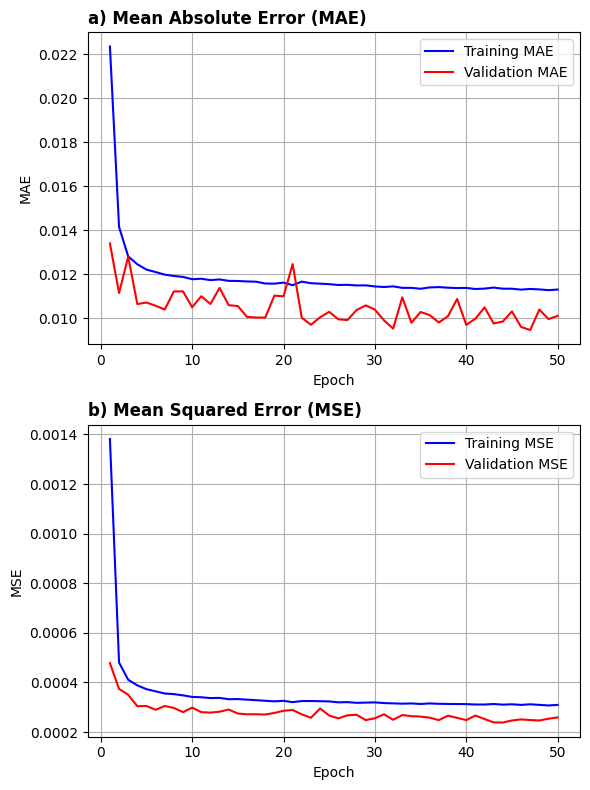

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define a function to create the DNN model
def create_dnn(input_shape, dropout_rate=0.5):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_shape,)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the model
def compile_dnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Define input shape
input_shape = X_train_final.shape[1]

# Create and compile the model
dnn_model = create_dnn(input_shape)
dnn_model = compile_dnn(dnn_model)

# Train the model
history = dnn_model.fit(
    X_train_final, y_train,
    validation_data=(X_val_final, y_val),
    epochs=50,
    batch_size=16,
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_mae = dnn_model.evaluate(X_test_final, y_test, verbose=0)

# Make predictions on the test set
y_pred = dnn_model.predict(X_test_final)

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display metrics
print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2 Score:", r2)

# Save the model
dnn_model.save('dnn_regression_model.h5')

import matplotlib.pyplot as plt

# Function to plot training and validation metrics
def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)  # Number of epochs

    # Extract metrics from the training history
    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']  # Loss is typically MSE for regression
    val_mse = history.history['val_loss']

    # Create subplots
    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    # Plot MAE
    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=10)
    axes[0].set_ylabel('MAE', fontsize=10)
    axes[0].legend(loc='upper right')
    axes[0].grid()

    # Plot MSE
    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=10)
    axes[1].set_ylabel('MSE', fontsize=10)
    axes[1].legend(loc='upper right')
    axes[1].grid()

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

# Assuming you have the training history from model.fit
# Example for DNN:
# history = dnn_model.fit(X_train_selected, y_train, validation_data=(X_val_selected, y_val), epochs=100, batch_size=32, verbose=1)

# Call the function with your model's training history
plot_training_validation_metrics(history)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.0023 - mae: 0.0289 - val_loss: 4.2419e-04 - val_mae: 0.0132
Epoch 2/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 4.6960e-04 - mae: 0.0137 - val_loss: 3.4206e-04 - val_mae: 0.0109
Epoch 3/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 3.7333e-04 - mae: 0.0121 - val_loss: 2.8657e-04 - val_mae: 0.0114
Epoch 4/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 3.3673e-04 - mae: 0.0115 - val_loss: 2.7886e-04 - val_mae: 0.0100
Epoch 5/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 3.1618e-04 - mae: 0.0111 - val_loss: 2.5002e-04 - val_mae: 0.0100
Epoch 6/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 3.0110e-04 - mae: 0.0108 - val_loss: 2.4149e-04 - val_mae: 0.0096
Epoch 7/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 2.9468e-04 - mae: 0.0107 - val_loss: 2.5426e-04 - val_mae: 0.0098
Epoch 8/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 2.8658e-04 - mae: 0.0105 - val_los

Test Loss (MSE): 0.00019145531405229121
Test MAE: 0.008182413876056671
Mean Squared Error: 0.0001914553047688999
Mean Absolute Error: 0.00818241409472575
R^2 Score: 0.8155607116124098


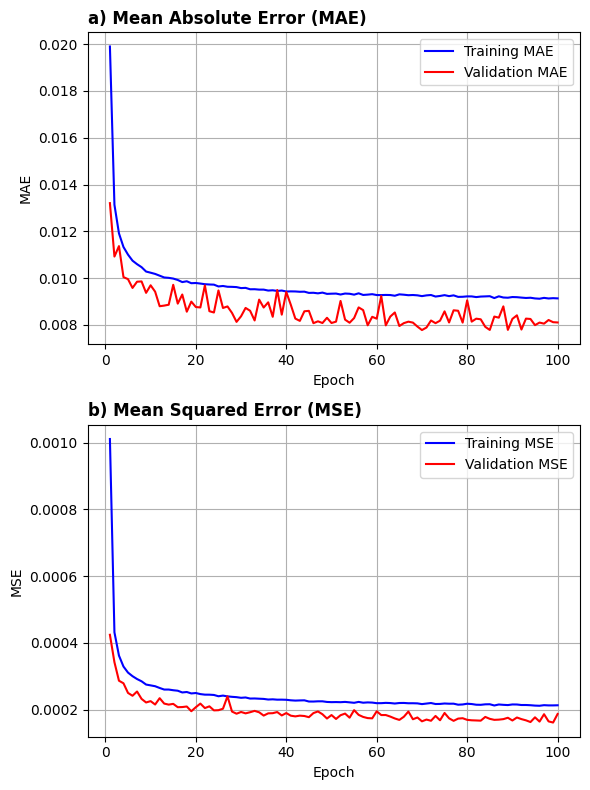

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define a function to create the DNN model
def create_dnn(input_shape, dropout_rate=0.3):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_shape,)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the model
def compile_dnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Define input shape
input_shape = X_train_final.shape[1]

# Create and compile the model
dnn_model = create_dnn(input_shape)
dnn_model = compile_dnn(dnn_model)

# Train the model
history = dnn_model.fit(
    X_train_final, y_train,
    validation_data=(X_val_final, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_mae = dnn_model.evaluate(X_test_final, y_test, verbose=0)

# Make predictions on the test set
y_pred = dnn_model.predict(X_test_final)

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display metrics
print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2 Score:", r2)

# Save the model
dnn_model.save('dnn_regression_model.h5')

import matplotlib.pyplot as plt

# Function to plot training and validation metrics
def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)  # Number of epochs

    # Extract metrics from the training history
    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']  # Loss is typically MSE for regression
    val_mse = history.history['val_loss']

    # Create subplots
    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    # Plot MAE
    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=10)
    axes[0].set_ylabel('MAE', fontsize=10)
    axes[0].legend(loc='upper right')
    axes[0].grid()

    # Plot MSE
    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=10)
    axes[1].set_ylabel('MSE', fontsize=10)
    axes[1].legend(loc='upper right')
    axes[1].grid()

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

# Assuming you have the training history from model.fit
# Example for DNN:
# history = dnn_model.fit(X_train_selected, y_train, validation_data=(X_val_selected, y_val), epochs=100, batch_size=32, verbose=1)

# Call the function with your model's training history
plot_training_validation_metrics(history)


## RNN

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4046/4046 ━━━━━━━━━━━━━━━━━━━━ 96s 23ms/step - loss: 9.4390e-04 - mae: 0.0198 - val_loss: 3.6005e-04 - val_mae: 0.0118
Epoch 2/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 92s 23ms/step - loss: 3.4612e-04 - mae: 0.0118 - val_loss: 2.4986e-04 - val_mae: 0.0096
Epoch 3/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 142s 23ms/step - loss: 2.9082e-04 - mae: 0.0107 - val_loss: 2.5096e-04 - val_mae: 0.0097
Epoch 4/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 96s 24ms/step - loss: 2.6191e-04 - mae: 0.0102 - val_loss: 2.2084e-04 - val_mae: 0.0098
Epoch 5/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 142s 24ms/step - loss: 2.5106e-04 - mae: 0.0099 - val_loss: 2.4515e-04 - val_mae: 0.0098
Epoch 6/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 137s 23ms/step - loss: 2.3005e-04 - mae: 0.0095 - val_loss: 2.3719e-04 - val_mae: 0.0099
Epoch 7/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 88s 22ms/step - loss: 2.1875e-04 - mae: 0.0093 - val_loss: 2.0371e-04 - val_mae: 0.0092
Epoch 8/100
4046/4046 ━━━━━━━━━━━━━━━━━━━━ 147s 23ms/step - loss: 2.1210e-04 - mae: 0.0092 -

Test Loss (MSE): 0.00017789730918593705
Test MAE: 0.00893000140786171
Mean Squared Error: 0.00017789721903726055
Mean Absolute Error: 0.008929999152993792
R^2 Score: 0.8286219516091807


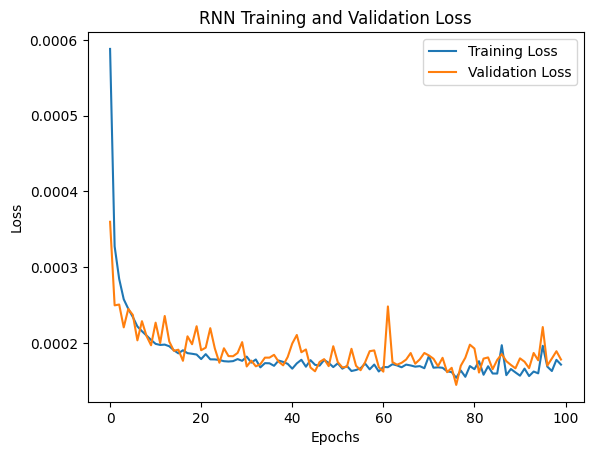

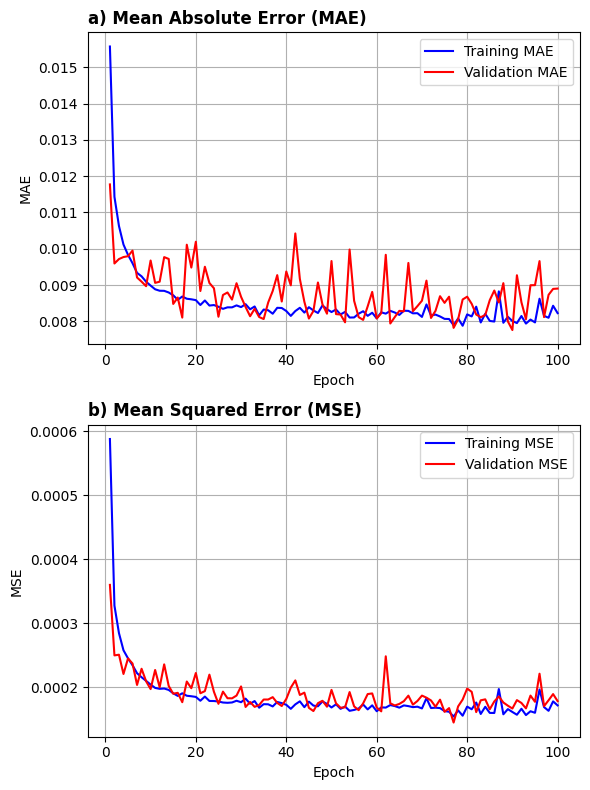

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Define a function to create the RNN model
def create_rnn(input_shape, dropout_rate=0.4):
    model = Sequential([
        SimpleRNN(128, activation='relu', input_shape=(input_shape, 1), return_sequences=True),
        Dropout(dropout_rate),
        SimpleRNN(64, activation='relu', return_sequences=True),
        Dropout(dropout_rate),
        SimpleRNN(32, activation='relu'),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the model
def compile_rnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Reshape input data for RNN
X_train_reshaped = np.expand_dims(X_train_final, axis=-1)
X_val_reshaped = np.expand_dims(X_val_final, axis=-1)
X_test_reshaped = np.expand_dims(X_test_final, axis=-1)

# Define input shape
input_shape = X_train_reshaped.shape[1]

# Create and compile the model
rnn_model = create_rnn(input_shape)
rnn_model = compile_rnn(rnn_model)

# Train the model
history = rnn_model.fit(
    X_train_reshaped, y_train,
    validation_data=(X_val_reshaped, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_mae = rnn_model.evaluate(X_test_reshaped, y_test, verbose=0)

# Make predictions on the test set
y_pred = rnn_model.predict(X_test_reshaped)

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display metrics
print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2 Score:", r2)

# Save the model
rnn_model.save('rnn_regression_model.h5')

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('RNN Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Function to plot training and validation metrics
def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)  # Number of epochs

    # Extract metrics from the training history
    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']  # Loss is typically MSE for regression
    val_mse = history.history['val_loss']

    # Create subplots
    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    # Plot MAE
    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=10)
    axes[0].set_ylabel('MAE', fontsize=10)
    axes[0].legend(loc='upper right')
    axes[0].grid()

    # Plot MSE
    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=10)
    axes[1].set_ylabel('MSE', fontsize=10)
    axes[1].legend(loc='upper right')
    axes[1].grid()

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

# Call the function with your model's training history
plot_training_validation_metrics(history)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
8091/8091 ━━━━━━━━━━━━━━━━━━━━ 150s 18ms/step - loss: 0.0012 - mae: 0.0213 - val_loss: 3.5300e-04 - val_mae: 0.0112
Epoch 2/50
8091/8091 ━━━━━━━━━━━━━━━━━━━━ 208s 19ms/step - loss: 3.8419e-04 - mae: 0.0125 - val_loss: 3.3462e-04 - val_mae: 0.0114
Epoch 3/50
8091/8091 ━━━━━━━━━━━━━━━━━━━━ 195s 18ms/step - loss: 3.4388e-04 - mae: 0.0118 - val_loss: 3.1853e-04 - val_mae: 0.0107
Epoch 4/50
8091/8091 ━━━━━━━━━━━━━━━━━━━━ 203s 18ms/step - loss: 3.2454e-04 - mae: 0.0114 - val_loss: 3.0582e-04 - val_mae: 0.0112
Epoch 5/50
8091/8091 ━━━━━━━━━━━━━━━━━━━━ 197s 17ms/step - loss: 3.1044e-04 - mae: 0.0112 - val_loss: 2.9168e-04 - val_mae: 0.0111
Epoch 6/50
8091/8091 ━━━━━━━━━━━━━━━━━━━━ 144s 18ms/step - loss: 2.9865e-04 - mae: 0.0110 - val_loss: 2.7609e-04 - val_mae: 0.0102
Epoch 7/50
8091/8091 ━━━━━━━━━━━━━━━━━━━━ 203s 18ms/step - loss: 2.9614e-04 - mae: 0.0109 - val_loss: 2.8499e-04 - val_mae: 0.0102
Epoch 8/50
8091/8091 ━━━━━━━━━━━━━━━━━━━━ 201s 18ms/step - loss: 2.9192e-04 - mae: 0.01

Test Loss (MSE): 0.00025354610988870263
Test MAE: 0.010702423751354218
Mean Squared Error: 0.00025354603843107153
Mean Absolute Error: 0.010702422230207148
R^2 Score: 0.7557453372307094


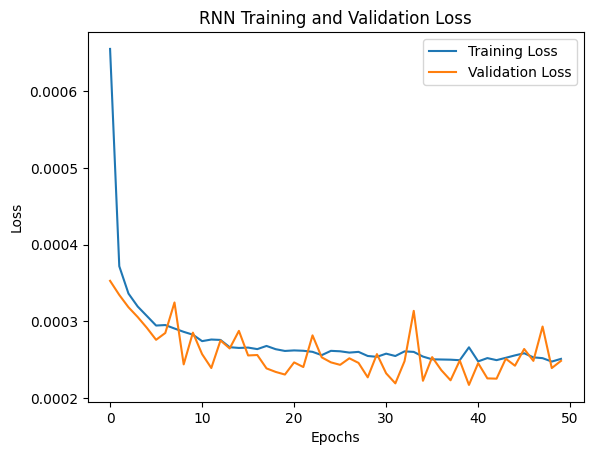

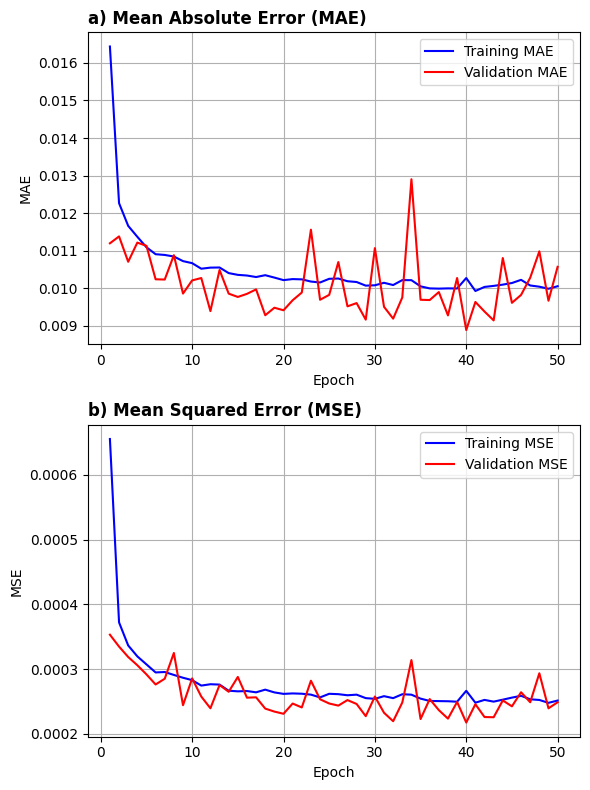

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Define a function to create the RNN model
def create_rnn(input_shape, dropout_rate=0.5):
    model = Sequential([
        SimpleRNN(64, activation='relu', input_shape=(input_shape, 1), return_sequences=True),
        Dropout(dropout_rate),
        SimpleRNN(64, activation='relu', return_sequences=True),
        Dropout(dropout_rate),
        SimpleRNN(32, activation='relu'),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the model
def compile_rnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Reshape input data for RNN
X_train_reshaped = np.expand_dims(X_train_final, axis=-1)
X_val_reshaped = np.expand_dims(X_val_final, axis=-1)
X_test_reshaped = np.expand_dims(X_test_final, axis=-1)

# Define input shape
input_shape = X_train_reshaped.shape[1]

# Create and compile the model
rnn_model = create_rnn(input_shape)
rnn_model = compile_rnn(rnn_model)

# Train the model
history = rnn_model.fit(
    X_train_reshaped, y_train,
    validation_data=(X_val_reshaped, y_val),
    epochs=50,
    batch_size=16,
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_mae = rnn_model.evaluate(X_test_reshaped, y_test, verbose=0)

# Make predictions on the test set
y_pred = rnn_model.predict(X_test_reshaped)

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display metrics
print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2 Score:", r2)

# Save the model
rnn_model.save('rnn_regression_model.h5')

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('RNN Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Function to plot training and validation metrics
def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)  # Number of epochs

    # Extract metrics from the training history
    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']  # Loss is typically MSE for regression
    val_mse = history.history['val_loss']

    # Create subplots
    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    # Plot MAE
    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=10)
    axes[0].set_ylabel('MAE', fontsize=10)
    axes[0].legend(loc='upper right')
    axes[0].grid()

    # Plot MSE
    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=10)
    axes[1].set_ylabel('MSE', fontsize=10)
    axes[1].legend(loc='upper right')
    axes[1].grid()

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

# Call the function with your model's training history
plot_training_validation_metrics(history)


## BiRNN

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Define a function to create the BiRNN model
def create_birnn(input_shape, dropout_rate=0.3):
    model = Sequential([
        Bidirectional(SimpleRNN(128, activation='relu', return_sequences=True), input_shape=(input_shape, 1)),
        Dropout(dropout_rate),
        Bidirectional(SimpleRNN(64, activation='relu', return_sequences=True)),
        Dropout(dropout_rate),
        Bidirectional(SimpleRNN(32, activation='relu')),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the model
def compile_birnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Reshape input data for BiRNN
X_train_reshaped = np.expand_dims(X_train_final, axis=-1)
X_val_reshaped = np.expand_dims(X_val_final, axis=-1)
X_test_reshaped = np.expand_dims(X_test_final, axis=-1)

# Define input shape
input_shape = X_train_reshaped.shape[1]

# Create and compile the model
birnn_model = create_birnn(input_shape)
birnn_model = compile_birnn(birnn_model)

# Train the model
history = birnn_model.fit(
    X_train_reshaped, y_train,
    validation_data=(X_val_reshaped, y_val),
    epochs=100,
    batch_size=16,
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_mae = birnn_model.evaluate(X_test_reshaped, y_test, verbose=0)

# Make predictions on the test set
y_pred = birnn_model.predict(X_test_reshaped)

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display metrics
print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2 Score:", r2)

# Save the model
birnn_model.save('birnn_regression_model.h5')

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('BiRNN Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Function to plot training and validation metrics
def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)  # Number of epochs

    # Extract metrics from the training history
    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']  # Loss is typically MSE for regression
    val_mse = history.history['val_loss']

    # Create subplots
    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    # Plot MAE
    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=10)
    axes[0].set_ylabel('MAE', fontsize=10)
    axes[0].legend(loc='upper right')
    axes[0].grid()

    # Plot MSE
    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=10)
    axes[1].set_ylabel('MSE', fontsize=10)
    axes[1].legend(loc='upper right')
    axes[1].grid()

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

# Call the function with your model's training history
plot_training_validation_metrics(history)


NameError: name 'X_train_final' is not defined

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1367/1367 ━━━━━━━━━━━━━━━━━━━━ 76s 48ms/step - loss: 0.0017 - mae: 0.0253 - val_loss: 4.5917e-04 - val_mae: 0.0127
Epoch 2/100
1367/1367 ━━━━━━━━━━━━━━━━━━━━ 66s 48ms/step - loss: 4.5310e-04 - mae: 0.0136 - val_loss: 3.6395e-04 - val_mae: 0.0133
Epoch 3/100
1367/1367 ━━━━━━━━━━━━━━━━━━━━ 80s 47ms/step - loss: 3.6554e-04 - mae: 0.0124 - val_loss: 2.8131e-04 - val_mae: 0.0108
Epoch 4/100
1367/1367 ━━━━━━━━━━━━━━━━━━━━ 83s 48ms/step - loss: 2.9167e-04 - mae: 0.0111 - val_loss: 2.4032e-04 - val_mae: 0.0099
Epoch 5/100
1367/1367 ━━━━━━━━━━━━━━━━━━━━ 80s 47ms/step - loss: 2.5280e-04 - mae: 0.0104 - val_loss: 2.6888e-04 - val_mae: 0.0116
Epoch 6/100
1367/1367 ━━━━━━━━━━━━━━━━━━━━ 66s 48ms/step - loss: 2.3948e-04 - mae: 0.0100 - val_loss: 2.1701e-04 - val_mae: 0.0093
Epoch 7/100
1367/1367 ━━━━━━━━━━━━━━━━━━━━ 81s 48ms/step - loss: 2.0908e-04 - mae: 0.0093 - val_loss: 1.9583e-04 - val_mae: 0.0093
Epoch 8/100
1367/1367 ━━━━━━━━━━━━━━━━━━━━ 81s 47ms/step - loss: 1.9670e-04 - mae: 0.0091 - val_los

Test Loss (MSE): 8.512731437804177e-05
Test MAE: 0.005633719731122255
Mean Squared Error: 8.5127284456416e-05
Mean Absolute Error: 0.005633720194290185
R^2 Score: 0.9129824208956517


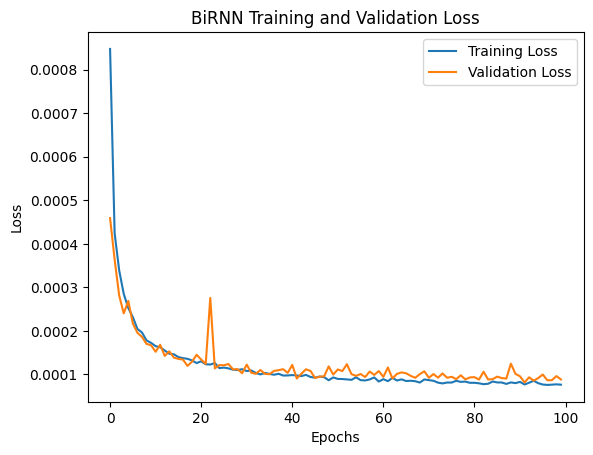

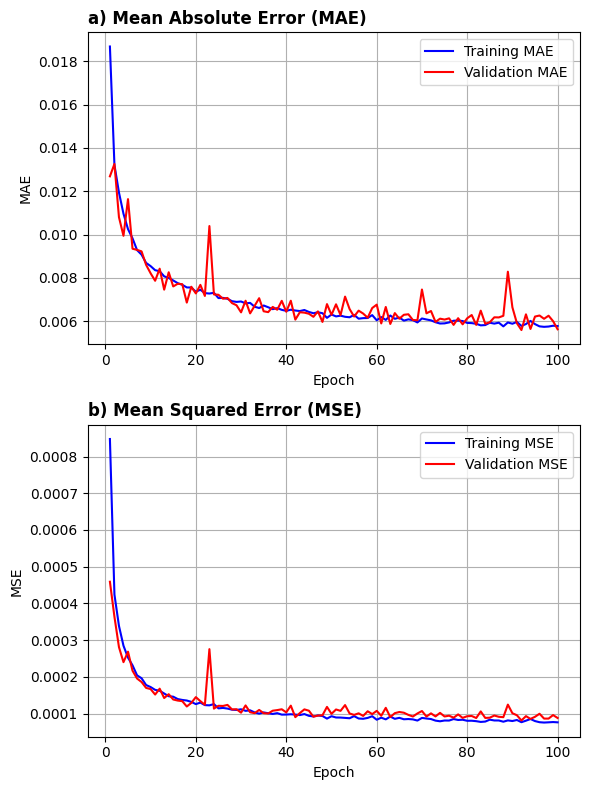

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Define a function to create the BiRNN model
def create_birnn(input_shape, dropout_rate=0.3):
    model = Sequential([
        Bidirectional(SimpleRNN(128, activation='relu', return_sequences=True), input_shape=(input_shape, 1)),
        Dropout(dropout_rate),
        Bidirectional(SimpleRNN(64, activation='relu', return_sequences=True)),
        Dropout(dropout_rate),
        Bidirectional(SimpleRNN(32, activation='relu')),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the model
def compile_birnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Reshape input data for BiRNN
X_train_reshaped = np.expand_dims(X_train_final, axis=-1)
X_val_reshaped = np.expand_dims(X_val_final, axis=-1)
X_test_reshaped = np.expand_dims(X_test_final, axis=-1)

# Define input shape
input_shape = X_train_reshaped.shape[1]

# Create and compile the model
birnn_model = create_birnn(input_shape)
birnn_model = compile_birnn(birnn_model)

# Train the model
history = birnn_model.fit(
    X_train_reshaped, y_train,
    validation_data=(X_val_reshaped, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_mae = birnn_model.evaluate(X_test_reshaped, y_test, verbose=0)

# Make predictions on the test set
y_pred = birnn_model.predict(X_test_reshaped)

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display metrics
print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2 Score:", r2)

# Save the model
birnn_model.save('birnn_regression_model.h5')

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('BiRNN Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Function to plot training and validation metrics
def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)  # Number of epochs

    # Extract metrics from the training history
    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']  # Loss is typically MSE for regression
    val_mse = history.history['val_loss']

    # Create subplots
    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    # Plot MAE
    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=10)
    axes[0].set_ylabel('MAE', fontsize=10)
    axes[0].legend(loc='upper right')
    axes[0].grid()

    # Plot MSE
    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=10)
    axes[1].set_ylabel('MSE', fontsize=10)
    axes[1].legend(loc='upper right')
    axes[1].grid()

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

# Call the function with your model's training history
plot_training_validation_metrics(history)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
2733/2733 ━━━━━━━━━━━━━━━━━━━━ 114s 38ms/step - loss: 0.0059 - mae: 0.0404 - val_loss: 6.3093e-04 - val_mae: 0.0155
Epoch 2/50
2733/2733 ━━━━━━━━━━━━━━━━━━━━ 138s 37ms/step - loss: 6.1892e-04 - mae: 0.0165 - val_loss: 4.7336e-04 - val_mae: 0.0136
Epoch 3/50
2733/2733 ━━━━━━━━━━━━━━━━━━━━ 138s 36ms/step - loss: 4.8984e-04 - mae: 0.0142 - val_loss: 3.6848e-04 - val_mae: 0.0121
Epoch 4/50
2733/2733 ━━━━━━━━━━━━━━━━━━━━ 142s 36ms/step - loss: 4.0090e-04 - mae: 0.0129 - val_loss: 3.2812e-04 - val_mae: 0.0121
Epoch 5/50
2733/2733 ━━━━━━━━━━━━━━━━━━━━ 145s 37ms/step - loss: 3.4017e-04 - mae: 0.0118 - val_loss: 2.9053e-04 - val_mae: 0.0106
Epoch 6/50
2733/2733 ━━━━━━━━━━━━━━━━━━━━ 138s 36ms/step - loss: 3.0180e-04 - mae: 0.0111 - val_loss: 2.4938e-04 - val_mae: 0.0101
Epoch 7/50
2733/2733 ━━━━━━━━━━━━━━━━━━━━ 146s 37ms/step - loss: 2.7967e-04 - mae: 0.0108 - val_loss: 2.4504e-04 - val_mae: 0.0108
Epoch 8/50
2733/2733 ━━━━━━━━━━━━━━━━━━━━ 138s 36ms/step - loss: 2.6032e-04 - mae: 0.01

Test Loss (MSE): 0.00023277959553524852
Test MAE: 0.010128367692232132
Mean Squared Error: 0.0002327795576829606
Mean Absolute Error: 0.01012836894895615
R^2 Score: 0.7620514538447075


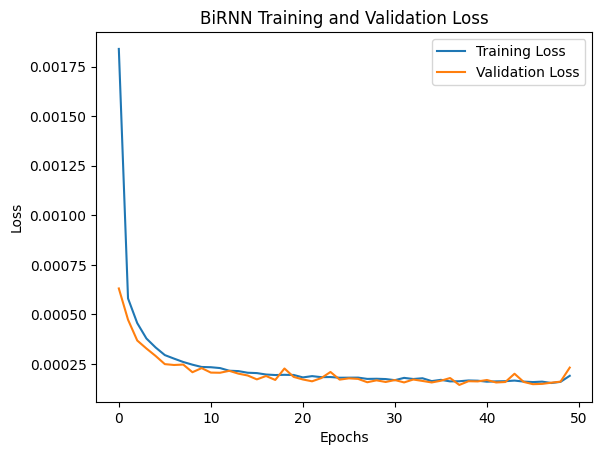

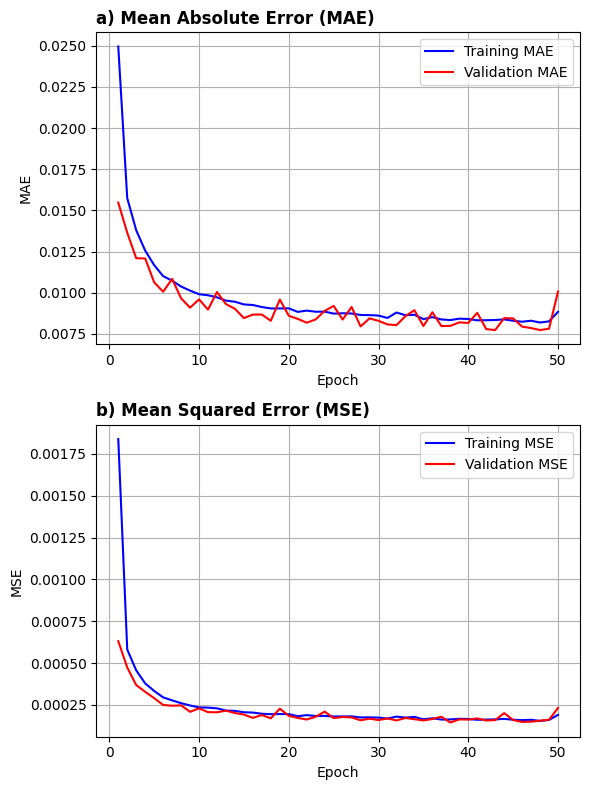

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Define a function to create the BiRNN model
def create_birnn(input_shape, dropout_rate=0.4):
    model = Sequential([
        Bidirectional(SimpleRNN(64, activation='relu', return_sequences=True), input_shape=(input_shape, 1)),
        Dropout(dropout_rate),
        Bidirectional(SimpleRNN(64, activation='relu', return_sequences=True)),
        Dropout(dropout_rate),
        Bidirectional(SimpleRNN(32, activation='relu')),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the model
def compile_birnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Reshape input data for BiRNN
X_train_reshaped = np.expand_dims(X_train_final, axis=-1)
X_val_reshaped = np.expand_dims(X_val_final, axis=-1)
X_test_reshaped = np.expand_dims(X_test_final, axis=-1)

# Define input shape
input_shape = X_train_reshaped.shape[1]

# Create and compile the model
birnn_model = create_birnn(input_shape)
birnn_model = compile_birnn(birnn_model)

# Train the model
history = birnn_model.fit(
    X_train_reshaped, y_train,
    validation_data=(X_val_reshaped, y_val),
    epochs=50,
    batch_size=16,
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_mae = birnn_model.evaluate(X_test_reshaped, y_test, verbose=0)

# Make predictions on the test set
y_pred = birnn_model.predict(X_test_reshaped)

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display metrics
print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2 Score:", r2)

# Save the model
birnn_model.save('birnn_regression_model.h5')

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('BiRNN Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Function to plot training and validation metrics
def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)  # Number of epochs

    # Extract metrics from the training history
    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']  # Loss is typically MSE for regression
    val_mse = history.history['val_loss']

    # Create subplots
    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    # Plot MAE
    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=10)
    axes[0].set_ylabel('MAE', fontsize=10)
    axes[0].legend(loc='upper right')
    axes[0].grid()

    # Plot MSE
    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=10)
    axes[1].set_ylabel('MSE', fontsize=10)
    axes[1].legend(loc='upper right')
    axes[1].grid()

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

# Call the function with your model's training history
plot_training_validation_metrics(history)
